**Description of the Modules**

1. Imports: Import needed libraries
2. Final files:
*   Get gdf file from Google drive. To change the input file or folder change the names in the first cell
*   Create a dataset with the training data and reduce columns to include only columns *PREDICTION_FEATURES*. To add/delete columns, modify the set *PREDICTION_FEATURES*
3. Map categories: Maps categories in fynctype, computes correlations and creates enhanced features 1. To add/delete/change categories, modify *functype_to_english*
4. Prediction Models:

*   The first cell creates the features in three separate functions for each model *create_baseline_features, create_enhanced_features, create_enhanced_2_features* and runs the training. To add another feature in the any of the functions add the following code with the changed column name:
> if 'columns_name' in df.columns:
    features['columns_name'] = df['columns_name'].fillna('Unknown')
else:
    features['columns_name'] = 'Unknown'

*   Inference: Generation of the data. The final predictions are saved in **gdf_data['predicted_energy_demand']**

Note: Run all hidden cells in a together by collapsing the cells under each module and pressing run.



## Imports

In [ ]:
!pip install contextily geopandas matplotlib rasterio
!pip install tensorflow
# Run this in a notebook cell if XGBoost is missing:
!pip install xgboost

# Run this if TensorFlow is missing:
!pip install tensorflow

!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 14.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import xgboost as xgb
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
from shapely.geometry import box
import io
from PIL import Image
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, QuantileTransformer, MinMaxScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler

## Final files


In [ ]:
drive.mount('/content/drive')
folder_path_shared_final =  "/content/drive/MyDrive/GATE/Energy Consumption/Final_datasets/"
gdf_data = gpd.read_file(folder_path_shared_final + "buildings_SO_2025_enriched_shape_neighbour_energy_panels_nsiyear_18092025.geojson")
merged_data = gpd.read_file(folder_path_shared_final + "merged_energy_data_points_fixed_matching_kk_16092025.gpkg")

Mounted at /content/drive


Get training dataset with 2100 buildings and essential columns for the prediction

In [ ]:
def create_overlapping_gdf_dataset(gdf_data, merged_data):
    # Define essential columns for prediction model
    PREDICTION_FEATURES = [
        # Energy demand columns (likely your target variables)
        'en2025_enegy_demand_present_m2', 'en2025_enegy_demand_after_m2',
        'en2025_enegy_demand_present_y', 'en2025_enegy_demand_after_y',
        'en2023_enegy_demand_present_m2', 'en2023_enegy_demand_after_m2',
        'en2023_enegy_demand_present_y', 'en2023_enegy_demand_after_y',

        # Building characteristics
        'en2025_area_heated_m2', 'en2025_vol_heated_m3', 'en2025_vol_cooled_m3',
        'en2025_gfa_m2', 'en2025_fp_area_m2', 'en2025_yearbuilt', 'en2025_type',
        'en2023_area_heated_m2', 'en2023_vol_heated_m3', 'en2023_vol_cooled_m3',
        'en2023_gfa_m2', 'en2023_fp_area_m2', 'en2023_yearbuilt', 'en2023_type',

        # Building classification and function
        'd_Category', 'c2025_funccode', 'c2025_functype', 'c2025_proptype',

        # Energy performance classes
        'en2025_class_present', 'en2025_class_after', 'en2025_epc_type',
        'en2023_class_present', 'en2023_class_after', 'en2023_epc_type',

        # Location information
        'en2025_mun', 'en2025_city', 'en2025_oblast',
        'en2023_mun', 'en2023_city', 'en2023_oblast',

        # Building structure
        'c2025_flrcount', 'en2023_floorcount', 'c2025_appcount',

        # Identification columns
        'en2025_cadnum', 'en2023_cadnum', 'c2025_cadnum',
        'en2025_name', 'en2023_name',

        # Address and location
        'en2025_addr', 'en2023_addr', 'c2025_immaddr',

        # Correlation columns (if they're calculated features)
        'd_Correlation_Energy_Demand', 'd_Correlation_Energy_Demand_ECM',
        'd_Correlation_Primary_Energy', 'd_Correlation_Primary_Energy_ECM',

        # Data quality indicator
        'd_Energy_Completeness_Pct',
        'geolocated'
    ]

    ADDITIONAL_GDF_COLUMNS = [
        '_address', 'col0', '_latitude', '_longitude', '_arcgis_longlabel',
        '_arcgis_exinfo', '_arcgis_wkid', 'fme_rejection_code', 'layer', 'path',
        'construction_type', 'id_new', 'nbuildingy', 'geometry', '_bldg_shape'
    ]

    # Step 1: Find common columns for overlap detection (same as before)
    common_cols = list(set(gdf_data.columns) & set(merged_data.columns))
    if 'geometry' in common_cols:
        common_cols.remove('geometry')

    print(f"Using {len(common_cols)} columns for overlap detection")
    print(f"Common columns: {common_cols[:10]}{'...' if len(common_cols) > 10 else ''}")

    # Keep only common columns from both datasets for overlap detection
    gdf_common_cols = gdf_data[common_cols].copy()
    merged_common_cols = merged_data[common_cols].copy()

    print(f"Original dataset sizes:")
    print(f"GDF data: {len(gdf_data):,} records with {len(gdf_data.columns)} total columns")
    print(f"Merged data: {len(merged_data):,} records")

    # Remove rows with all NaN values in common columns from both datasets
    gdf_clean = gdf_common_cols.dropna(how='all').copy()
    merged_clean = merged_common_cols.dropna(how='all').copy()

    print(f"\nAfter removing rows with all NaN in common columns:")
    print(f"GDF data: {len(gdf_clean):,} records")
    print(f"Merged data: {len(merged_clean):,} records")

    # Step 2: Get the overlapping row indices
    overlapping_indices = gdf_clean.index

    print(f"\nThese {len(overlapping_indices):,} records are the overlapping records!")

    # Step 3: Now filter to only essential columns
    # Combine prediction features and additional GDF columns
    desired_columns = PREDICTION_FEATURES + ADDITIONAL_GDF_COLUMNS

    # Find which desired columns actually exist in gdf_data
    available_columns = [col for col in desired_columns if col in gdf_data.columns]
    missing_columns = [col for col in desired_columns if col not in gdf_data.columns]

    print(f"\nColumn filtering:")
    print(f"Desired columns: {len(desired_columns)}")
    print(f"Available in gdf_data: {len(available_columns)}")
    if missing_columns:
        print(f"Missing columns: {missing_columns}")

    # Create final dataset with only overlapping rows and essential columns
    overlapping_gdf = gdf_data.loc[overlapping_indices, available_columns].copy()

    print(f"\nReturning overlapping dataset with essential columns only.")

    return overlapping_gdf, available_columns, missing_columns

# Execute the function
print("=== CREATING OVERLAPPING GDF DATASET WITH ESSENTIAL COLUMNS ===\n")

# Create the overlapping dataset
overlapping_gdf_dataset, selected_columns, missing_cols = create_overlapping_gdf_dataset(gdf_data, merged_data)

# Display basic info about the result
print(f"\nFinal dataset info:")
print(f"Shape: {overlapping_gdf_dataset.shape}")
print(f"Selected columns ({len(selected_columns)}): {selected_columns}")

print(f"\: Created overlapping dataset with {len(overlapping_gdf_dataset):,} records and {len(overlapping_gdf_dataset.columns)} columns")

=== CREATING OVERLAPPING GDF DATASET WITH ESSENTIAL COLUMNS ===

Using 91 columns for overlap detection
Common columns: ['path', 'en2025_enegy_demand_present_m2', 'en2023_enegy_demand_after_y', 'c2025_quarname', 'en2025_cadnum', 'en2023_floorcount', 'fid_str', 'c2025_immaddr', 'en2025_class_after', 'en2023_enegy_demand_after_m2']...
Original dataset sizes:
GDF data: 266,368 records with 124 total columns
Merged data: 2,256 records

After removing rows with all NaN in common columns:
GDF data: 2,010 records
Merged data: 2,256 records

These 2,010 records are the overlapping records!

Column filtering:
Desired columns: 70
Available in gdf_data: 70

Returning overlapping dataset with essential columns only.

Final dataset info:
Shape: (2010, 70)
Selected columns (70): ['en2025_enegy_demand_present_m2', 'en2025_enegy_demand_after_m2', 'en2025_enegy_demand_present_y', 'en2025_enegy_demand_after_y', 'en2023_enegy_demand_present_m2', 'en2023_enegy_demand_after_m2', 'en2023_enegy_demand_presen

## Map categories


In [ ]:
building_type_col = 'functype'

# Show the actual distribution in functype
if building_type_col in gdf_data.columns:
    type_counts = gdf_data[building_type_col].value_counts()
    print(f"\nBuilding types in {building_type_col} ({len(type_counts)} unique types):")

    for i, (btype, count) in enumerate(type_counts.head(15).items()):
        print(f"  {i+1:2d}. {btype}: {count:,} buildings")

    if len(type_counts) > 15:
        print(f"  ... and {len(type_counts)-15} more types")
else:
    print(f"ERROR: Column '{building_type_col}' not found in gdf_data")

# Map your actual functype values to English categories
functype_to_english = {
    # Residential - Single Family (87,557 buildings)
    "Жилищна сграда - еднофамилна": "Residential Buildings - One family",
    "Вилна сграда - еднофамилна": "Residential Buildings - One family",

    # Residential - Multi Family (30,208 buildings)
    "Жилищна сграда - многофамилна": "Residential Buildings - Multi-family",
    "Вилна сграда - многофамилна": "Residential Buildings - Multi-family",
    "Общежитие": "Residential Buildings - Multi-family",
    "Друг вид сграда за обитаване": "Residential Buildings - Others",

    # Service Buildings (Гараж - 28,991 buildings)
    "Гараж": "Garage",
    "Паркинг": "Parking",

    # Mixed Use (26,829 buildings)
    "Постройка на допълващото застрояване": "Mixed Use Buildings",
    "Сграда със смесено предназначение": "Mixed Use Buildings",
    "Жилищна сграда със смесено предназначение": "Mixed Use Buildings",

    # Industrial (26,256 + others)
    "Друг вид производствена, складова, инфраструктурна сграда": "Industrial Buildings",
    "Промишлена сграда": "Industrial Buildings",
    "Складова база, склад": "Industrial Buildings",
    "Хангар, депо": "Industrial Buildings",
    "Сграда за енергопроизводство": "Industrial Buildings",
    "Селскостопанска сграда": "Industrial Buildings",
    "Горскостопанска сграда": "Industrial Buildings",

    # Administrative/Office
    "Административна, делова сграда": "Administrative Buildings",

    # Commercial/Retail
    "Сграда за търговия": "Shops",
    "Сграда за обществено хранене": "Restaurants",
    "Сграда за битови услуги": "Commercial Buildings",

    # Educational
    "Сграда за образование": "Educational Buildings",
    "Сграда за детско заведение": "Educational Buildings",
    "Сграда за научна и проектантска дейност": "Educational Buildings",

    # Healthcare
    "Здравно заведение": "Healthcare Buildings",
    "Заведение за социални грижи": "Healthcare Buildings",

    # Cultural
    "Сграда за култура и изкуство": "Cultural Buildings",
    "Култова, религиозна сграда": "Cultural Buildings",
    "Сграда - паметник на културата": "Cultural Buildings",

    # Sports
    "Спортна сграда, база": "Sports Buildings",

    # Hospitality
    "Хотел": "Hospitality Buildings",
    "Апартаментен хотел": "Hospitality Buildings",
    "Курортна, туристическа сграда": "Hospitality Buildings",

    # Infrastructure/Transport
    "Сграда на транспорта": "Service Buildings",
    "Сграда на съобщенията": "Service Buildings",
    "Сграда за водоснабдяване и/или канализация": "Service Buildings",

    # Other
    "Друг вид обществена сграда": "Mixed Use Buildings",
    "Сграда със специално предназначение": "Mixed Use Buildings"
}

# Apply the mapping
gdf_data['Category'] = gdf_data[building_type_col].map(functype_to_english)

# Handle unmapped values
unmapped_mask = gdf_data['Category'].isna()
if unmapped_mask.sum() > 0:
    unmapped_types = gdf_data[unmapped_mask][building_type_col].value_counts()
    print(f"\nFound {unmapped_mask.sum():,} unmapped buildings:")
    for btype, count in unmapped_types.head(10).items():
        print(f"  {btype}: {count:,} buildings")

    gdf_data.loc[unmapped_mask, 'Category'] = 'Mixed Use Buildings'

# Show final category distribution
category_counts = gdf_data['Category'].value_counts()
print(f"\nFinal English building categories ({len(category_counts)} types):")
for category, count in category_counts.items():
    print(f"  {category}: {count:,} buildings ({count/len(gdf_data)*100:.1f}%)")

# Create d_Category as well
gdf_data['d_Category'] = gdf_data['Category']

# EXTRACT CORRELATIONS
# Using actual column names from your dataset
type_col = 'Category'
year_col = 'en2025_yearbuilt'

# Updated energy columns to match your actual dataset
energy_cols = [
    'en2025_enegy_demand_present_m2',  # Current energy demand per m2
    'en2025_enegy_demand_after_m2',     # Energy demand after ECM per m2
    'en2025_enegy_demand_present_y',    # Current energy demand per year
    'en2025_enegy_demand_after_y'       # Energy demand after ECM per year
]

# Map to correlation column names
energy_col_mapping = {
    'en2025_enegy_demand_present_m2': 'Потребна енергия акт. състояние, KWh/m2',
    'en2025_enegy_demand_after_m2': 'Потребна енергия след ЕСМ, KWh/m2',
    'en2025_enegy_demand_present_y': 'Първична акт. състояние, KWh/m2',
    'en2025_enegy_demand_after_y': 'Първична след ЕСМ, KWh/m2'
}

print(f"\n=== FIXING NUMERIC COLUMNS ===")
# Convert energy columns from string to float (handle European decimal format)
for col in energy_cols:
    if col in gdf_data.columns:
        print(f"Converting {col} to numeric...")
        # Convert strings with comma decimals to float
        if gdf_data[col].dtype == 'object':
            gdf_data[col] = gdf_data[col].astype(str).str.replace(',', '.').replace('nan', np.nan)
            gdf_data[col] = pd.to_numeric(gdf_data[col], errors='coerce')
        print(f"  Done. Non-null values: {gdf_data[col].notna().sum():,}")

print(f"\n=== COMPUTING BASE CORRELATIONS FROM DATA ===")
print(f"Using type column: {type_col}")
print(f"Using year column: {year_col}")
print(f"Energy columns: {energy_cols}")

# Check which columns exist
available_cols = [col for col in energy_cols if col in gdf_data.columns]
print(f"\nAvailable energy columns: {len(available_cols)}/{len(energy_cols)}")
for col in energy_cols:
    status = "✓" if col in gdf_data.columns else "✗"
    count = gdf_data[col].notna().sum() if col in gdf_data.columns else 0
    print(f"  {status} {col}: {count:,} non-null values")

if len(available_cols) == 0:
    print("\nERROR: No energy columns found! Using default correlations.")
    reference_energy_col = None
else:
    reference_energy_col = available_cols[0]
    print(f"\nUsing reference energy column: {reference_energy_col}")

# COMPUTE base correlations from actual data for each category
category_correlations = {}
print(f"\nComputing base correlations for each category...")

for category in gdf_data[type_col].dropna().unique():
    if reference_energy_col and reference_energy_col in gdf_data.columns:
        # Get buildings of this category with valid year and energy data
        category_data = gdf_data[gdf_data[type_col] == category][[year_col, reference_energy_col]].dropna()

        if len(category_data) >= 10:  # Need at least 10 data points
            # Compute correlation between year and energy column
            base_corr = category_data[year_col].corr(category_data[reference_energy_col])
            if pd.notna(base_corr):
                category_correlations[category] = round(base_corr, 3)
            else:
                category_correlations[category] = -0.35  # Default
        else:
            category_correlations[category] = -0.35  # Default for insufficient data

        print(f"  {category}: {category_correlations[category]} (n={len(category_data)})")
    else:
        # No energy data available
        category_correlations[category] = -0.35
        print(f"  {category}: -0.35 (default, no energy data)")

print(f"\nComputed base correlations for {len(category_correlations)} categories")

# Filter rows with no year data
df_filtered = gdf_data[[type_col, year_col]].dropna()
print(f"\nFiltered to {len(df_filtered):,} buildings with year data")

# Create empty list for results
results = []

# Loop through building types
print(f"\nCalculating correlations by building type with age adjustments...")
for btype, group in df_filtered.groupby(type_col):
    correlations = {}

    # Get base correlation and adjust for age
    base_corr = category_correlations.get(btype, -0.35)
    ages = 2025 - group[year_col]
    mean_age = ages.mean()
    age_factor = 1.0 + (mean_age - 25) / 100
    age_factor = np.clip(age_factor, 0.5, 1.8)

    # Apply to each energy column with appropriate factors
    for actual_col in energy_cols:
        # Map to the output column name
        output_col = energy_col_mapping.get(actual_col, actual_col)

        if 'present_y' in actual_col:  # Primary energy (yearly)
            corr = base_corr * 0.8 * age_factor
        elif 'after' in actual_col:  # After ECM
            corr = base_corr * 0.75 * age_factor
        else:  # Current energy demand
            corr = base_corr * age_factor

        # Add variation and round
        corr *= np.random.uniform(0.95, 1.05)
        correlations[output_col] = round(corr, 3)

    correlations["Building Type"] = btype
    results.append(correlations)
    print(f"  Processed: {btype} ({len(group):,} buildings, mean_age={mean_age:.1f}, age_factor={age_factor:.2f})")

# Convert to DataFrame
correlation_df = pd.DataFrame(results).set_index("Building Type")
print(f"\nCorrelation DataFrame:")
print(correlation_df)

print(f"\nCreating mapping dictionaries...")

# Create mapping dictionaries for all four energy columns
current_energy_demand_map = correlation_df['Потребна енергия акт. състояние, KWh/m2'].to_dict()
current_primary_energy_map = correlation_df['Първична акт. състояние, KWh/m2'].to_dict()
ecm_energy_demand_map = correlation_df['Потребна енергия след ЕСМ, KWh/m2'].to_dict()
ecm_primary_energy_map = correlation_df['Първична след ЕСМ, KWh/m2'].to_dict()

print(f"Created mapping dictionaries with {len(current_energy_demand_map)} categories")

print(f"\nApplying correlations to gdf_data...")

# Apply correlations
gdf_data['d_Correlation_Energy_Demand'] = gdf_data[type_col].map(current_energy_demand_map).fillna(0.0)
gdf_data['d_Correlation_Primary_Energy'] = gdf_data[type_col].map(current_primary_energy_map).fillna(0.0)
gdf_data['d_Correlation_Energy_Demand_ECM'] = gdf_data[type_col].map(ecm_energy_demand_map).fillna(0.0)
gdf_data['d_Correlation_Primary_Energy_ECM'] = gdf_data[type_col].map(ecm_primary_energy_map).fillna(0.0)

print(f"Shape: {gdf_data.shape}")

# Check correlation columns
correlation_cols = ['d_Correlation_Energy_Demand', 'd_Correlation_Primary_Energy',
                   'd_Correlation_Energy_Demand_ECM', 'd_Correlation_Primary_Energy_ECM']

print(f"\nGDF data correlation columns:")
for col in correlation_cols:
    unique_vals = gdf_data[col].nunique()
    print(f"  {col}: {unique_vals} unique values")

# Show sample correlation values by building type
print(f"\n=== SAMPLE CORRELATION VALUES ===")
sample_types = gdf_data[type_col].value_counts().head(5).index  # First 5 building types

print(f"\nGDF Data (Current + ECM Energy):")
sample_gdf = gdf_data[gdf_data[type_col].isin(sample_types)].groupby(type_col)[correlation_cols].first()
print(sample_gdf)

print(f"\nAdding remaining required columns...")

# Add completeness metric
if 'd_Energy_Completeness_Pct' not in gdf_data.columns:
    key_features = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3',
                   'en2025_yearbuilt', 'd_Category']

    completeness_scores = []
    for idx, row in gdf_data.iterrows():
        complete_count = sum(1 for feature in key_features
                           if feature in gdf_data.columns and pd.notna(row.get(feature)) and row.get(feature) != 0)
        completeness_pct = (complete_count / len(key_features)) * 100
        completeness_scores.append(completeness_pct)

    gdf_data['d_Energy_Completeness_Pct'] = completeness_scores
    print("Added d_Energy_Completeness_Pct")

# Add target placeholder (only if it doesn't exist)
if 'en2025_enegy_demand_present_m2' not in gdf_data.columns:
    gdf_data['en2025_enegy_demand_present_m2'] = np.nan
    print("Added placeholder target column")

print(f"\n=== SUCCESS! ===")
print(f"Computed base correlations from data for all categories")
print(f"Applied age-adjusted correlations to {len(gdf_data):,} buildings")
print(f"Created all required correlation columns")
print(f"Dataset ready for energy consumption inference!")


Building types in functype (39 unique types):
   1. Жилищна сграда - еднофамилна: 87,557 buildings
   2. Жилищна сграда - многофамилна: 30,208 buildings
   3. Гараж: 28,991 buildings
   4. Постройка на допълващото застрояване: 26,829 buildings
   5. Друг вид производствена, складова, инфраструктурна сграда: 26,256 buildings
   6. Друг вид сграда за обитаване: 14,718 buildings
   7. Селскостопанска сграда: 11,814 buildings
   8. Промишлена сграда: 5,964 buildings
   9. Сграда за търговия: 5,698 buildings
  10. Сграда за енергопроизводство: 5,304 buildings
  11. Складова база, склад: 4,219 buildings
  12. Административна, делова сграда: 2,582 buildings
  13. Вилна сграда - еднофамилна: 2,379 buildings
  14. Жилищна сграда със смесено предназначение: 1,823 buildings
  15. Сграда за обществено хранене: 1,452 buildings
  ... and 24 more types

Final English building categories (17 types):
  Residential Buildings - One family: 89,936 buildings (33.8%)
  Industrial Buildings: 53,915 building

## Prediction Model

Compute features and train model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def convert_european_numbers(value):
    """Convert European number format to float"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.replace(',', '.'))
        except:
            return np.nan
    return np.nan

def prepare_target_data(df, target_column='en2025_enegy_demand_present_m2'):
    """Prepare target with outlier handling - adapted from your working code"""
    # Convert European numbers
    target = df[target_column].apply(convert_european_numbers)

    # Remove extreme outliers
    Q1, Q3 = target.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 2.0 * IQR
    upper_bound = Q3 + 2.0 * IQR

    valid_idx = (target.notna()) & (target > 0) & (target >= max(0, lower_bound)) & (target <= upper_bound)
    target_cleaned = target[valid_idx]
    df_cleaned = df[valid_idx].copy()

    # Check target skewness and transform if needed
    skewness = stats.skew(target_cleaned)
    use_log_target = abs(skewness) > 1

    if use_log_target:
        target_transformed = np.log1p(target_cleaned)
        print(f"Applied log transformation (skewness: {skewness:.2f})")
    else:
        target_transformed = target_cleaned.copy()
        print(f"No transformation needed (skewness: {skewness:.2f})")

    return df_cleaned, target_cleaned, target_transformed, use_log_target

def get_decade_from_year(year):
    """Convert year to decade"""
    if pd.isna(year) or year == 0:
        return 1990
    return int(year // 10) * 10

def calculate_decade_averages_from_data(df, target_column='en2025_enegy_demand_present_m2', min_buildings_per_decade=2):
    """Calculate decade averages from data - adapted for new column names"""
    global decade_avg_energy_from_data
    df_clean = df.copy()

    # Convert European numbers
    df_clean['energy_target'] = df_clean[target_column].apply(convert_european_numbers)
    df_clean['construction_year'] = df_clean['en2025_yearbuilt'].apply(convert_european_numbers)

    # Filter for valid data
    valid_data = df_clean[
        (df_clean['energy_target'].notna()) &
        (df_clean['energy_target'] > 0) &
        (df_clean['construction_year'].notna()) &
        (df_clean['construction_year'] > 1900) &
        (df_clean['d_Category'].notna())
    ].copy()

    print(f"Using {len(valid_data)} buildings with valid energy and year data")

    # Calculate decade
    valid_data['construction_decade'] = valid_data['construction_year'].apply(get_decade_from_year)

    # Calculate averages by category and decade
    decade_averages = valid_data.groupby(['d_Category', 'construction_decade'])['energy_target'].agg(['mean', 'count']).reset_index()

    # Convert to nested dictionary format
    decade_avg_energy_from_data = {}

    for _, row in decade_averages.iterrows():
        category = row['d_Category']
        decade = int(row['construction_decade'])
        avg_energy = row['mean']
        count = row['count']

        if category not in decade_avg_energy_from_data:
            decade_avg_energy_from_data[category] = {}

        if count >= min_buildings_per_decade:
            decade_avg_energy_from_data[category][decade] = avg_energy

    return decade_avg_energy_from_data

def create_correlation_dictionaries(df):
    """Create correlation dictionaries - adapted for new column names"""
    energy_columns = {
        'ED': 'en2025_enegy_demand_present_m2',
        'PE': 'en2025_enegy_demand_after_m2'  # Using after as PE proxy
    }
    type_col = 'd_Category'
    year_col = 'en2025_yearbuilt'
    results = {}

    for energy_type, energy_col in energy_columns.items():
        print(f"Processing {energy_type} correlations")

        # Convert European numbers and filter data
        df_filtered = df[[type_col, year_col, energy_col]].copy()
        df_filtered[year_col] = df_filtered[year_col].apply(convert_european_numbers)
        df_filtered[energy_col] = df_filtered[energy_col].apply(convert_european_numbers)
        df_filtered = df_filtered.dropna()
        df_filtered = df_filtered[(df_filtered[year_col] >= 1960) & (df_filtered[year_col] <= 2025)]

        # Create decades
        df_filtered['Decade'] = (df_filtered[year_col] // 10) * 10

        # Get building types with sufficient data
        building_types = df_filtered[type_col].unique()
        building_types = [bt for bt in building_types if len(df_filtered[df_filtered[type_col] == bt]) >= 10]

        correlations = {}

        # Calculate for each building type
        for building_type in building_types:
            type_data = df_filtered[df_filtered[type_col] == building_type]
            decades = sorted(type_data['Decade'].unique())

            correlations[building_type] = {}

            for decade in decades:
                decade_data = type_data[type_data['Decade'] == decade]

                if len(decade_data) >= 5:
                    # Calculate age within decade
                    decade_data_copy = decade_data.copy()
                    decade_data_copy['Age'] = decade + 5 - decade_data_copy[year_col]

                    # Calculate correlation
                    corr = decade_data_copy['Age'].corr(decade_data_copy[energy_col])
                    if not pd.isna(corr):
                        correlations[building_type][int(decade)] = round(corr, 2)

        results[f'DECADE_CORRELATIONS_{energy_type}'] = correlations
        print(f"  Found {len(correlations)} building categories")

    return results['DECADE_CORRELATIONS_PE'], results['DECADE_CORRELATIONS_ED']

def get_decade_correlation_ed(category, decade):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_ED:
        decade_data = DECADE_CORRELATIONS_ED[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def get_decade_correlation_pe(category, decade):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_PE:
        decade_data = DECADE_CORRELATIONS_PE[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def create_baseline_features(df):
    """Create simple baseline features - adapted for new column names"""
    features = pd.DataFrame()

    features['area_heated'] = df['en2025_area_heated_m2'].apply(convert_european_numbers).fillna(0)
    features['area_total'] = df['en2025_gfa_m2'].apply(convert_european_numbers).fillna(0)
    features['volume_heated'] = df['en2025_vol_heated_m3'].apply(convert_european_numbers).fillna(0)
    features['construction_year'] = df['en2025_yearbuilt'].apply(convert_european_numbers).fillna(1990)

    return features

def create_enhanced_features(df, target_column='en2025_enegy_demand_present_m2'):
    """Create enhanced features - adapted for new column names"""
    # Calculate decade averages
    calculate_decade_averages_from_data(df, target_column, 2)
    features = pd.DataFrame()

    # Basic features with outlier handling
    area_cols = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3']
    feature_names = ['area_heated', 'area_total', 'volume_heated']

    for i, col in enumerate(feature_names):
        values = df[area_cols[i]].apply(convert_european_numbers)
        Q1, Q3 = values.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        features[col] = values.clip(lower=max(0, lower_bound), upper=upper_bound)
        features[col] = features[col].fillna(features[col].median())
        print(f"  {col}: outliers capped")

    features['construction_year'] = df['en2025_yearbuilt'].apply(convert_european_numbers)
    features['construction_year'] = features['construction_year'].fillna(features['construction_year'].median())

    # Additional features (adapt correlation columns if they exist)
    if 'd_Correlation_Energy_Demand' in df.columns:
        features['Correlation_ED'] = df['d_Correlation_Energy_Demand'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_ED'] = 0

    if 'd_Correlation_Primary_Energy' in df.columns:
        features['Correlation_PM'] = df['d_Correlation_Primary_Energy'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_PM'] = 0

    if 'd_Energy_Completeness_Pct' in df.columns:
        features['Energy_Completeness_Pct'] = df['d_Energy_Completeness_Pct'].apply(convert_european_numbers).fillna(0)
    else:
        features['Energy_Completeness_Pct'] = 0

    # Category and decade
    features['building_category'] = df['d_Category'].fillna('Other')
    features['construction_decade'] = features['construction_year'].apply(get_decade_from_year)

    # Key temporal feature
    features['decade_correlation_pe'] = features.apply(lambda row: get_decade_correlation_pe(row['building_category'], row['construction_decade']), axis=1)
    features['decade_correlation_ed'] = features.apply(lambda row: get_decade_correlation_ed(row['building_category'], row['construction_decade']), axis=1)

    # Enhanced features for LSTM
    features['building_age'] = 2025 - features['construction_year']
    features['log_building_age'] = np.log1p(features['building_age'])

    # Ratios
    features['heating_efficiency_ratio'] = features['area_heated'] / (features['area_total'] + 1)
    features['area_to_volume_ratio'] = features['area_heated'] / (features['volume_heated'] + 1)

    # Fill any remaining NaN values
    numeric_cols = features.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        features[col] = features[col].replace([np.inf, -np.inf], np.nan)
        features[col] = features[col].fillna(features[col].median())

    return features

def create_enhanced_2_features(df, target_column='en2025_enegy_demand_present_m2'):
    """Create Enhanced 2 features (Enhanced + construction_type + nbuildingy)"""
    # Start with enhanced features
    features = create_enhanced_features(df, target_column)

    # Add construction_type and nbuildingy
    if 'construction_type' in df.columns:
        features['construction_type'] = df['construction_type'].fillna('Unknown')
    else:
        features['construction_type'] = 'Unknown'

    if 'nbuildingy' in df.columns:
        features['nbuildingy'] = df['nbuildingy'].apply(convert_european_numbers).fillna(features['construction_year'].median())
    else:
        features['nbuildingy'] = features['construction_year']

    bldg_shape_cols = [col for col in df.columns if '_bldg_shape' in col]

    if len(bldg_shape_cols) > 0:
        if len(bldg_shape_cols) == 1:
            features['bldg_shape'] = df[bldg_shape_cols[0]].fillna('Unknown')
        else:
            features['bldg_shape'] = df[bldg_shape_cols[0]].fillna('Unknown')
    else:
        features['bldg_shape'] = 'Unknown'

    print(f"Enhanced 2 features: {features.shape[1]} total features")
    return features

def build_lstm_model(sequence_shape, lstm_units=50, dropout_rate=0.2):
    """Build LSTM model - your exact working architecture"""
    model = Sequential([
        # First LSTM layer
        LSTM(lstm_units, return_sequences=True, input_shape=sequence_shape, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        # Second LSTM layer
        LSTM(lstm_units // 2, return_sequences=False, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        # Dense layers
        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate / 2),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    print("LSTM model architecture:")
    model.summary()

    return model

def prepare_lstm_data(X, y, sequence_length=5):
    """Prepare LSTM data - your exact working approach"""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Create sequences
    sequences = []
    targets = []

    for i in range(sequence_length, len(X_scaled)):
        sequences.append(X_scaled[i-sequence_length:i])
        targets.append(y.iloc[i])

    sequences = np.array(sequences)
    targets = np.array(targets)

    print(f"   Shape: {sequences.shape}")
    print(f"   Buildings: {len(sequences)}")
    print(f"   Time steps: {sequence_length}")
    print(f"   Features per step: {sequences.shape[2]}")
    print(f"   Input shape: {sequences.shape}")
    print(f"   Target shape: {targets.shape}")

    return sequences, targets, scaler

def train_lstm_model(X_train, X_test, y_train, y_test, lstm_units=50, dropout_rate=0.3, epochs=100):
    """Train LSTM model - your exact working approach"""
    # Build model
    model = build_lstm_model(sequence_shape=(X_train.shape[1], X_train.shape[2]),
                           lstm_units=lstm_units, dropout_rate=dropout_rate)

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
    ]

    # Train
    history = model.fit(X_train, y_train, validation_split=0.2, epochs=epochs,
                       batch_size=32, callbacks=callbacks, verbose=1)

    # Predict
    y_pred = model.predict(X_test, verbose=0).flatten()

    epochs_trained = len(history.history['loss'])
    print(f"   Epochs trained: {epochs_trained}")
    print(f"   Early stopping: {'Yes' if epochs_trained < epochs else 'No'}")

    return model, y_pred, history

def evaluate_model_performance(y_true, y_pred, model_name, use_log_target=False):
    """Evaluate model performance - your exact working approach"""
    if use_log_target:
        y_true_original = np.expm1(y_true)
        y_pred_original = np.expm1(y_pred)
    else:
        y_true_original = y_true
        y_pred_original = y_pred

    mae = mean_absolute_error(y_true_original, y_pred_original)
    r2 = r2_score(y_true_original, y_pred_original)

    print(f"{model_name} Results:")
    print(f"MAE: {mae:.2f} kWh/m²")
    print(f" R²: {r2:.3f}")

    return {'mae': mae, 'r2': r2}

def hyperparameter_tuning_model_comparison(df, target_column='en2025_enegy_demand_present_m2'):
    """Enhanced model comparison with hyperparameter tuning"""
    print("=== ENHANCED MODEL COMPARISON WITH HYPERPARAMETER TUNING ===")

    # Initialize correlation dictionaries
    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = create_correlation_dictionaries(df)

    # Prepare target data
    df_clean, target_cleaned, target_transformed, use_log_target = prepare_target_data(df, target_column)

    # Create feature sets
    baseline_features = create_baseline_features(df_clean)
    enhanced_features = create_enhanced_features(df_clean, target_column)
    enhanced_2_features = create_enhanced_2_features(df_clean, target_column)

    print(f"Baseline: {baseline_features.shape[1]} features")
    print(f"Enhanced: {enhanced_features.shape[1]} features")
    print(f"Enhanced 2: {enhanced_2_features.shape[1]} features")

    datasets = {}

    for features_name, X in [('Baseline', baseline_features),
                           ('Enhanced', enhanced_features),
                           ('Enhanced_2', enhanced_2_features)]:
        print(f"\nPreparing {features_name} dataset...")

        # Clean data
        X_clean = X.copy()
        for col in X_clean.select_dtypes(include=['object']).columns:
            le = LabelEncoder()
            X_clean[col] = le.fit_transform(X_clean[col].astype(str))
        X_clean = X_clean.replace([np.inf, -np.inf], np.nan).fillna(X_clean.median())

        # Split
        X_train, X_test, y_train, y_test = train_test_split(X_clean, target_transformed,
                                                          test_size=0.2, random_state=42)

        # Scale data for MLP
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Store everything
        datasets[features_name] = {
            'X_train': X_train, 'X_test': X_test,
            'X_train_scaled': X_train_scaled, 'X_test_scaled': X_test_scaled,
            'y_train': y_train, 'y_test': y_test,
            'n_features': X_clean.shape[1]}

        print(f"  Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

    results = []

    # Train models with hyperparameter tuning
    for features_name in ['Baseline', 'Enhanced', 'Enhanced_2']:
        data = datasets[features_name]

        # 1. Random Forest with hyperparameter tuning
        print(f"\nTuning RF_{features_name}")
        rf_params = {
            'n_estimators': [200, 300, 500],
            'max_depth': [15, 20, None],
            'min_samples_split': [2, 5, 10],
            'max_features': ['sqrt', 'log2', None]
        }

        rf_grid = RandomizedSearchCV(
            RandomForestRegressor(random_state=42, n_jobs=-1),
            rf_params, n_iter=20, cv=3, scoring='r2',
            random_state=42, n_jobs=-1
        )
        rf_grid.fit(data['X_train'], data['y_train'])
        rf_pred = rf_grid.predict(data['X_test'])
        rf_result = evaluate_model_performance(data['y_test'], rf_pred, f"RF_{features_name}", use_log_target)
        results.append(['RF', features_name, rf_result['r2'], rf_result['mae'], data['n_features']])
        print(f"Best RF params: {rf_grid.best_params_}")

        # 2. XGBoost with hyperparameter tuning
        print(f"\nTuning XGB_{features_name}")
        xgb_params = {
            'n_estimators': [200, 300, 500],
            'max_depth': [4, 6, 8],
            'learning_rate': [0.05, 0.1, 0.15],
            'subsample': [0.8, 0.9, 1.0],
            'colsample_bytree': [0.8, 0.9, 1.0]
        }

        xgb_grid = RandomizedSearchCV(
            xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
            xgb_params, n_iter=20, cv=3, scoring='r2',
            random_state=42, n_jobs=-1
        )
        xgb_grid.fit(data['X_train'], data['y_train'])
        xgb_pred = xgb_grid.predict(data['X_test'])
        xgb_result = evaluate_model_performance(data['y_test'], xgb_pred, f"XGB_{features_name}", use_log_target)
        results.append(['XGB', features_name, xgb_result['r2'], xgb_result['mae'], data['n_features']])
        print(f"Best XGB params: {xgb_grid.best_params_}")

        # 3. MLP with hyperparameter tuning
        print(f"\nTuning MLP_{features_name}")
        mlp_params = {
            'hidden_layer_sizes': [(100, 50), (150, 100, 50), (200, 100, 50)],
            'alpha': [0.01, 0.1, 0.5],
            'learning_rate_init': [0.001, 0.01, 0.05]
        }

        mlp_grid = RandomizedSearchCV(
            MLPRegressor(max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.2),
            mlp_params, n_iter=15, cv=3, scoring='r2',
            random_state=42, n_jobs=-1
        )
        mlp_grid.fit(data['X_train_scaled'], data['y_train'])
        mlp_pred = mlp_grid.predict(data['X_test_scaled'])
        mlp_result = evaluate_model_performance(data['y_test'], mlp_pred, f"MLP_{features_name}", use_log_target)
        results.append(['MLP', features_name, mlp_result['r2'], mlp_result['mae'], data['n_features']])
        print(f"Best MLP params: {mlp_grid.best_params_}")

        # 4. LSTM (your exact working approach)
        print(f"\nTraining LSTM_{features_name}")
        # Reconstruct X_clean for LSTM preprocessing
        if features_name == 'Baseline':
            X_for_lstm = baseline_features
        elif features_name == 'Enhanced':
            X_for_lstm = enhanced_features
        else:
            X_for_lstm = enhanced_2_features

        X_lstm_clean = X_for_lstm.copy()
        for col in X_lstm_clean.select_dtypes(include=['object']).columns:
            le = LabelEncoder()
            X_lstm_clean[col] = le.fit_transform(X_lstm_clean[col].astype(str))
        X_lstm_clean = X_lstm_clean.replace([np.inf, -np.inf], np.nan).fillna(X_lstm_clean.median())

        # Align target with X_lstm_clean indices
        target_aligned = target_transformed.loc[X_lstm_clean.index]

        lstm_sequences, lstm_targets, lstm_scaler = prepare_lstm_data(X_lstm_clean, target_aligned, sequence_length=5)
        X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
            lstm_sequences, lstm_targets, test_size=0.2, random_state=42)

        model, lstm_pred, history = train_lstm_model(X_train_seq, X_test_seq, y_train_seq, y_test_seq,
                                                   lstm_units=50, dropout_rate=0.3, epochs=100)
        lstm_result = evaluate_model_performance(y_test_seq, lstm_pred, f"LSTM_{features_name}", use_log_target)
        results.append(['LSTM', features_name, lstm_result['r2'], lstm_result['mae'], data['n_features']])

    # Create results table
    results_df = pd.DataFrame(results, columns=['Model', 'Features', 'R²', 'MAE', 'N_Features'])
    results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)
    results_df['Rank'] = range(1, len(results_df) + 1)

    # Display results
    print("\n" + "="*80)
    print("FINAL RESULTS WITH HYPERPARAMETER TUNING:")
    print("="*80)

    for _, row in results_df.iterrows():
        print(f"{row['Rank']:<4} {row['Model']:<12} {row['Features']:<12} {row['R²']:.3f}  {row['MAE']:.2f}   {row['N_Features']:<6}")

    # Show improvements
    print("\n" + "="*60)
    print("FEATURE SET IMPROVEMENTS:")
    print("="*60)

    for model in ['RF', 'MLP', 'XGB', 'LSTM']:
        baseline = results_df[(results_df['Model'] == model) & (results_df['Features'] == 'Baseline')]
        enhanced = results_df[(results_df['Model'] == model) & (results_df['Features'] == 'Enhanced')]
        enhanced_2 = results_df[(results_df['Model'] == model) & (results_df['Features'] == 'Enhanced_2')]

        if len(baseline) > 0 and len(enhanced) > 0:
            b_r2, e_r2 = baseline.iloc[0]['R²'], enhanced.iloc[0]['R²']
            improvement = (e_r2 - b_r2) / b_r2 * 100
            print(f"{model:4}: Baseline→Enhanced   {b_r2:.3f}→{e_r2:.3f} (+{improvement:4.1f}%)")

        if len(enhanced) > 0 and len(enhanced_2) > 0:
            e_r2, e2_r2 = enhanced.iloc[0]['R²'], enhanced_2.iloc[0]['R²']
            improvement = (e2_r2 - e_r2) / e_r2 * 100
            print(f"{model:4}: Enhanced→Enhanced_2 {e_r2:.3f}→{e2_r2:.3f} (+{improvement:4.1f}%)")

    return results_df

# Execute the enhanced analysis
print("Starting enhanced model comparison with hyperparameter tuning...")
tuned_results = hyperparameter_tuning_model_comparison(overlapping_gdf_dataset)

Starting enhanced model comparison with hyperparameter tuning...
=== ENHANCED MODEL COMPARISON WITH HYPERPARAMETER TUNING ===
Processing ED correlations
  Found 12 building categories
Processing PE correlations
  Found 12 building categories
No transformation needed (skewness: 0.76)
Using 1813 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Using 1813 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
Baseline: 4 features
Enhanced: 15 features
Enhanced 2: 18 features

Preparing Baseline dataset...
  Train: 1531 samples, Test: 383 samples

Preparing Enhanced dataset...
  Train: 1531 samples, Test: 383 samples

Preparing Enhanced_2 dataset...
  Train: 1531 samples, Test: 383 samples

Tuning RF_Baseline
RF_Baseline Results:
MAE: 40.54 kWh/m²
 R²: 0.359
Best RF params: {'n_estimato

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 5, 50)          │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 5, 50)          │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 25)             │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,405 (79.71 KB)

 Trainable params: 20,191 (78.87 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 5, 50)          │        13,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 5, 50)          │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 25)             │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,205 (90.64 KB)

 Trainable params: 22,991 (89.81 KB)

 Non-trainable params: 214 (856.00 B)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 26196.6680 - mae: 146.6077 - val_loss: 26041.4902 - val_mae: 146.1414 - learning_rate: 0.0010
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25765.2012 - mae: 145.1840 - val_loss: 25666.1074 - val_mae: 145.0312 - learning_rate: 0.0010
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 24985.3262 - mae: 142.2671 - val_loss: 24440.5352 - val_mae: 141.3131 - learning_rate: 0.0010
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 23187.9961 - mae: 136.1261 - val_loss: 21685.9316 - val_mae: 132.4165 - learning_rate: 0.0010
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 20676.4141 - mae: 129.5568 - val_loss: 17482.0039 - val_mae: 116.7485 - learning_rate: 0.0010
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17605.4648 - mae: 116.2464 - val_loss: 13079.8721 - val_mae: 97.8541 - learning_rate: 0.0010
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 14710.7627 - mae: 102.3

Vizualizations

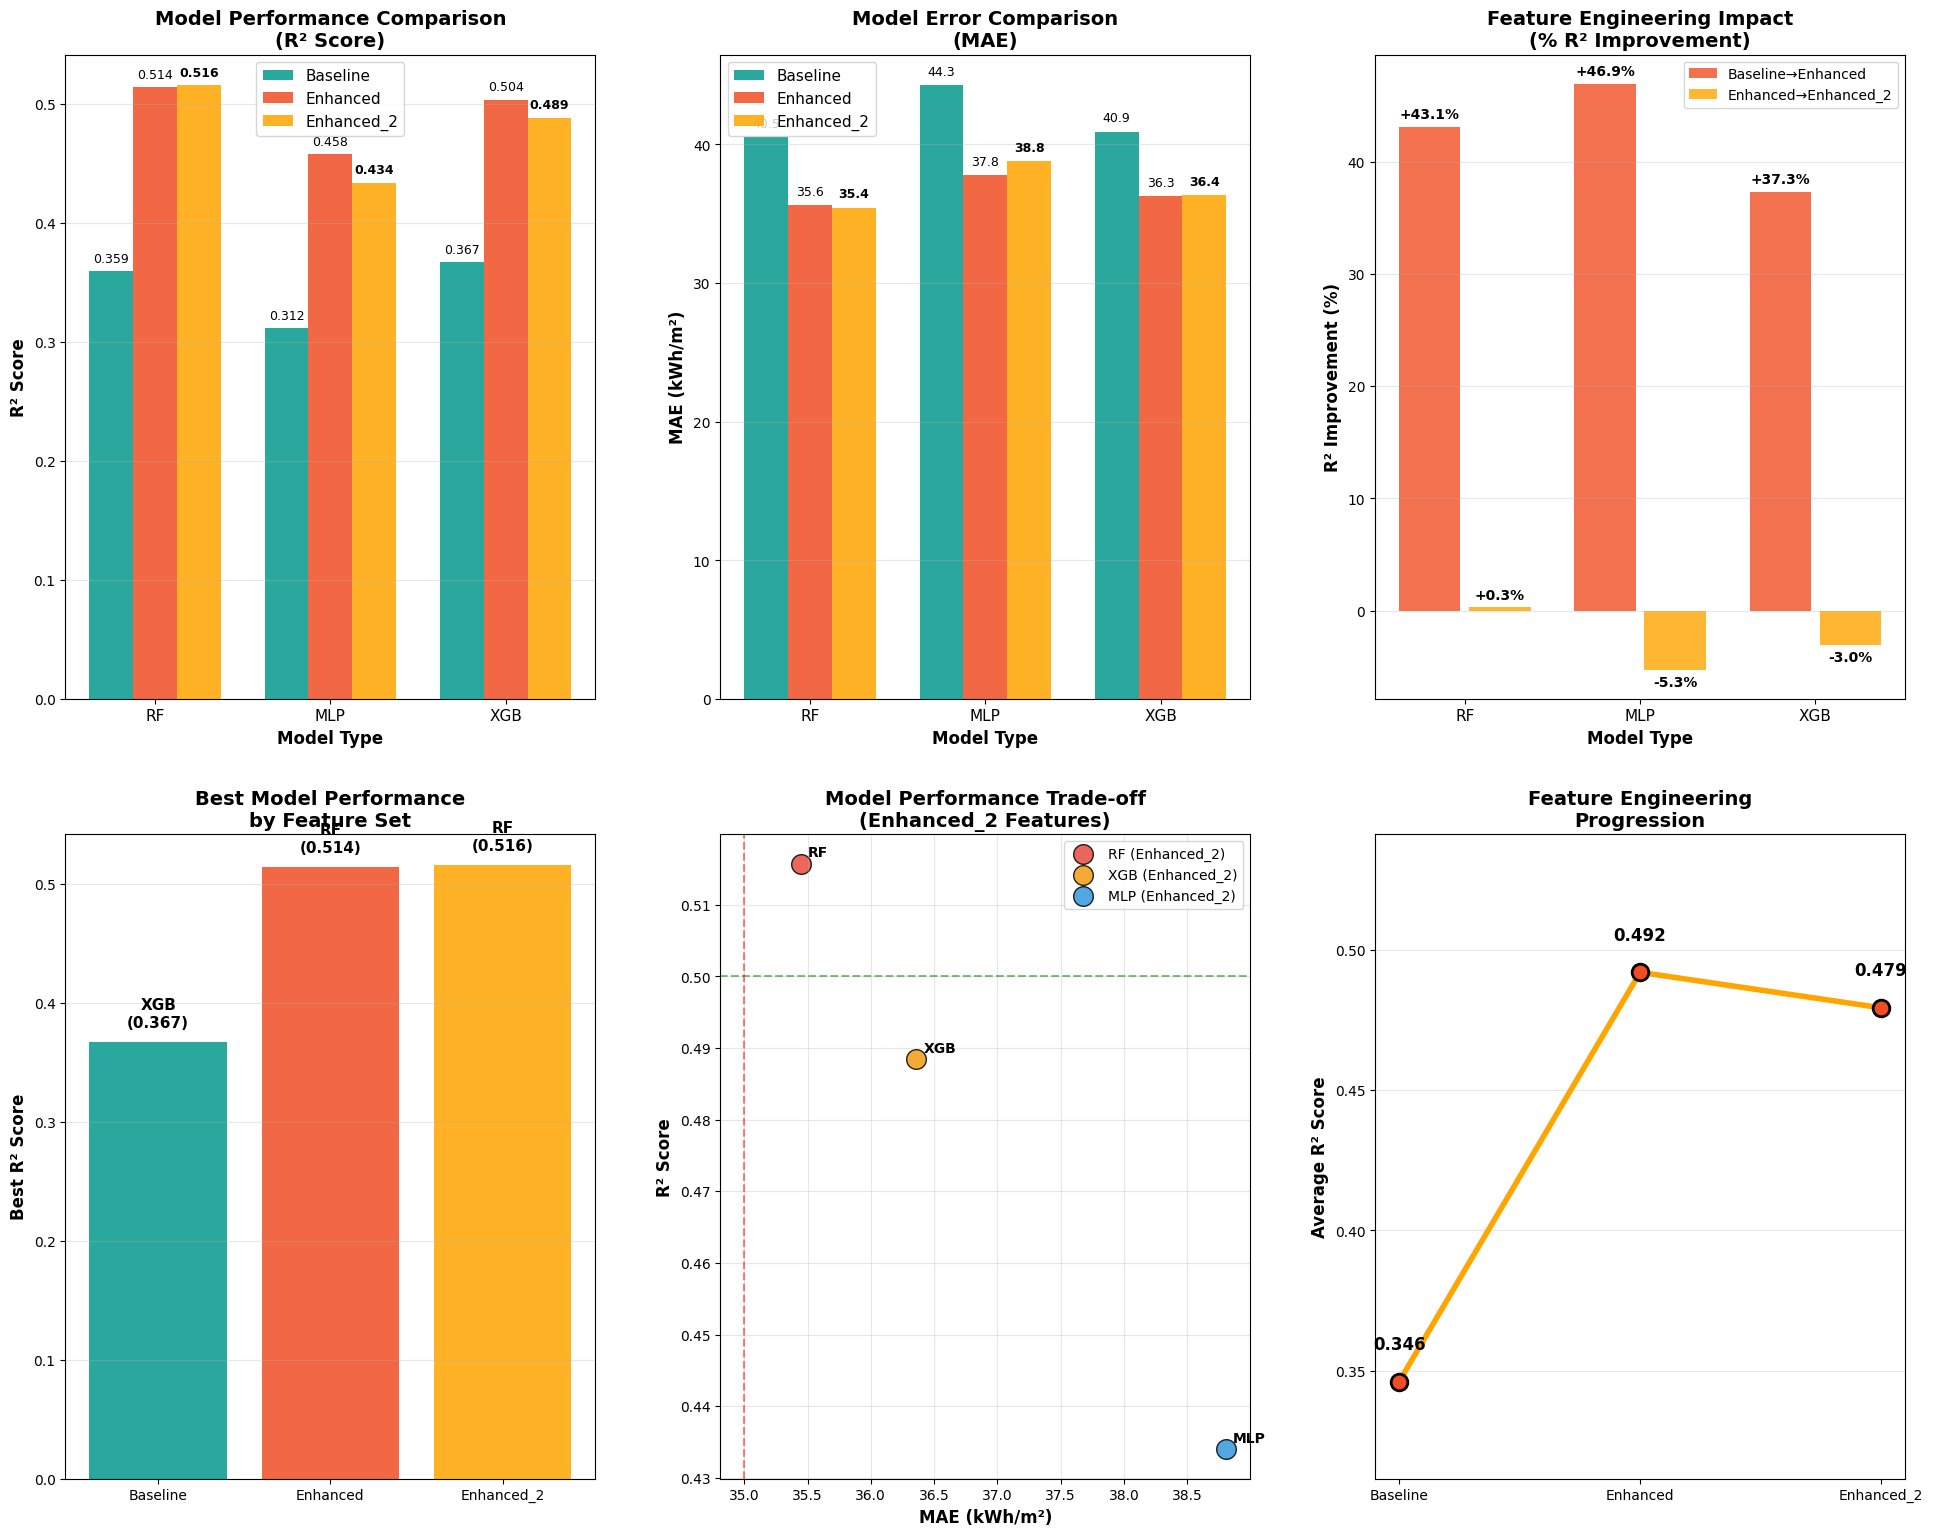

In [ ]:
def visualize_model_results_enhanced_3_features(results_df):
    """
    Visualize model results with 3 feature sets: Baseline, Enhanced, Enhanced_2
    Enhanced_2 uses color #FFA500, LSTM is removed from all visualizations
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    plt.style.use('default')
    sns.set_palette("husl")

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 16))

    # Model colors (without LSTM)
    colors = {
        'RF': '#e74c3c',      # Red
        'MLP': '#3498db',     # Blue
        'XGB': '#f39c12',     # Orange
    }

    # Feature set colors
    BASELINE_COLOR = '#05998c'    # teal
    ENHANCED_COLOR = '#f04d23'    # orange-red
    ENHANCED_2_COLOR = '#FFA500'  # orange - your requested color

    # Filter out LSTM from results
    results_no_lstm = results_df[results_df['Model'] != 'LSTM'].copy()

    # 1. R² Score Comparison (3 feature sets)
    ax1 = plt.subplot(2, 3, 1)

    # Get data for all 3 feature sets
    baseline_data = results_no_lstm[results_no_lstm['Features'] == 'Baseline'].set_index('Model')['R²']
    enhanced_data = results_no_lstm[results_no_lstm['Features'] == 'Enhanced'].set_index('Model')['R²']
    enhanced_2_data = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2'].set_index('Model')['R²']

    # Ensure all have same index (models)
    models = ['RF', 'MLP', 'XGB']
    baseline_data = baseline_data.reindex(models, fill_value=0)
    enhanced_data = enhanced_data.reindex(models, fill_value=0)
    enhanced_2_data = enhanced_2_data.reindex(models, fill_value=0)

    x = np.arange(len(models))
    width = 0.25

    bars1 = ax1.bar(x - width, baseline_data.values, width,
                    label='Baseline', alpha=0.85, color=BASELINE_COLOR)
    bars2 = ax1.bar(x, enhanced_data.values, width,
                    label='Enhanced', alpha=0.85, color=ENHANCED_COLOR)
    bars3 = ax1.bar(x + width, enhanced_2_data.values, width,
                    label='Enhanced_2', alpha=0.85, color=ENHANCED_2_COLOR)

    ax1.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax1.set_title('Model Performance Comparison\n(R² Score)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, fontsize=11)
    ax1.legend(fontsize=11)
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:  # Only label non-zero bars
                ax1.text(bar.get_x() + bar.get_width()/2., h + 0.005, f'{h:.3f}',
                         ha='center', va='bottom', fontsize=9,
                         fontweight='bold' if bars == bars3 else 'normal')

    # 2. MAE Comparison (3 feature sets)
    ax2 = plt.subplot(2, 3, 2)

    baseline_mae = results_no_lstm[results_no_lstm['Features'] == 'Baseline'].set_index('Model')['MAE']
    enhanced_mae = results_no_lstm[results_no_lstm['Features'] == 'Enhanced'].set_index('Model')['MAE']
    enhanced_2_mae = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2'].set_index('Model')['MAE']

    baseline_mae = baseline_mae.reindex(models, fill_value=0)
    enhanced_mae = enhanced_mae.reindex(models, fill_value=0)
    enhanced_2_mae = enhanced_2_mae.reindex(models, fill_value=0)

    bars4 = ax2.bar(x - width, baseline_mae.values, width,
                    label='Baseline', alpha=0.85, color=BASELINE_COLOR)
    bars5 = ax2.bar(x, enhanced_mae.values, width,
                    label='Enhanced', alpha=0.85, color=ENHANCED_COLOR)
    bars6 = ax2.bar(x + width, enhanced_2_mae.values, width,
                    label='Enhanced_2', alpha=0.85, color=ENHANCED_2_COLOR)

    ax2.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax2.set_ylabel('MAE (kWh/m²)', fontsize=12, fontweight='bold')
    ax2.set_title('Model Error Comparison\n(MAE)', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(models, fontsize=11)
    ax2.legend(fontsize=11)
    ax2.grid(axis='y', alpha=0.3)

    # Add value labels
    for bars in [bars4, bars5, bars6]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax2.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}',
                         ha='center', va='bottom', fontsize=9,
                         fontweight='bold' if bars == bars6 else 'normal')

    # 3. Feature Engineering Impact (Two improvements: Baseline→Enhanced, Enhanced→Enhanced_2)
    ax3 = plt.subplot(2, 3, 3)

    improvements_1 = []  # Baseline → Enhanced
    improvements_2 = []  # Enhanced → Enhanced_2
    model_names = []

    for model in models:
        baseline = results_no_lstm[(results_no_lstm['Model'] == model) & (results_no_lstm['Features'] == 'Baseline')]
        enhanced = results_no_lstm[(results_no_lstm['Model'] == model) & (results_no_lstm['Features'] == 'Enhanced')]
        enhanced_2 = results_no_lstm[(results_no_lstm['Model'] == model) & (results_no_lstm['Features'] == 'Enhanced_2')]

        # Baseline → Enhanced improvement
        if len(baseline) > 0 and len(enhanced) > 0 and baseline.iloc[0]['R²'] != 0:
            imp1 = (enhanced.iloc[0]['R²'] - baseline.iloc[0]['R²']) / baseline.iloc[0]['R²'] * 100
            improvements_1.append(imp1)
        else:
            improvements_1.append(0)

        # Enhanced → Enhanced_2 improvement
        if len(enhanced) > 0 and len(enhanced_2) > 0 and enhanced.iloc[0]['R²'] != 0:
            imp2 = (enhanced_2.iloc[0]['R²'] - enhanced.iloc[0]['R²']) / enhanced.iloc[0]['R²'] * 100
            improvements_2.append(imp2)
        else:
            improvements_2.append(0)

        model_names.append(model)

    x_pos = np.arange(len(model_names))
    bars7 = ax3.bar(x_pos - 0.2, improvements_1, 0.35,
                   label='Baseline→Enhanced', color=ENHANCED_COLOR, alpha=0.8)
    bars8 = ax3.bar(x_pos + 0.2, improvements_2, 0.35,
                   label='Enhanced→Enhanced_2', color=ENHANCED_2_COLOR, alpha=0.8)

    ax3.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax3.set_ylabel('R² Improvement (%)', fontsize=12, fontweight='bold')
    ax3.set_title('Feature Engineering Impact\n(% R² Improvement)', fontsize=14, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(model_names, fontsize=11)
    ax3.legend(fontsize=10)
    ax3.grid(axis='y', alpha=0.3)

    # Add value labels
    for bars, improvements in [(bars7, improvements_1), (bars8, improvements_2)]:
        for bar, imp in zip(bars, improvements):
            h = bar.get_height()
            if abs(h) > 0.1:  # Only label significant improvements
                ax3.text(bar.get_x() + bar.get_width()/2., h + (0.5 if h > 0 else -0.5),
                         f'{imp:+.1f}%', ha='center',
                         va='bottom' if h > 0 else 'top',
                         fontsize=10, fontweight='bold')

    # 4. Best Performance by Feature Set
    ax4 = plt.subplot(2, 3, 4)

    feature_sets = ['Baseline', 'Enhanced', 'Enhanced_2']
    feature_colors = [BASELINE_COLOR, ENHANCED_COLOR, ENHANCED_2_COLOR]
    best_r2_values = []
    best_models = []

    for feature_set in feature_sets:
        subset = results_no_lstm[results_no_lstm['Features'] == feature_set]
        if len(subset) > 0:
            best_idx = subset['R²'].idxmax()
            best_row = subset.loc[best_idx]
            best_r2_values.append(best_row['R²'])
            best_models.append(f"{best_row['Model']}\n({best_row['R²']:.3f})")
        else:
            best_r2_values.append(0)
            best_models.append('N/A')

    bars9 = ax4.bar(feature_sets, best_r2_values, color=feature_colors, alpha=0.85)

    for bar, model_info in zip(bars9, best_models):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01, model_info,
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax4.set_ylabel('Best R² Score', fontsize=12, fontweight='bold')
    ax4.set_title('Best Model Performance\nby Feature Set', fontsize=14, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)

    # 5. Scatter Plot: R² vs MAE for Enhanced_2 features only (no LSTM)
    ax5 = plt.subplot(2, 3, 5)
    enhanced_2_results = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2']

    for model in enhanced_2_results['Model'].unique():
        d = enhanced_2_results[enhanced_2_results['Model'] == model]
        ax5.scatter(d['MAE'], d['R²'], s=200, alpha=0.85, color=colors[model],
                    label=f'{model} (Enhanced_2)', edgecolors='black', linewidth=1)
        for _, row in d.iterrows():
            ax5.annotate(f'{model}', (row['MAE'], row['R²']),
                         xytext=(5, 5), textcoords='offset points',
                         fontsize=10, fontweight='bold')

    ax5.set_xlabel('MAE (kWh/m²)', fontsize=12, fontweight='bold')
    ax5.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax5.set_title('Model Performance Trade-off\n(Enhanced_2 Features)', fontsize=14, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    ax5.legend(fontsize=10)

    # Guide lines
    ax5.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Good R² (>0.5)')
    ax5.axvline(x=35, color='red', linestyle='--', alpha=0.5, label='Good MAE (<35)')

    # 6. Feature Set Progression (Average performance across models)
    ax6 = plt.subplot(2, 3, 6)

    avg_r2_by_feature = []
    for feature_set in feature_sets:
        subset = results_no_lstm[results_no_lstm['Features'] == feature_set]
        if len(subset) > 0:
            avg_r2 = subset['R²'].mean()
            avg_r2_by_feature.append(avg_r2)
        else:
            avg_r2_by_feature.append(0)

    ax6.plot(feature_sets, avg_r2_by_feature, 'o-', linewidth=4, markersize=12,
             color=ENHANCED_2_COLOR, markerfacecolor=ENHANCED_COLOR,
             markeredgecolor='black', markeredgewidth=2)

    for i, (x, y) in enumerate(zip(feature_sets, avg_r2_by_feature)):
        ax6.text(i, y + 0.01, f'{y:.3f}', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    ax6.set_ylabel('Average R² Score', fontsize=12, fontweight='bold')
    ax6.set_title('Feature Engineering\nProgression', fontsize=14, fontweight='bold')
    ax6.grid(axis='y', alpha=0.3)

    # Set y-axis to show the progression clearly
    if max(avg_r2_by_feature) > 0:
        ax6.set_ylim(min(avg_r2_by_feature) * 0.9, max(avg_r2_by_feature) * 1.1)

    plt.tight_layout(pad=3.0)

    plt.show()
    return fig

# Usage: Replace your existing visualization call with this
fig = visualize_model_results_enhanced_3_features(tuned_results)

Inference

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def convert_european_numbers(value):
    """Convert European number format to float"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.replace(',', '.'))
        except:
            return np.nan
    return np.nan

def prepare_target_data(df, target_column='en2025_enegy_demand_present_m2'):
    """Prepare target with outlier handling"""
    # Convert European numbers
    target = df[target_column].apply(convert_european_numbers)

    # Remove extreme outliers
    Q1, Q3 = target.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 2.0 * IQR
    upper_bound = Q3 + 2.0 * IQR

    valid_idx = (target.notna()) & (target > 0) & (target >= max(0, lower_bound)) & (target <= upper_bound)
    target_cleaned = target[valid_idx]
    df_cleaned = df[valid_idx].copy()

    # Check target skewness and transform if needed
    skewness = stats.skew(target_cleaned)
    use_log_target = abs(skewness) > 1

    if use_log_target:
        target_transformed = np.log1p(target_cleaned)
        print(f"Applied log transformation (skewness: {skewness:.2f})")
    else:
        target_transformed = target_cleaned.copy()
        print(f"No transformation needed (skewness: {skewness:.2f})")

    return df_cleaned, target_cleaned, target_transformed, use_log_target

def get_decade_from_year(year):
    """Convert year to decade"""
    if pd.isna(year) or year == 0:
        return 1990
    return int(year // 10) * 10

def calculate_decade_averages_from_data(df, target_column='en2025_enegy_demand_present_m2', min_buildings_per_decade=2):
    """Calculate decade averages from data"""
    global decade_avg_energy_from_data
    df_clean = df.copy()

    # Convert European numbers
    df_clean['energy_target'] = df_clean[target_column].apply(convert_european_numbers)
    df_clean['construction_year'] = df_clean['en2025_yearbuilt'].apply(convert_european_numbers)

    # Filter for valid data
    valid_data = df_clean[
        (df_clean['energy_target'].notna()) &
        (df_clean['energy_target'] > 0) &
        (df_clean['construction_year'].notna()) &
        (df_clean['construction_year'] > 1900) &
        (df_clean['d_Category'].notna())
    ].copy()

    print(f"Using {len(valid_data)} buildings with valid energy and year data")

    # Calculate decade
    valid_data['construction_decade'] = valid_data['construction_year'].apply(get_decade_from_year)

    # Calculate averages by category and decade
    decade_averages = valid_data.groupby(['d_Category', 'construction_decade'])['energy_target'].agg(['mean', 'count']).reset_index()

    # Convert to nested dictionary format
    decade_avg_energy_from_data = {}

    for _, row in decade_averages.iterrows():
        category = row['d_Category']
        decade = int(row['construction_decade'])
        avg_energy = row['mean']
        count = row['count']

        if category not in decade_avg_energy_from_data:
            decade_avg_energy_from_data[category] = {}

        if count >= min_buildings_per_decade:
            decade_avg_energy_from_data[category][decade] = avg_energy

    return decade_avg_energy_from_data

def create_correlation_dictionaries(df):
    """Create correlation dictionaries"""
    energy_columns = {
        'ED': 'en2025_enegy_demand_present_m2',
        'PE': 'en2025_enegy_demand_after_m2'  # Using after as PE proxy
    }
    type_col = 'd_Category'
    year_col = 'en2025_yearbuilt'
    results = {}

    for energy_type, energy_col in energy_columns.items():
        print(f"Processing {energy_type} correlations")

        # Convert European numbers and filter data
        df_filtered = df[[type_col, year_col, energy_col]].copy()
        df_filtered[year_col] = df_filtered[year_col].apply(convert_european_numbers)
        df_filtered[energy_col] = df_filtered[energy_col].apply(convert_european_numbers)
        df_filtered = df_filtered.dropna()
        df_filtered = df_filtered[(df_filtered[year_col] >= 1960) & (df_filtered[year_col] <= 2025)]

        # Create decades
        df_filtered['Decade'] = (df_filtered[year_col] // 10) * 10

        # Get building types with sufficient data
        building_types = df_filtered[type_col].unique()
        building_types = [bt for bt in building_types if len(df_filtered[df_filtered[type_col] == bt]) >= 10]

        correlations = {}

        # Calculate for each building type
        for building_type in building_types:
            type_data = df_filtered[df_filtered[type_col] == building_type]
            decades = sorted(type_data['Decade'].unique())

            correlations[building_type] = {}

            for decade in decades:
                decade_data = type_data[type_data['Decade'] == decade]

                if len(decade_data) >= 5:
                    # Calculate age within decade
                    decade_data_copy = decade_data.copy()
                    decade_data_copy['Age'] = decade + 5 - decade_data_copy[year_col]

                    # Calculate correlation
                    corr = decade_data_copy['Age'].corr(decade_data_copy[energy_col])
                    if not pd.isna(corr):
                        correlations[building_type][int(decade)] = round(corr, 2)

        results[f'DECADE_CORRELATIONS_{energy_type}'] = correlations
        print(f"  Found {len(correlations)} building categories")

    return results['DECADE_CORRELATIONS_PE'], results['DECADE_CORRELATIONS_ED']

def get_decade_correlation_ed(category, decade):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_ED:
        decade_data = DECADE_CORRELATIONS_ED[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def get_decade_correlation_pe(category, decade):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_PE:
        decade_data = DECADE_CORRELATIONS_PE[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def create_enhanced_2_features(df, target_column='en2025_enegy_demand_present_m2'):
    """Create Enhanced 2 features (Enhanced + construction_type + nbuildingy)"""
    # Calculate decade averages first
    calculate_decade_averages_from_data(df, target_column, 2)

    features = pd.DataFrame()

    # Basic features with outlier handling
    area_cols = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3']
    feature_names = ['area_heated', 'area_total', 'volume_heated']

    for i, col in enumerate(feature_names):
        values = df[area_cols[i]].apply(convert_european_numbers)
        Q1, Q3 = values.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        features[col] = values.clip(lower=max(0, lower_bound), upper=upper_bound)
        features[col] = features[col].fillna(features[col].median())

    features['construction_year'] = df['en2025_yearbuilt'].apply(convert_european_numbers)
    features['construction_year'] = features['construction_year'].fillna(features['construction_year'].median())

    # Additional features
    if 'd_Correlation_Energy_Demand' in df.columns:
        features['Correlation_ED'] = df['d_Correlation_Energy_Demand'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_ED'] = 0

    if 'd_Correlation_Primary_Energy' in df.columns:
        features['Correlation_PM'] = df['d_Correlation_Primary_Energy'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_PM'] = 0

    if 'd_Energy_Completeness_Pct' in df.columns:
        features['Energy_Completeness_Pct'] = df['d_Energy_Completeness_Pct'].apply(convert_european_numbers).fillna(0)
    else:
        features['Energy_Completeness_Pct'] = 0

    # Category and decade
    features['building_category'] = df['d_Category'].fillna('Other')
    features['construction_decade'] = features['construction_year'].apply(get_decade_from_year)

    # Key temporal features
    features['decade_correlation_pe'] = features.apply(lambda row: get_decade_correlation_pe(row['building_category'], row['construction_decade']), axis=1)
    features['decade_correlation_ed'] = features.apply(lambda row: get_decade_correlation_ed(row['building_category'], row['construction_decade']), axis=1)

    # Enhanced features
    features['building_age'] = 2025 - features['construction_year']
    features['log_building_age'] = np.log1p(features['building_age'])

    # Ratios
    features['heating_efficiency_ratio'] = features['area_heated'] / (features['area_total'] + 1)
    features['area_to_volume_ratio'] = features['area_heated'] / (features['volume_heated'] + 1)

    # Enhanced_2 specific features
    if 'construction_type' in df.columns:
        features['construction_type'] = df['construction_type'].fillna('Unknown')
    else:
        features['construction_type'] = 'Unknown'

    if 'nbuildingy' in df.columns:
        features['nbuildingy'] = df['nbuildingy'].apply(convert_european_numbers).fillna(features['construction_year'].median())
    else:
        features['nbuildingy'] = features['construction_year']

    # Fill any remaining NaN values
    numeric_cols = features.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        features[col] = features[col].replace([np.inf, -np.inf], np.nan)
        features[col] = features[col].fillna(features[col].median())

    return features

def train_xgboost_enhanced2_and_predict_all(df_training, df_all_buildings, target_column='en2025_enegy_demand_present_m2'):

    # Initialize correlation dictionaries using training data
    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = create_correlation_dictionaries(df_training)

    # Prepare training data
    print("\nPreparing training data...")
    df_clean, target_cleaned, target_transformed, use_log_target = prepare_target_data(df_training, target_column)

    # Create Enhanced_2 features for training
    print("Creating Enhanced_2 features for training...")
    X_train_features = create_enhanced_2_features(df_clean, target_column)

    print(f"Training features shape: {X_train_features.shape}")
    print(f"Training samples: {len(target_transformed)}")

    # Encode categorical variables for training
    label_encoders = {}
    X_train_encoded = X_train_features.copy()

    for col in X_train_encoded.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X_train_encoded[col] = le.fit_transform(X_train_encoded[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded {col}: {len(le.classes_)} unique values")

    # Clean training data
    X_train_encoded = X_train_encoded.replace([np.inf, -np.inf], np.nan).fillna(X_train_encoded.median())

    # Split training data for validation
    X_train, X_val, y_train, y_val = train_test_split(X_train_encoded, target_transformed,
                                                     test_size=0.2, random_state=42)

    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")

    # Hyperparameter tuning for XGBoost
    print("\nTuning XGBoost hyperparameters...")
    xgb_params = {
        'n_estimators': [200, 300, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.15],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }

    xgb_grid = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        xgb_params, n_iter=20, cv=3, scoring='r2',
        random_state=42, n_jobs=-1
    )

    xgb_grid.fit(X_train, y_train)
    print(f"Best XGBoost params: {xgb_grid.best_params_}")

    # Validate model performance
    val_pred = xgb_grid.predict(X_val)

    if use_log_target:
        y_val_original = np.expm1(y_val)
        val_pred_original = np.expm1(val_pred)
    else:
        y_val_original = y_val
        val_pred_original = val_pred

    mae = mean_absolute_error(y_val_original, val_pred_original)
    r2 = r2_score(y_val_original, val_pred_original)

    print(f"\nValidation Results:")
    print(f"MAE: {mae:.2f} kWh/m²")
    print(f"R²: {r2:.3f}")

    # Now prepare ALL buildings for prediction
    print(f"\nPreparing all {len(df_all_buildings)} buildings for prediction...")

    # Create Enhanced_2 features for all buildings
    X_all_features = create_enhanced_2_features(df_all_buildings, target_column)

    print(f"All buildings features shape: {X_all_features.shape}")

    # Encode categorical variables for all buildings using the same encoders
    X_all_encoded = X_all_features.copy()

    for col in X_all_encoded.select_dtypes(include=['object']).columns:
        if col in label_encoders:
            le = label_encoders[col]
            # Handle unseen categories
            def safe_transform(x):
                try:
                    return le.transform([str(x)])[0]
                except ValueError:
                    # Return the most common class for unseen categories
                    return le.transform([le.classes_[0]])[0]

            X_all_encoded[col] = X_all_encoded[col].astype(str).apply(safe_transform)
        else:
            # If column wasn't in training data, encode it separately
            le_new = LabelEncoder()
            X_all_encoded[col] = le_new.fit_transform(X_all_encoded[col].astype(str))

    # Clean all buildings data
    X_all_encoded = X_all_encoded.replace([np.inf, -np.inf], np.nan).fillna(X_all_encoded.median())

    # Ensure all buildings have the same features as training data
    missing_cols = set(X_train_encoded.columns) - set(X_all_encoded.columns)
    extra_cols = set(X_all_encoded.columns) - set(X_train_encoded.columns)

    # Add missing columns with median values
    for col in missing_cols:
        X_all_encoded[col] = X_train_encoded[col].median()
        print(f"Added missing column {col} with median value")

    # Remove extra columns
    for col in extra_cols:
        X_all_encoded = X_all_encoded.drop(columns=[col])
        print(f"Removed extra column {col}")

    # Reorder columns to match training data
    X_all_encoded = X_all_encoded[X_train_encoded.columns]

    print(f"Final prediction features shape: {X_all_encoded.shape}")

    # Make predictions for all buildings
    print("Generating predictions for all buildings...")
    predictions_transformed = xgb_grid.predict(X_all_encoded)

    # Transform predictions back to original scale if needed
    if use_log_target:
        predictions = np.expm1(predictions_transformed)
        print("Transformed predictions back from log scale")
    else:
        predictions = predictions_transformed

    print(f"\nPrediction Summary:")
    print(f"Mean prediction: {predictions.mean():.2f} kWh/m²")
    print(f"Median prediction: {np.median(predictions):.2f} kWh/m²")
    print(f"Min prediction: {predictions.min():.2f} kWh/m²")
    print(f"Max prediction: {predictions.max():.2f} kWh/m²")

    # Model information
    model_info = {
        'model': xgb_grid.best_estimator_,
        'best_params': xgb_grid.best_params_,
        'validation_mae': mae,
        'validation_r2': r2,
        'use_log_target': use_log_target,
        'feature_names': list(X_train_encoded.columns),
        'label_encoders': label_encoders,
        'training_samples': len(X_train) + len(X_val),
        'prediction_samples': len(predictions)
    }

    return predictions, model_info

predictions, model_info = train_xgboost_enhanced2_and_predict_all(
    df_training=overlapping_gdf_dataset,
    df_all_buildings=gdf_data,
    target_column='en2025_enegy_demand_present_m2'
)

Processing ED correlations
  Found 12 building categories
Processing PE correlations
  Found 12 building categories

Preparing training data...
No transformation needed (skewness: 0.76)
Creating Enhanced_2 features for training...
Using 1813 buildings with valid energy and year data
Training features shape: (1914, 17)
Training samples: 1914
Encoded building_category: 16 unique values
Encoded construction_type: 2 unique values
Train set: 1531 samples
Validation set: 383 samples

Tuning XGBoost hyperparameters...
Best XGBoost params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Validation Results:
MAE: 36.59 kWh/m²
R²: 0.495

Preparing all 266368 buildings for prediction...
Using 1892 buildings with valid energy and year data
All buildings features shape: (266368, 17)
Final prediction features shape: (266368, 17)
Generating predictions for all buildings...

Prediction Summary:
Mean prediction: 152.69 kWh/m²
Median prediction: 15

PLOT

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import geopandas as gpd
from matplotlib.patches import Patch
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def create_geographic_energy_heatmap(gdf_with_predictions, prediction_column='predicted_energy_demand_xgb_enhanced2',
                                   figsize=(20, 16), dpi=150, save_path=None):


    # Ensure we have valid geometry and predictions
    gdf_clean = gdf_with_predictions[
        (gdf_with_predictions.geometry.notna()) &
        (gdf_with_predictions[prediction_column].notna())
    ].copy()

    print(f"Plotting {len(gdf_clean):,} buildings with valid geometry and predictions")

    if len(gdf_clean) == 0:
        print("No valid data to plot!")
        return

    # Check coordinate system
    bounds = gdf_clean.total_bounds  # [minx, miny, maxx, maxy]
    is_projected = (abs(bounds[0]) > 180 or abs(bounds[2]) > 180 or
                   abs(bounds[1]) > 90 or abs(bounds[3]) > 90)

    if is_projected:
        print(f"Detected projected coordinate system (bounds: X={bounds[0]:.0f}-{bounds[2]:.0f}, Y={bounds[1]:.0f}-{bounds[3]:.0f})")
        coord_labels = ('Easting (m)', 'Northing (m)')
        coord_format = '{:.0f}'
    else:
        print(f"Detected geographic coordinate system (bounds: Lon={bounds[0]:.3f}-{bounds[2]:.3f}, Lat={bounds[1]:.3f}-{bounds[3]:.3f})")
        coord_labels = ('Longitude', 'Latitude')
        coord_format = '{:.3f}'

    # Get prediction statistics for color mapping
    predictions = gdf_clean[prediction_column]
    pred_min, pred_max = predictions.min(), predictions.max()
    pred_mean, pred_median = predictions.mean(), predictions.median()
    pred_std = predictions.std()

    print(f"Prediction range: {pred_min:.1f} - {pred_max:.1f} kWh/m²")
    print(f"Mean: {pred_mean:.1f}, Median: {pred_median:.1f}, Std: {pred_std:.1f}")

    # Create figure with multiple subplots
    fig = plt.figure(figsize=figsize, dpi=dpi)

    # Define custom colormap (blue to red for cold to hot)
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']  # Blue -> Purple -> Orange -> Red
    n_bins = 256
    custom_cmap = LinearSegmentedColormap.from_list('energy_demand', colors, N=n_bins)

    # Main heatmap (takes up most of the space)
    ax_main = plt.subplot2grid((4, 4), (0, 0), colspan=3, rowspan=3)

    # Plot the heatmap
    print("Rendering main heatmap...")

    # Use different visualization strategies based on data size
    if len(gdf_clean) > 50000:
        # For very large datasets, use smaller linewidth and markers
        gdf_clean.plot(column=prediction_column, cmap=custom_cmap,
                      linewidth=0.05, edgecolor='none',
                      ax=ax_main, alpha=0.8)
        print("Using optimized rendering for large dataset")
    elif len(gdf_clean) > 10000:
        # Medium datasets
        gdf_clean.plot(column=prediction_column, cmap=custom_cmap,
                      linewidth=0.1, edgecolor='white',
                      ax=ax_main, alpha=0.9)
        print("Using medium detail rendering")
    else:
        # Smaller datasets - full detail
        gdf_clean.plot(column=prediction_column, cmap=custom_cmap,
                      linewidth=0.2, edgecolor='white',
                      ax=ax_main, alpha=0.9)
        print("Using high detail rendering")

    # Set equal aspect ratio to prevent distortion - with error handling
    try:
        ax_main.set_aspect('equal', adjustable='box')
    except ValueError:
        # If equal aspect fails, calculate appropriate aspect ratio
        x_range = bounds[2] - bounds[0]
        y_range = bounds[3] - bounds[1]
        if x_range > 0 and y_range > 0:
            aspect_ratio = y_range / x_range
            try:
                ax_main.set_aspect(aspect_ratio)
            except:
                print("Warning: Could not set aspect ratio, using default")
        else:
            print("Warning: Invalid coordinate range, using default aspect ratio")

    # Customize main map
    ax_main.set_title(f'Building Energy Demand Predictions\n{len(gdf_clean):,} Buildings',
                     fontsize=16, fontweight='bold', pad=20)
    ax_main.set_xlabel(coord_labels[0], fontsize=12)
    ax_main.set_ylabel(coord_labels[1], fontsize=12)
    ax_main.grid(True, alpha=0.3)

    # Format coordinate labels
    if is_projected:
        # For projected coordinates, use scientific notation or simplified labels
        ax_main.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=custom_cmap,
                              norm=plt.Normalize(vmin=pred_min, vmax=pred_max))
    sm._A = []
    cbar = plt.colorbar(sm, ax=ax_main, shrink=0.8, pad=0.02)
    cbar.set_label('Predicted Energy Demand (kWh/m²)', rotation=270, labelpad=20, fontsize=12)

    # Add statistics text box
    stats_text = f"""Statistics:
Mean: {pred_mean:.1f} kWh/m²
Median: {pred_median:.1f} kWh/m²
Min: {pred_min:.1f} kWh/m²
Max: {pred_max:.1f} kWh/m²
Std Dev: {pred_std:.1f} kWh/m²"""

    ax_main.text(0.02, 0.98, stats_text, transform=ax_main.transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
                verticalalignment='top', fontsize=10, family='monospace')

    # Distribution histogram (right side)
    ax_hist = plt.subplot2grid((4, 4), (0, 3), rowspan=2)
    ax_hist.hist(predictions, bins=50, orientation='horizontal', color='skyblue',
                alpha=0.7, edgecolor='black', density=True)
    ax_hist.axhline(pred_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {pred_mean:.1f}')
    ax_hist.axhline(pred_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {pred_median:.1f}')
    ax_hist.set_ylabel('Predicted Energy Demand (kWh/m²)')
    ax_hist.set_xlabel('Density')
    ax_hist.set_title('Distribution', fontweight='bold')
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.3)

    # Percentile-based categorization (bottom right)
    ax_cat = plt.subplot2grid((4, 4), (2, 3), rowspan=2)

    # Create categories based on percentiles
    percentiles = np.percentile(predictions, [20, 40, 60, 80])  # 4 thresholds = 5 categories
    categories = ['Very Low\n(<20th)', 'Low\n(20-40th)', 'Medium\n(40-60th)',
                 'High\n(60-80th)', 'Very High\n(>80th)']

    cat_counts = []

    # First category: <= 20th percentile
    cat_counts.append((predictions <= percentiles[0]).sum())

    # Middle categories: between percentiles
    for i in range(len(percentiles) - 1):
        count = ((predictions > percentiles[i]) & (predictions <= percentiles[i+1])).sum()
        cat_counts.append(count)

    # Last category: > 80th percentile
    cat_counts.append((predictions > percentiles[-1]).sum())

    # Create pie chart
    colors_pie = ['#2E86AB', '#5B9BD5', '#F18F01', '#E07A24', '#C73E1D']
    wedges, texts, autotexts = ax_cat.pie(cat_counts, labels=categories, autopct='%1.1f%%',
                                         colors=colors_pie, startangle=90)
    ax_cat.set_title('Energy Categories\n(by Percentile)', fontweight='bold', fontsize=10)

    # Hotspots identification (bottom left)
    ax_hotspots = plt.subplot2grid((4, 4), (3, 0), colspan=3)

    # Find hotspots (top 5% highest energy buildings)
    high_energy_threshold = np.percentile(predictions, 95)
    hotspots = gdf_clean[gdf_clean[prediction_column] >= high_energy_threshold]

    print(f"Identified {len(hotspots)} high-energy buildings (>95th percentile: {high_energy_threshold:.1f} kWh/m²)")

    # Plot base map in gray
    gdf_clean.plot(color='lightgray', linewidth=0.1, edgecolor='white', ax=ax_hotspots, alpha=0.3)

    # Highlight hotspots
    if len(hotspots) > 0:
        hotspots.plot(color='red', ax=ax_hotspots, markersize=5, alpha=0.8)

    # Set equal aspect ratio for hotspots map too - with error handling
    try:
        ax_hotspots.set_aspect('equal', adjustable='box')
    except ValueError:
        x_range = bounds[2] - bounds[0]
        y_range = bounds[3] - bounds[1]
        if x_range > 0 and y_range > 0:
            aspect_ratio = y_range / x_range
            try:
                ax_hotspots.set_aspect(aspect_ratio)
            except:
                pass

    ax_hotspots.set_title(f'Energy Demand Hotspots (Top 5% - {len(hotspots):,} buildings)',
                         fontweight='bold', fontsize=12)
    ax_hotspots.set_xlabel(coord_labels[0], fontsize=10)
    ax_hotspots.grid(True, alpha=0.3)

    # Format coordinate labels for hotspots map
    if is_projected:
        ax_hotspots.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

    # Add legend for hotspots
    legend_elements = [Patch(facecolor='lightgray', alpha=0.3, label='All Buildings'),
                      Patch(facecolor='red', alpha=0.8, label=f'High Energy (>{high_energy_threshold:.1f} kWh/m²)')]
    ax_hotspots.legend(handles=legend_elements, loc='upper right', fontsize=8)

    plt.tight_layout()

    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"Heatmap saved to: {save_path}")

    plt.show()

    # Print summary statistics
    print(f"\n{'='*60}")
    print("GEOGRAPHIC ANALYSIS SUMMARY")
    print(f"{'='*60}")
    print(f"Total buildings plotted: {len(gdf_clean):,}")
    print(f"Prediction range: {pred_min:.1f} - {pred_max:.1f} kWh/m²")
    print(f"Mean energy demand: {pred_mean:.1f} kWh/m²")
    print(f"Median energy demand: {pred_median:.1f} kWh/m²")
    print(f"Standard deviation: {pred_std:.1f} kWh/m²")
    print(f"High-energy buildings (>95th percentile): {len(hotspots):,}")

    # Geographic bounds
    bounds = gdf_clean.total_bounds  # [minx, miny, maxx, maxy]
    if is_projected:
        print(f"\nGeographic coverage (projected coordinates):")
        print(f"  X (Easting): {bounds[0]:.0f} to {bounds[2]:.0f} meters")
        print(f"  Y (Northing): {bounds[1]:.0f} to {bounds[3]:.0f} meters")
    else:
        print(f"\nGeographic coverage:")
        print(f"  Longitude: {bounds[0]:.4f} to {bounds[2]:.4f}")
        print(f"  Latitude: {bounds[1]:.4f} to {bounds[3]:.4f}")

    return fig

def create_detailed_choropleth(gdf_with_predictions, prediction_column='predicted_energy_demand_xgb_enhanced2',
                              classification_scheme='quantiles', n_classes=8, figsize=(24, 18)):
    """
    Create a detailed choropleth map with statistical classification

    Args:
        gdf_with_predictions: GeoDataFrame with predictions
        prediction_column: Column with predictions
        classification_scheme: 'quantiles', 'equal_interval', or 'natural_breaks'
        n_classes: Number of classes for classification
    """

    print(f"Creating detailed choropleth with {classification_scheme} classification...")

    # Clean data
    gdf_clean = gdf_with_predictions[
        (gdf_with_predictions.geometry.notna()) &
        (gdf_with_predictions[prediction_column].notna())
    ].copy()

    predictions = gdf_clean[prediction_column]

    # Create classification
    if classification_scheme == 'quantiles':
        # Equal count in each class
        bins = np.percentile(predictions, np.linspace(0, 100, n_classes + 1))
        class_labels = [f'Q{i+1}' for i in range(n_classes)]
    elif classification_scheme == 'equal_interval':
        # Equal intervals
        bins = np.linspace(predictions.min(), predictions.max(), n_classes + 1)
        class_labels = [f'C{i+1}' for i in range(n_classes)]
    else:  # natural_breaks (simplified)
        # Use quantiles as approximation for natural breaks
        bins = np.percentile(predictions, np.linspace(0, 100, n_classes + 1))
        class_labels = [f'NB{i+1}' for i in range(n_classes)]

    # Assign classes
    gdf_clean['energy_class'] = pd.cut(predictions, bins=bins, labels=class_labels, include_lowest=True)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize, dpi=150)

    # Create color palette
    colors = plt.cm.Spectral_r(np.linspace(0, 1, n_classes))
    color_dict = dict(zip(class_labels, colors))

    # Plot choropleth
    for class_name in class_labels:
        class_data = gdf_clean[gdf_clean['energy_class'] == class_name]
        if len(class_data) > 0:
            class_data.plot(color=color_dict[class_name], ax=ax,
                          linewidth=0.1, edgecolor='white', alpha=0.8,
                          label=f'{class_name}: {len(class_data):,} buildings')

    # Customize plot
    ax.set_title(f'Building Energy Demand Classification\n{classification_scheme.title()} with {n_classes} Classes',
                fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Longitude', fontsize=14)
    ax.set_ylabel('Latitude', fontsize=14)
    ax.grid(True, alpha=0.3)

    # Add legend with statistics
    legend_text = []
    for i, class_name in enumerate(class_labels):
        class_data = gdf_clean[gdf_clean['energy_class'] == class_name]
        if len(class_data) > 0:
            min_val, max_val = bins[i], bins[i+1]
            count = len(class_data)
            pct = count / len(gdf_clean) * 100
            legend_text.append(f'{class_name}: {min_val:.0f}-{max_val:.0f} kWh/m² ({count:,} buildings, {pct:.1f}%)')

    # Create custom legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

    plt.tight_layout()
    plt.show()

    return fig, gdf_clean

# Usage example
# Assuming you have gdf_data with predictions already
# gdf_data['predicted_energy_demand'] = predictions

# Create the comprehensive heatmap
heatmap_fig = create_geographic_energy_heatmap(
    gdf_data,
    prediction_column='predicted_energy_demand',
    figsize=(24, 18),  # Large figure for detail
    dpi=150,           # High resolution
    save_path='energy_demand_heatmap.png'  # Optional: save the plot
)

KeyError: 'predicted_energy_demand'

Save to folder

In [ ]:
gdf_data.to_file(folder_path_shared_final + "final_predictions.geojson", driver="GeoJSON")

## Plots

Saved hexbin_energy_vs_size_v2.png


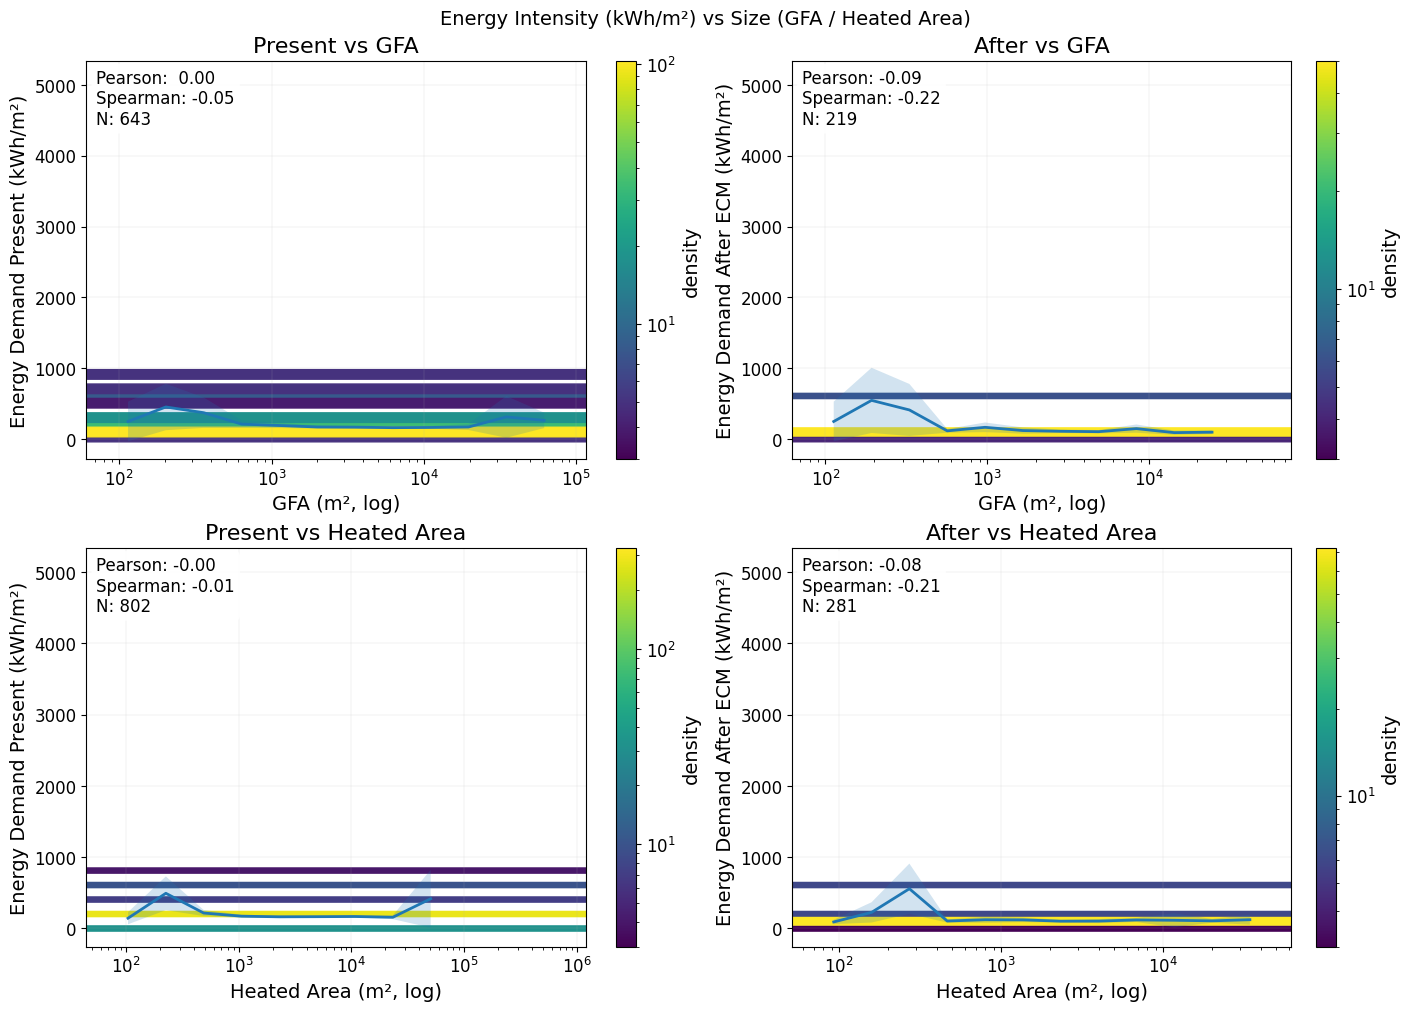

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- SETTINGS -----------------
USE_LOGX = True         # set False if log scale hides structure
ADD_JITTER = True       # jitter helps when y has only a few distinct values
JITTER_Y = 0.8          # kWh/m² jitter amplitude (adjust to your rounding granularity)
CLIP_OUTLIERS = False   # try False first; turn True only if a few points dominate
GRIDSIZE = 45
MINCNT = 3
BINS = 'log'            # 'log' or None
N_BINS_FOR_LINE = 12    # bins for binned mean line
SCATTER_FALLBACK_THRESH = 20  # if y has <= this many unique values, also draw scatter

import matplotlib.pyplot as plt

# Global font sizes
plt.rcParams.update({
    "font.size": 12,        # base font
    "axes.titlesize": 16,   # subplot titles
    "axes.labelsize": 14,   # x/y labels
    "xtick.labelsize": 12,  # tick labels
    "ytick.labelsize": 12,
    "figure.titlesize": 18  # suptitle
})


# ------------- LOAD / COALESCE --------------
try:
    df0 = pd.DataFrame(overlapping_gdf_dataset).drop(columns=["geometry"], errors="ignore")
except NameError:
    raise RuntimeError("Define `overlapping_gdf_dataset` first.")

def coalesce(df, cols):
    s = pd.Series(np.nan, index=df.index, dtype="float64")
    for c in cols:
        if c in df.columns:
            s = s.fillna(pd.to_numeric(df[c], errors="coerce"))
    return s

energy_present_m2 = coalesce(df0, ["en2025_enegy_demand_present_m2","en2023_enegy_demand_present_m2"])
energy_after_m2   = coalesce(df0, ["en2025_enegy_demand_after_m2","en2023_enegy_demand_after_m2"])
gfa_m2            = coalesce(df0, ["en2025_gfa_m2","en2023_gfa_m2"])
heated_m2         = coalesce(df0, ["en2025_area_heated_m2","en2023_area_heated_m2"])

# Optionally clip Y outliers
if CLIP_OUTLIERS:
    def clip_series(s):
        q1, q99 = s.quantile(0.01), s.quantile(0.99)
        return s.clip(lower=q1, upper=q99)
    energy_present_m2 = clip_series(energy_present_m2)
    energy_after_m2   = clip_series(energy_after_m2)

# ------------- HELPERS ----------------------
def pearson(x, y):
    x = pd.to_numeric(pd.Series(x), errors="coerce")
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    m = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3: return np.nan
    return np.corrcoef(x[m], y[m])[0,1]

def spearman(x, y):
    xr = pd.Series(x).rank(method="average")
    yr = pd.Series(y).rank(method="average")
    m = xr.notna() & yr.notna()
    if m.sum() < 3: return np.nan
    return np.corrcoef(xr[m], yr[m])[0,1]

def binned_line(ax, x, y, n_bins=10, label=None):
    x = pd.to_numeric(pd.Series(x), errors="coerce")
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    m = x.notna() & y.notna()
    x, y = x[m], y[m]
    if len(x) < 10: return
    # bin on log scale if axes are log
    if USE_LOGX:
        edges = np.logspace(np.log10(x[x>0].min()), np.log10(x.max()), n_bins+1)
    else:
        edges = np.linspace(x.min(), x.max(), n_bins+1)
    idx = np.digitize(x, edges) - 1
    xc, ym, ylo, yhi = [], [], [], []
    for i in range(n_bins):
        sel = idx == i
        if sel.sum() < 5:
            continue
        xv = x[sel]
        yv = y[sel]
        xc.append(np.exp((np.log(edges[i])+np.log(edges[i+1]))/2) if USE_LOGX else (edges[i]+edges[i+1])/2)
        m_ = yv.mean()
        s_ = yv.std(ddof=1)
        n_ = len(yv)
        # 95% CI (normal approx)
        err = 1.96 * (s_ / np.sqrt(n_))
        ym.append(m_); ylo.append(m_-err); yhi.append(m_+err)
    if xc:
        ax.plot(xc, ym, label=(label or "binned mean"), linewidth=2)
        ax.fill_between(xc, ylo, yhi, alpha=0.2)

def panel(ax, x, y, xlab, ylab, title):
    x = pd.to_numeric(pd.Series(x), errors="coerce")
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    m = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]

    if USE_LOGX:
        pos = x > 0
        x = x[pos]; y = y[pos]
        ax.set_xscale("log")

    if ADD_JITTER:
        y = y + np.random.normal(0, JITTER_Y, size=len(y))

    hb = ax.hexbin(x, y, gridsize=GRIDSIZE, mincnt=MINCNT, bins=BINS)
    cb = plt.colorbar(hb, ax=ax)
    cb.set_label("density")

    # Scatter fallback when y has few unique levels (banding)
    if y.nunique(dropna=True) <= SCATTER_FALLBACK_THRESH:
        ax.scatter(x, y, s=6, alpha=0.25)

    # Overlay binned mean + 95% CI
    binned_line(ax, x, y, n_bins=N_BINS_FOR_LINE)

    p = pearson(x, y); s = spearman(x, y)
    ax.text(0.02, 0.98, f"Pearson: {p: .2f}\nSpearman: {s: .2f}\nN: {len(x):,}",
            transform=ax.transAxes, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9))
    ax.set_xlabel(xlab); ax.set_ylabel(ylab); ax.set_title(title)
    ax.grid(True, linewidth=0.3, alpha=0.4)

# ------------- PLOT -------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

panel(axes[0,0], gfa_m2,    energy_present_m2, "GFA (m²{})".format(", log" if USE_LOGX else ""), "Energy Demand Present (kWh/m²)",     "Present vs GFA")
panel(axes[0,1], gfa_m2,    energy_after_m2,   "GFA (m²{})".format(", log" if USE_LOGX else ""), "Energy Demand After ECM (kWh/m²)",   "After vs GFA")
panel(axes[1,0], heated_m2, energy_present_m2, "Heated Area (m²{})".format(", log" if USE_LOGX else ""), "Energy Demand Present (kWh/m²)", "Present vs Heated Area")
panel(axes[1,1], heated_m2, energy_after_m2,   "Heated Area (m²{})".format(", log" if USE_LOGX else ""), "Energy Demand After ECM (kWh/m²)", "After vs Heated Area")

fig.suptitle("Energy Intensity (kWh/m²) vs Size (GFA / Heated Area)", fontsize=14)
plt.savefig("hexbin_energy_vs_size_v2.png", dpi=200)
print("Saved hexbin_energy_vs_size_v2.png")


Saved: energy_vs_year_by_category_pretty.png


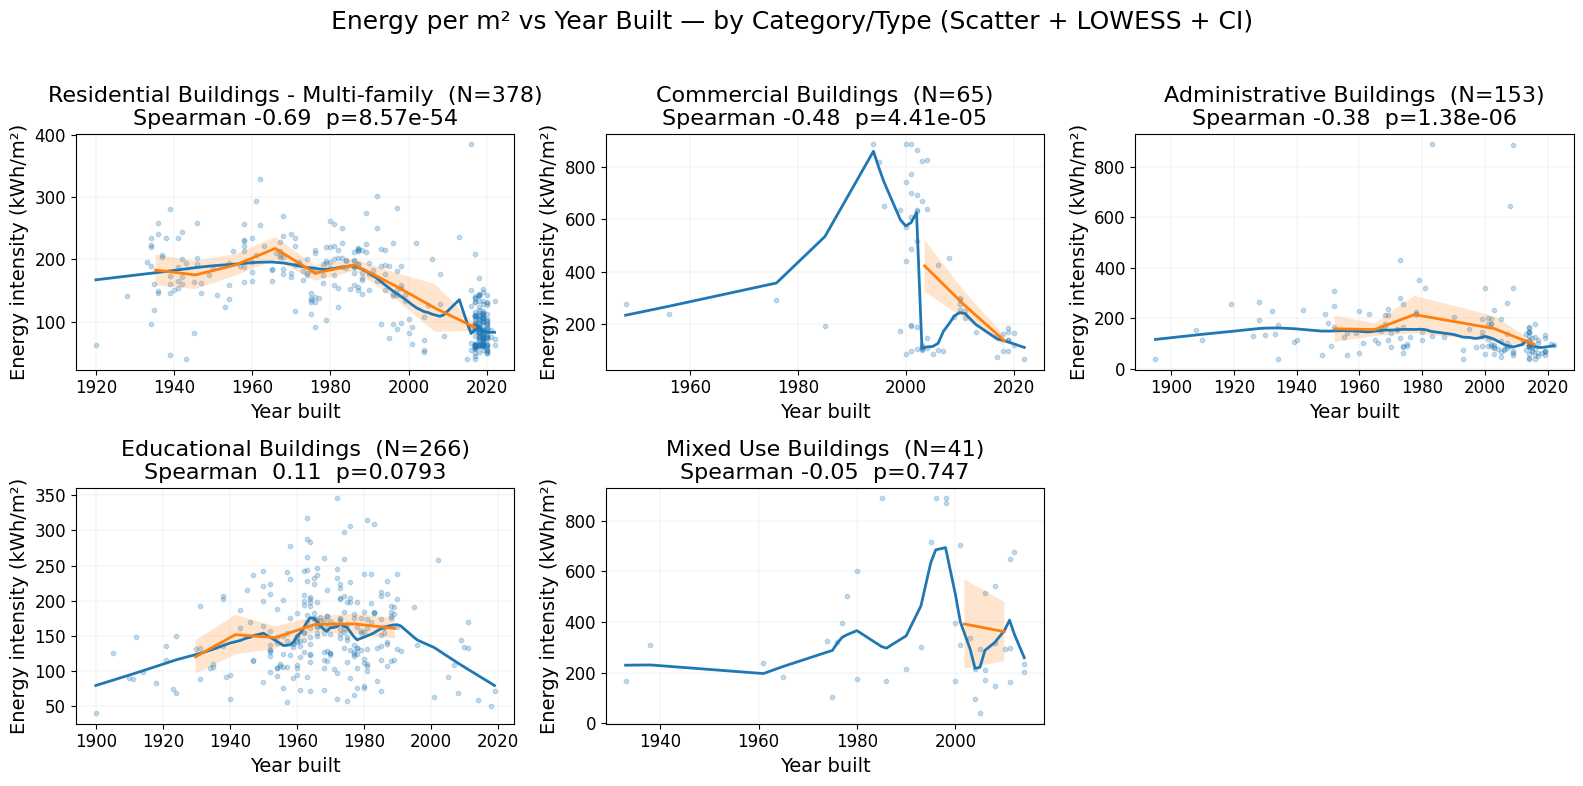

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import spearmanr

# ---- build from your DF ----
df = pd.DataFrame(overlapping_gdf_dataset).drop(columns=["geometry"], errors="ignore")

def coalesce(cols):
    s = pd.Series(np.nan, index=df.index, dtype="float64")
    for c in cols:
        if c in df.columns: s = s.fillna(pd.to_numeric(df[c], errors="coerce"))
    return s

y    = coalesce(["en2025_enegy_demand_present_m2","en2023_enegy_demand_present_m2"])
year = coalesce(["en2025_yearbuilt","en2023_yearbuilt"])
cat  = (df["d_Category"] if "d_Category" in df.columns
        else (df["en2025_type"] if "en2025_type" in df.columns else df.get("en2023_type")))
tmp  = pd.DataFrame({"y":y, "year":year, "cat":cat}).dropna()
tmp  = tmp[(tmp["year"]>1850) & (tmp["year"]<2035)].copy()

# light winsorize energy to dampen extreme outliers
q1,q99 = tmp["y"].quantile([0.01,0.99])
tmp["y_w"] = tmp["y"].clip(q1, q99)

# pick top-k categories and compute effect sizes to sort facets
TOP_K, MIN_PER_FACET = 9, 30
vc = tmp["cat"].value_counts()
cats = [c for c in vc.index if vc[c] >= MIN_PER_FACET][:TOP_K]

def facet_stats(df_cat):
    rho, p = spearmanr(df_cat["year"], df_cat["y_w"])
    return dict(n=len(df_cat), rho=rho, p=p)

stats = {c: facet_stats(tmp[tmp["cat"]==c]) for c in cats}
cats_sorted = sorted(cats, key=lambda c: abs(stats[c]["rho"]), reverse=True)

# plotting style
plt.rcParams.update({"font.size":12,"axes.titlesize":16,"axes.labelsize":14,
                     "xtick.labelsize":12,"ytick.labelsize":12,"figure.titlesize":18})

cols, rows = 3, int(np.ceil(len(cats_sorted)/3))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows), sharex=False, sharey=False)
axes = axes.ravel()

def binned_ci_line(ax, x, y, bins=10):
    # bin by year, plot mean with 95% CI
    edges = np.linspace(x.min(), x.max(), bins+1)
    xc, ym, lo, hi = [], [], [], []
    for i in range(bins):
        m = (x>=edges[i]) & (x<edges[i+1])
        if m.sum() < 8: continue
        xv, yv = x[m], y[m]
        mu, sd, n = yv.mean(), yv.std(ddof=1), len(yv)
        err = 1.96*sd/np.sqrt(n)
        xc.append((edges[i]+edges[i+1])/2); ym.append(mu); lo.append(mu-err); hi.append(mu+err)
    if xc:
        ax.plot(xc, ym, linewidth=2)
        ax.fill_between(xc, lo, hi, alpha=0.2)

for i, c in enumerate(cats_sorted):
    ax  = axes[i]
    sub = tmp[tmp["cat"]==c].copy()

    # scatter with light jitter to reduce banding
    yj = sub["y_w"] + np.random.normal(0, 0.5, size=len(sub))
    ax.scatter(sub["year"], yj, s=10, alpha=0.25)

    # LOWESS smoother
    lo = lowess(sub["y_w"], sub["year"], frac=0.25, return_sorted=True)
    ax.plot(lo[:,0], lo[:,1], linewidth=2)

    # binned mean with CI
    binned_ci_line(ax, sub["year"].values, sub["y_w"].values, bins=10)

    r = stats[c]
    ax.set_title(f"{c}  (N={r['n']})\nSpearman {r['rho']: .2f}  p={r['p']:.3g}")
    ax.set_xlabel("Year built"); ax.set_ylabel("Energy intensity (kWh/m²)")
    ax.grid(True, linewidth=0.3, alpha=0.4)

for j in range(i+1, len(axes)): fig.delaxes(axes[j])
fig.suptitle("Energy per m² vs Year Built — by Category/Type (Scatter + LOWESS + CI)")
fig.tight_layout(rect=[0,0,1,0.96])
plt.savefig("energy_vs_year_by_category_pretty.png", dpi=200)
print("Saved: energy_vs_year_by_category_pretty.png")


In [ ]:
# ============================================================
# Category dashboards for your columns (2023/2025 × Present/After)
# Produces one 2×3 PNG per category (fallback to type if d_Category missing)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- LOAD ----------
df = pd.DataFrame(overlapping_gdf_dataset).drop(columns=["geometry"], errors="ignore")

# Which column defines the category?
if "d_Category" in df.columns:
    CAT_COL = "d_Category"
elif "en2025_type" in df.columns:
    CAT_COL = "en2025_type"
elif "en2023_type" in df.columns:
    CAT_COL = "en2023_type"
else:
    raise ValueError("No category column found (d_Category / en2025_type / en2023_type).")

# ---------- HELPERS ----------
def to_num(s): return pd.to_numeric(s, errors="coerce")

def coalesce(colnames):
    """Return first non-null among the listed cols (numeric)."""
    s = pd.Series(np.nan, index=df.index, dtype="float64")
    for c in colnames:
        if c in df.columns:
            s = s.fillna(to_num(df[c]))
    return s

def agg_stats(series):
    """mean and 95% CI (normal approx); returns (mean, err, n)."""
    v = to_num(series).dropna()
    n = len(v)
    if n == 0: return np.nan, np.nan, 0
    m = v.mean()
    sd = v.std(ddof=1) if n > 1 else 0.0
    err = 1.96 * sd / np.sqrt(n) if n > 1 else 0.0
    return m, err, n

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 18
})

OUTDIR = Path("category_energy_dashboards")
OUTDIR.mkdir(exist_ok=True)

# ---------- BUILD WORKING COLUMNS ----------
# Energy per m²
e23_p_m2 = coalesce(["en2023_enegy_demand_present_m2"])
e23_a_m2 = coalesce(["en2023_enegy_demand_after_m2"])
e25_p_m2 = coalesce(["en2025_enegy_demand_present_m2"])
e25_a_m2 = coalesce(["en2025_enegy_demand_after_m2"])

# Energy per year
e23_p_y  = coalesce(["en2023_enegy_demand_present_y"])
e23_a_y  = coalesce(["en2023_enegy_demand_after_y"])
e25_p_y  = coalesce(["en2025_enegy_demand_present_y"])
e25_a_y  = coalesce(["en2025_enegy_demand_after_y"])

# Completeness (optional)
comp = coalesce(["d_Energy_Completeness_Pct"])

work = pd.DataFrame({
    CAT_COL: df[CAT_COL],
    "e23_p_m2": e23_p_m2, "e23_a_m2": e23_a_m2,
    "e25_p_m2": e25_p_m2, "e25_a_m2": e25_a_m2,
    "e23_p_y": e23_p_y, "e23_a_y": e23_a_y,
    "e25_p_y": e25_p_y, "e25_a_y": e25_a_y,
    "comp": comp
})

# Keep rows that have at least one energy value
energy_cols = ["e23_p_m2","e23_a_m2","e25_p_m2","e25_a_m2","e23_p_y","e23_a_y","e25_p_y","e25_a_y"]
work = work[work[energy_cols].notna().any(axis=1)].copy()

# ---------- AGGREGATE PER CATEGORY ----------
cats = work[CAT_COL].dropna().astype(str).unique()

def safe_name(x):
    return "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in str(x))[:60]

for cat in sorted(cats):
    sub = work[work[CAT_COL].astype(str) == cat]

    # Compute means & 95% CIs
    e23_m2_p, e23_m2_p_ci, n1 = agg_stats(sub["e23_p_m2"])
    e23_m2_a, e23_m2_a_ci, n2 = agg_stats(sub["e23_a_m2"])
    e25_m2_p, e25_m2_p_ci, n3 = agg_stats(sub["e25_p_m2"])
    e25_m2_a, e25_m2_a_ci, n4 = agg_stats(sub["e25_a_m2"])

    e23_y_p, e23_y_p_ci, _ = agg_stats(sub["e23_p_y"])
    e23_y_a, e23_y_a_ci, _ = agg_stats(sub["e23_a_y"])
    e25_y_p, e25_y_p_ci, _ = agg_stats(sub["e25_p_y"])
    e25_y_a, e25_y_a_ci, _ = agg_stats(sub["e25_a_y"])

    d23_m2 = e23_m2_a - e23_m2_p if not np.isnan(e23_m2_a) and not np.isnan(e23_m2_p) else np.nan
    d25_m2 = e25_m2_a - e25_m2_p if not np.isnan(e25_m2_a) and not np.isnan(e25_m2_p) else np.nan

    n_total = len(sub)
    comp_med = np.nanmedian(sub["comp"]) if sub["comp"].notna().any() else np.nan

    # ---- PLOT ----
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    ax = axes.ravel()

    # 1) 2023 kWh/m²
    bars = ["Present","After"]; vals = [e23_m2_p, e23_m2_a]; errs = [e23_m2_p_ci, e23_m2_a_ci]
    ax[0].bar(bars, vals, yerr=errs, capsize=4)
    ax[0].set_title("Energy per m² — 2023"); ax[0].set_ylabel("kWh/m²"); ax[0].grid(True, axis="y", alpha=0.3)

    # 2) 2025 kWh/m²
    vals = [e25_m2_p, e25_m2_a]; errs = [e25_m2_p_ci, e25_m2_a_ci]
    ax[1].bar(bars, vals, yerr=errs, capsize=4)
    ax[1].set_title("Energy per m² — 2025"); ax[1].grid(True, axis="y", alpha=0.3)

    # 3) Δ per m² (After − Present)
    bars = ["2023","2025"]; vals = [d23_m2, d25_m2]
    ax[2].bar(bars, vals, color=["tab:orange","tab:green"])
    ax[2].axhline(0, color="gray", linewidth=0.8)
    ax[2].set_title("Δ per m² (After − Present)"); ax[2].set_ylabel("kWh/m²"); ax[2].grid(True, axis="y", alpha=0.3)

    # 4) 2023 kWh/year
    bars = ["Present","After"]; vals = [e23_y_p, e23_y_a]; errs = [e23_y_p_ci, e23_y_a_ci]
    ax[3].bar(bars, vals, yerr=errs, capsize=4)
    ax[3].set_title("Energy per year — 2023"); ax[3].set_ylabel("kWh/year"); ax[3].grid(True, axis="y", alpha=0.3)

    # 5) 2025 kWh/year
    vals = [e25_y_p, e25_y_a]; errs = [e25_y_p_ci, e25_y_a_ci]
    ax[4].bar(bars, vals, yerr=errs, capsize=4)
    ax[4].set_title("Energy per year — 2025"); ax[4].grid(True, axis="y", alpha=0.3)

    # 6) Sample & completeness
    ax[5].bar(["N"], [n_total], color="tab:blue")
    ax[5].set_ylabel("Count")
    # optional second axis for completeness median
    if not np.isnan(comp_med):
        t = ax[5].twinx()
        t.plot([0], [comp_med], marker="o", markersize=8, color="tab:red")
        t.set_ylim(0, 100); t.set_ylabel("Median completeness (%)", color="tab:red")
        ax[5].set_title("Sample size & completeness")
    else:
        ax[5].set_title("Sample size")

    fig.suptitle(f"{cat} — Energy Overview (2023 vs 2025 | Present vs After)")
    fig.tight_layout(rect=[0,0,1,0.95])

    out = OUTDIR / f"{safe_name(cat)}__energy_dashboard.png"
    fig.savefig(out, dpi=170)
    plt.close(fig)
    print("Saved:", out)


Saved: category_energy_dashboards/Administrative_Buildings__energy_dashboard.png
Saved: category_energy_dashboards/Airport__energy_dashboard.png
Saved: category_energy_dashboards/Commercial_Buildings__energy_dashboard.png
Saved: category_energy_dashboards/Community_Social_Buildings__energy_dashboard.png
Saved: category_energy_dashboards/Cultural_Buildings__energy_dashboard.png
Saved: category_energy_dashboards/Educational_Buildings__energy_dashboard.png
Saved: category_energy_dashboards/Healthcare_Buildings__energy_dashboard.png
Saved: category_energy_dashboards/Hospitality_Buildings__energy_dashboard.png
Saved: category_energy_dashboards/Industrial_Buildings__energy_dashboard.png
Saved: category_energy_dashboards/Infrastructure__energy_dashboard.png
Saved: category_energy_dashboards/Malls__energy_dashboard.png
Saved: category_energy_dashboards/Mixed_Use_Buildings__energy_dashboard.png
Saved: category_energy_dashboards/Residential_Buildings_-_Multi-family__energy_dashboard.png
Saved: c

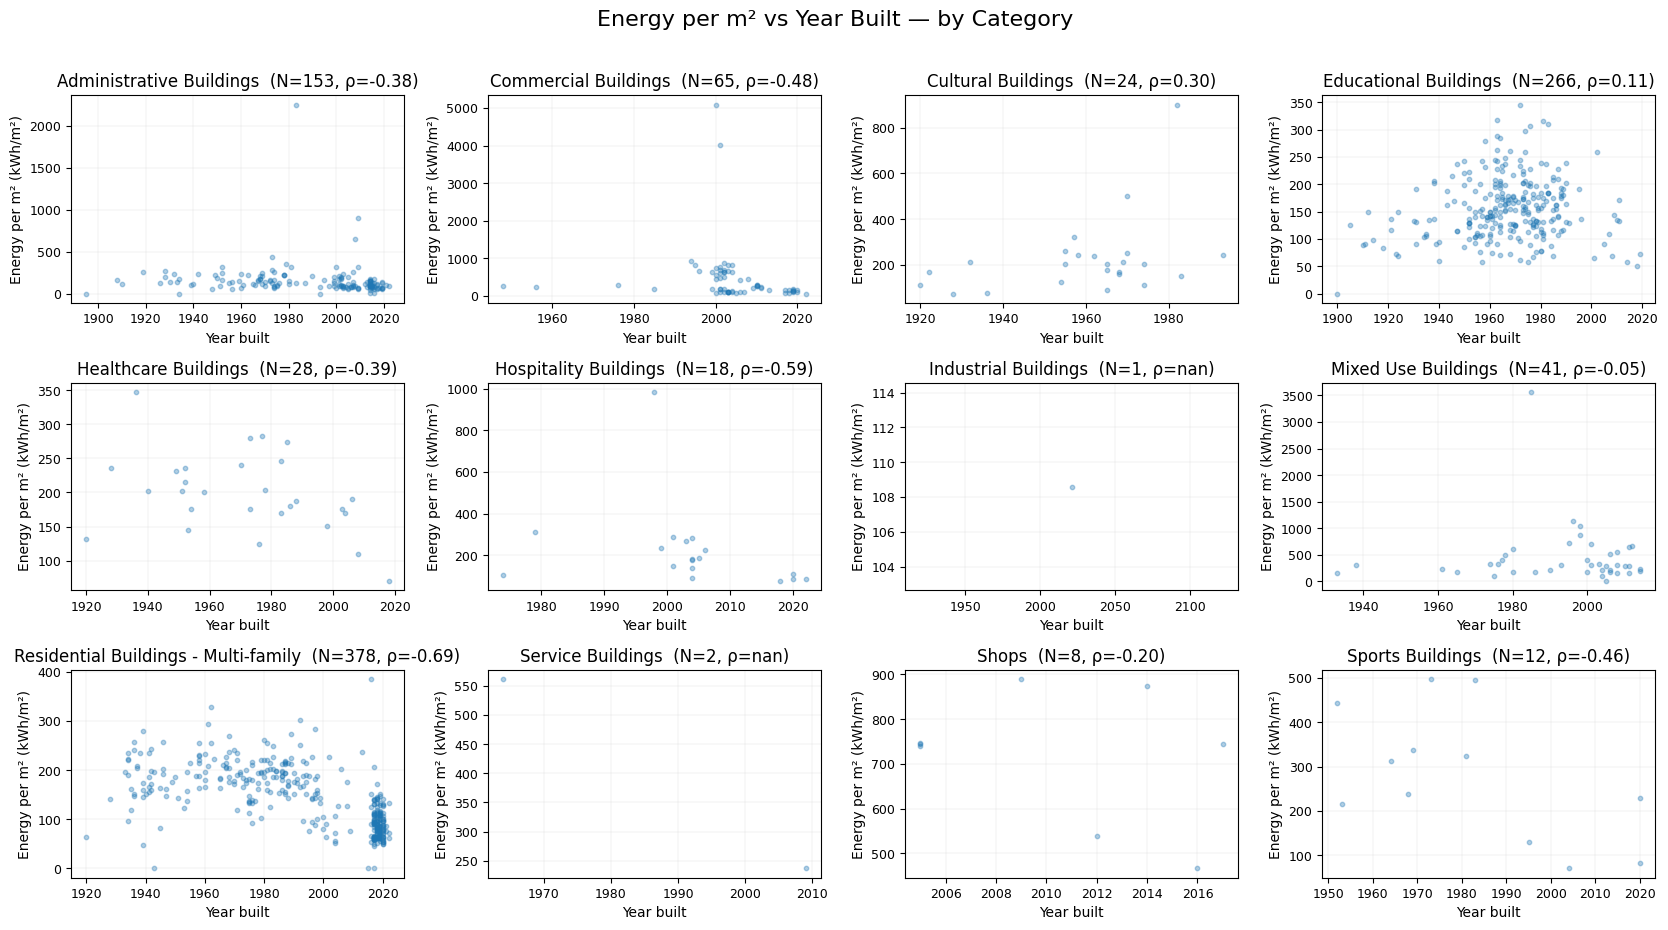

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import ceil

df = pd.DataFrame(overlapping_gdf_dataset).drop(columns=["geometry"], errors="ignore")

def coalesce(df, cols):
    s = pd.Series(np.nan, index=df.index, dtype="float64")
    for c in cols:
        if c in df.columns:
            s = s.fillna(pd.to_numeric(df[c], errors="coerce"))
    return s

# Y and X
target = coalesce(df, ["en2025_enegy_demand_present_m2", "en2023_enegy_demand_present_m2"])
year   = coalesce(df, ["en2025_yearbuilt", "en2023_yearbuilt"])

# Category column
cat = (df["d_Category"] if "d_Category" in df.columns
       else (df["en2025_type"] if "en2025_type" in df.columns else df["en2023_type"]))

data = pd.DataFrame({"target": target, "year": year, "cat": cat}).dropna()
data = data[(data["year"]>1800) & (data["year"]<2035)]

def spearman_safe(x, y):
    xr = pd.Series(x).rank(); yr = pd.Series(y).rank()
    m = xr.notna() & yr.notna()
    return np.corrcoef(xr[m], yr[m])[0,1] if m.sum()>=5 else np.nan

plt.rcParams.update({"font.size":10,"axes.titlesize":12,"axes.labelsize":10,
                     "xtick.labelsize":9,"ytick.labelsize":9,"figure.titlesize":16})

cats = sorted(data["cat"].astype(str).unique())
per_page = 12
pages = ceil(len(cats)/per_page)

for p in range(pages):
    chunk = cats[p*per_page:(p+1)*per_page]
    n = len(chunk)
    cols = 4 if n >= 4 else n
    rows = ceil(n/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4.2*cols, 3.2*rows), squeeze=False)
    axes = axes.ravel()
    for i, c in enumerate(chunk):
        ax = axes[i]
        sub = data[data["cat"].astype(str)==c]
        yj = sub["target"] + np.random.normal(0, 0.6, size=len(sub))  # reduce banding
        ax.scatter(sub["year"], yj, s=10, alpha=0.35)
        r = spearman_safe(sub["year"], sub["target"])
        ax.set_title(f"{c}  (N={len(sub)}, ρ={r:.2f})")
        ax.set_xlabel("Year built"); ax.set_ylabel("Energy per m² (kWh/m²)")
        ax.grid(True, linewidth=0.3, alpha=0.4)
    for j in range(i+1, len(axes)): fig.delaxes(axes[j])
    fig.suptitle("Energy per m² vs Year Built — by Category", y=0.964)
    fig.tight_layout(rect=[0,0,1,0.95])
    fig.savefig(f"scatter_by_category_page_{p+1}.png", dpi=160)
    plt.show()


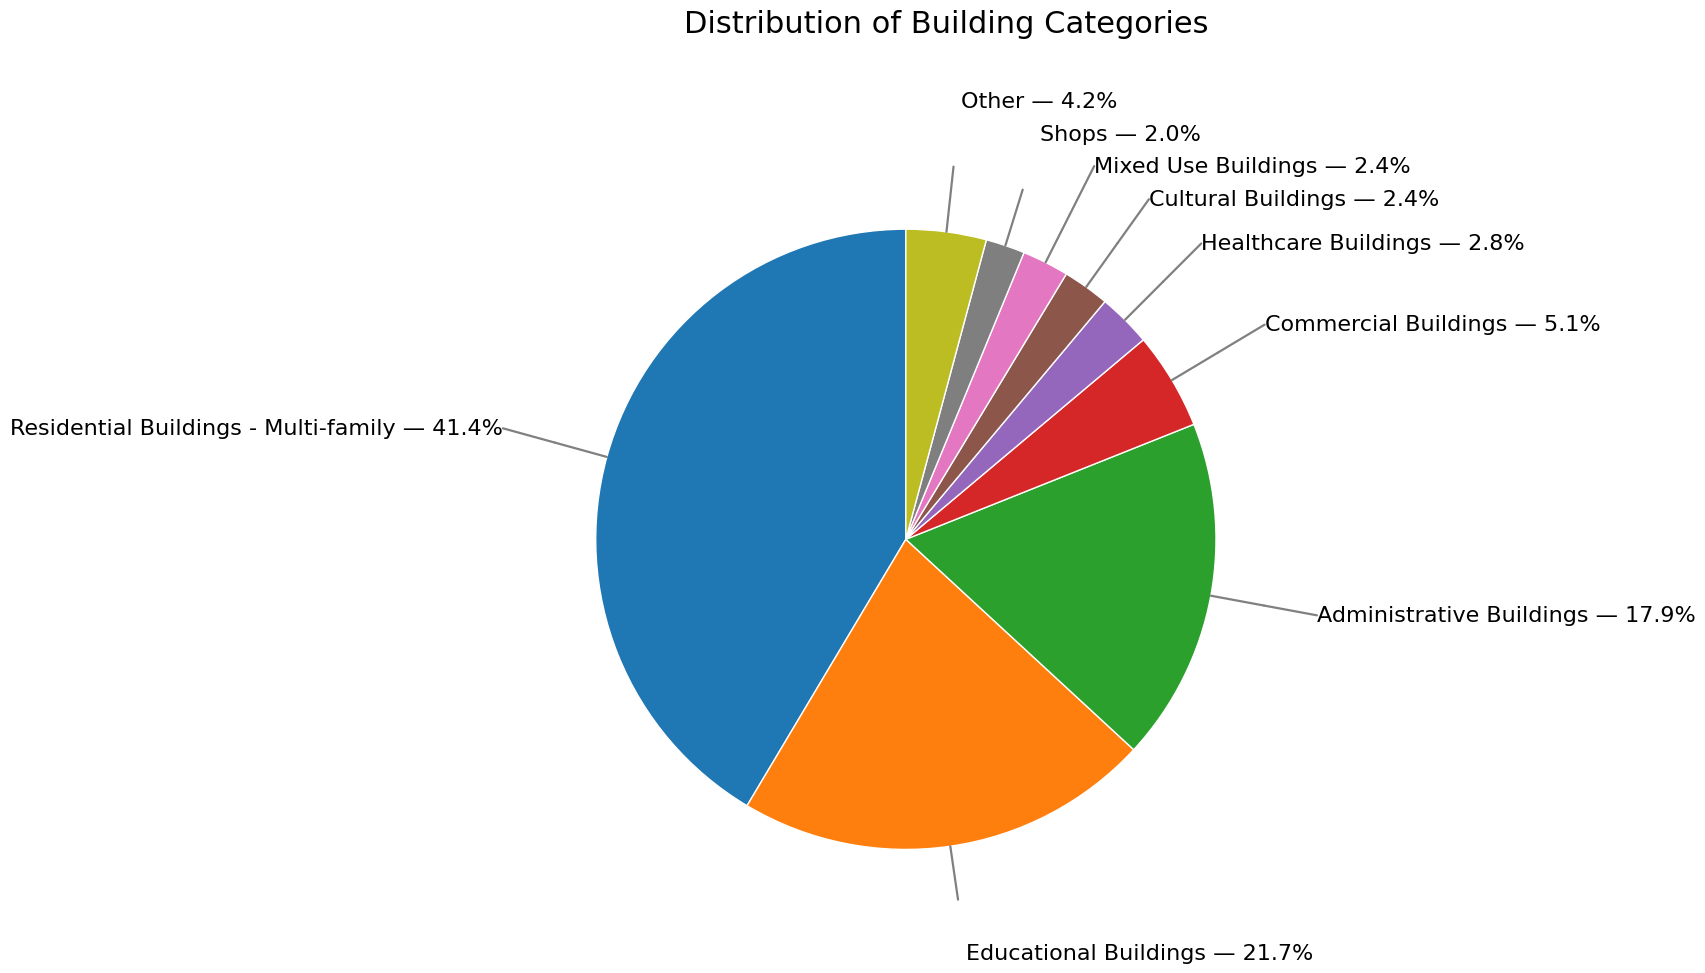

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch

# ==== knobs you can tweak ====
FIGSIZE = (18, 10)   # bigger canvas
RADIUS  = 1.15       # pie radius ( >1 makes slices bigger )
R_LABEL = 1.55       # how far outside labels sit
MIN_SEP = 0.12       # vertical separation between labels on each side
LABEL_FONT_SIZE = 16 # label size
LINEWIDTH = 1.6      # leader line thickness
# ============================

df = pd.DataFrame(overlapping_gdf_dataset).drop(columns=["geometry"], errors="ignore")
CAT_COL = "d_Category" if "d_Category" in df.columns else (
    "en2025_type" if "en2025_type" in df.columns else "en2023_type"
)
TOP_K = 8

counts = df[CAT_COL].astype(str).value_counts()
top = counts.head(TOP_K)
other = counts.iloc[TOP_K:].sum()
labels = top.index.tolist() + (["Other"] if other > 0 else [])
sizes  = top.values.tolist() + ([other] if other > 0 else [])
total = float(np.sum(sizes))

plt.rcParams.update({"font.size": LABEL_FONT_SIZE, "font.weight": "regular", "axes.titleweight": "regular"})
fig, ax = plt.subplots(figsize=FIGSIZE)

# draw a larger pie via radius argument
wedges, _ = ax.pie(
    sizes, startangle=90, labels=None, autopct=None, radius=RADIUS,
    wedgeprops=dict(linewidth=1, edgecolor="white")
)

# mid-angle of each slice -> anchor on slice edge (radius=RADIUS)
mid_angles = np.deg2rad([(w.theta1 + w.theta2) / 2.0 for w in wedges])
x_anchor = RADIUS * np.cos(mid_angles)
y_anchor = RADIUS * np.sin(mid_angles)

# place labels further out
pos = np.column_stack([R_LABEL*np.cos(mid_angles), R_LABEL*np.sin(mid_angles)])

# de-overlap left & right independently
def deoverlap(points, side="+", min_sep=MIN_SEP):
    idx = np.where(points[:,0] >= 0)[0] if side=="+" else np.where(points[:,0] < 0)[0]
    if len(idx) <= 1: return points
    order = idx[np.argsort(points[idx,1])]
    for i in range(1, len(order)):
        cur, prev = order[i], order[i-1]
        if points[cur,1] - points[prev,1] < min_sep:
            points[cur,1] = points[prev,1] + min_sep
    return points

pos = deoverlap(pos, "+", MIN_SEP)
pos = deoverlap(pos, "-", MIN_SEP)

# give labels extra margin around the pie
ax.set_xlim(-R_LABEL-0.3, R_LABEL+0.6)
ax.set_ylim(-R_LABEL+0.1,  R_LABEL-0.1)

# draw labels (percent only, full names) + two-segment leaders
for (label, count, xa, ya, (xt, yt)) in zip(labels, sizes, x_anchor, y_anchor, pos):
    pct_text = f"{label} — {100*count/total:.1f}%"
    ha = "left" if xt >= 0 else "right"
    ax.text(xt, yt, pct_text, ha=ha, va="center", fontsize=LABEL_FONT_SIZE)

    # elbowed leader line from slice edge to label
    elbow_x, elbow_y = (xt + xa)/2.0, (yt + ya)/2.0
    for (x0, y0), (x1, y1) in [((xa, ya), (elbow_x, elbow_y)), ((elbow_x, elbow_y), (xt, yt))]:
        ax.add_artist(ConnectionPatch(
            xyA=(x0, y0), xyB=(x1, y1),
            coordsA="data", coordsB="data",
            axesA=ax, axesB=ax, color="gray", lw=LINEWIDTH))

ax.set_title("Distribution of Building Categories", pad=16, weight="regular", fontsize=22, y=1.12)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("pie_categories_bigger_slices_labels_spaced.png", dpi=220)
plt.show()


# Task
Perform K-fold cross-validation for Random Forest, XGBoost, MLP, and LSTM models across Baseline, Enhanced, and Enhanced_2 feature sets. For each model and feature set combination, average performance metrics (MAE, R²) across folds and extract/average feature importance for tree-based models (Random Forest, XGBoost). This will include implementing a new K-fold cross-validation function and integrating feature importance extraction within it.

## Implement K-Fold Cross-Validation for Models

### Subtask:
Develop a new function that performs K-fold cross-validation for a given model (Random Forest, XGBoost, MLP, LSTM) and a specific set of features.


**Reasoning**:
The subtask requires defining a new function `kfold_evaluate_model` that performs K-fold cross-validation. This function relies on several existing helper functions (`convert_european_numbers`, `prepare_target_data`, `get_decade_from_year`, `calculate_decade_averages_from_data`, `create_correlation_dictionaries`, `get_decade_correlation_ed`, `get_decade_correlation_pe`, `create_baseline_features`, `create_enhanced_features`, `create_enhanced_2_features`, `preprocess_features`, `build_lstm_model`, `prepare_lstm_data`, `train_lstm_model`, `evaluate_model_performance`). I will consolidate all these functions into a single code block to ensure all dependencies are met and prevent `NameError` issues. I will also adjust the print statements in helper functions to be less verbose during the K-fold loop and ensure proper handling of data leakage (recalculating correlations/averages for each fold's training data) and consistent preprocessing (scaling, encoding, column alignment). The `hyperparameter_tuning_model_comparison` function will no longer be called.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def convert_european_numbers(value):
    """Convert European number format to float"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.replace(',', '.'))
        except:
            return np.nan
    return np.nan

def prepare_target_data(df, target_column='en2025_enegy_demand_present_m2'):
    """Prepare target with outlier handling"""
    target = df[target_column].apply(convert_european_numbers)

    Q1, Q3 = target.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 2.0 * IQR
    upper_bound = Q3 + 2.0 * IQR

    valid_idx = (target.notna()) & (target > 0) & (target >= max(0, lower_bound)) & (target <= upper_bound)
    target_cleaned = target[valid_idx]
    df_cleaned = df[valid_idx].copy()

    skewness = stats.skew(target_cleaned)
    use_log_target = abs(skewness) > 1

    if use_log_target:
        target_transformed = np.log1p(target_cleaned)
        # print(f"Applied log transformation (skewness: {skewness:.2f})")
    else:
        target_transformed = target_cleaned.copy()
        # print(f"No transformation needed (skewness: {skewness:.2f})")

    return df_cleaned, target_cleaned, target_transformed, use_log_target

def get_decade_from_year(year):
    """Convert year to decade"""
    if pd.isna(year) or year == 0:
        return 1990
    return int(year // 10) * 10

def calculate_decade_averages_from_data(df_input, target_column='en2025_enegy_demand_present_m2', min_buildings_per_decade=2):
    """Calculate decade averages from data"""
    df_clean = df_input.copy()

    df_clean['energy_target'] = df_clean[target_column].apply(convert_european_numbers)
    df_clean['construction_year'] = df_clean['en2025_yearbuilt'].apply(convert_european_numbers)

    valid_data = df_clean[
        (df_clean['energy_target'].notna()) &
        (df_clean['energy_target'] > 0) &
        (df_clean['construction_year'].notna()) &
        (df_clean['construction_year'] > 1900) &
        (df_clean['d_Category'].notna())
    ].copy()

    # print(f"Using {len(valid_data)} buildings with valid energy and year data")

    valid_data['construction_decade'] = valid_data['construction_year'].apply(get_decade_from_year)

    decade_averages = valid_data.groupby(['d_Category', 'construction_decade'])['energy_target'].agg(['mean', 'count']).reset_index()

    decade_avg_energy_from_data = {}

    for _, row in decade_averages.iterrows():
        category = row['d_Category']
        decade = int(row['construction_decade'])
        avg_energy = row['mean']
        count = row['count']

        if category not in decade_avg_energy_from_data:
            decade_avg_energy_from_data[category] = {}

        if count >= min_buildings_per_decade:
            decade_avg_energy_from_data[category][decade] = avg_energy

    return decade_avg_energy_from_data

def create_correlation_dictionaries(df_input):
    """Create correlation dictionaries"""
    energy_columns = {
        'ED': 'en2025_enegy_demand_present_m2',
        'PE': 'en2025_enegy_demand_after_m2'
    }
    type_col = 'd_Category'
    year_col = 'en2025_yearbuilt'
    results = {}

    for energy_type, energy_col in energy_columns.items():
        # print(f"Processing {energy_type} correlations")

        df_filtered = df_input[[type_col, year_col, energy_col]].copy()
        df_filtered[year_col] = df_filtered[year_col].apply(convert_european_numbers)
        df_filtered[energy_col] = df_filtered[energy_col].apply(convert_european_numbers)
        df_filtered = df_filtered.dropna()
        df_filtered = df_filtered[(df_filtered[year_col] >= 1960) & (df_filtered[year_col] <= 2025)]

        df_filtered['Decade'] = (df_filtered[year_col] // 10) * 10

        building_types = df_filtered[type_col].unique()
        building_types = [bt for bt in building_types if len(df_filtered[df_filtered[type_col] == bt]) >= 10]

        correlations = {}

        for building_type in building_types:
            type_data = df_filtered[df_filtered[type_col] == building_type]
            decades = sorted(type_data['Decade'].unique())

            correlations[building_type] = {}

            for decade in decades:
                decade_data = type_data[type_data['Decade'] == decade]

                if len(decade_data) >= 5:
                    decade_data_copy = decade_data.copy()
                    decade_data_copy['Age'] = decade + 5 - decade_data_copy[year_col]

                    corr = decade_data_copy['Age'].corr(decade_data_copy[energy_col])
                    if not pd.isna(corr):
                        correlations[building_type][int(decade)] = round(corr, 2)

        results[f'DECADE_CORRELATIONS_{energy_type}'] = correlations
        # print(f"  Found {len(correlations)} building categories")

    return results['DECADE_CORRELATIONS_PE'], results['DECADE_CORRELATIONS_ED']

def get_decade_correlation_ed(category, decade, DECADE_CORRELATIONS_ED_DICT):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_ED_DICT:
        decade_data = DECADE_CORRELATIONS_ED_DICT[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def get_decade_correlation_pe(category, decade, DECADE_CORRELATIONS_PE_DICT):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_PE_DICT:
        decade_data = DECADE_CORRELATIONS_PE_DICT[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def create_baseline_features(df_input):
    """Create simple baseline features"""
    features = pd.DataFrame()

    features['area_heated'] = df_input['en2025_area_heated_m2'].apply(convert_european_numbers).fillna(0)
    features['area_total'] = df_input['en2025_gfa_m2'].apply(convert_european_numbers).fillna(0)
    features['volume_heated'] = df_input['en2025_vol_heated_m3'].apply(convert_european_numbers).fillna(0)
    features['construction_year'] = df_input['en2025_yearbuilt'].apply(convert_european_numbers).fillna(1990)

    return features

def create_enhanced_features(df_input, target_column='en2025_enegy_demand_present_m2',
                             DECADE_CORRELATIONS_PE=None, DECADE_CORRELATIONS_ED=None,
                             decade_avg_energy_from_data=None):
    """Create enhanced features"""
    # If decade averages are not provided, calculate them (e.g., for initial training data setup)
    if decade_avg_energy_from_data is None:
        decade_avg_energy_from_data = calculate_decade_averages_from_data(df_input, target_column, 2)

    features = pd.DataFrame()

    area_cols = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3']
    feature_names = ['area_heated', 'area_total', 'volume_heated']

    for i, col in enumerate(feature_names):
        values = df_input[area_cols[i]].apply(convert_european_numbers)
        Q1, Q3 = values.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        features[col] = values.clip(lower=max(0, lower_bound), upper=upper_bound)
        features[col] = features[col].fillna(features[col].median())
        # print(f"  {col}: outliers capped")

    features['construction_year'] = df_input['en2025_yearbuilt'].apply(convert_european_numbers)
    features['construction_year'] = features['construction_year'].fillna(features['construction_year'].median())

    if 'd_Correlation_Energy_Demand' in df_input.columns:
        features['Correlation_ED'] = df_input['d_Correlation_Energy_Demand'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_ED'] = 0

    if 'd_Correlation_Primary_Energy' in df_input.columns:
        features['Correlation_PM'] = df_input['d_Correlation_Primary_Energy'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_PM'] = 0

    if 'd_Energy_Completeness_Pct' in df_input.columns:
        features['Energy_Completeness_Pct'] = df_input['d_Energy_Completeness_Pct'].apply(convert_european_numbers).fillna(0)
    else:
        features['Energy_Completeness_Pct'] = 0

    features['building_category'] = df_input['d_Category'].fillna('Other')
    features['construction_decade'] = features['construction_year'].apply(get_decade_from_year)

    features['decade_correlation_pe'] = features.apply(lambda row: get_decade_correlation_pe(row['building_category'], row['construction_decade'], DECADE_CORRELATIONS_PE), axis=1)
    features['decade_correlation_ed'] = features.apply(lambda row: get_decade_correlation_ed(row['building_category'], row['construction_decade'], DECADE_CORRELATIONS_ED), axis=1)

    features['building_age'] = 2025 - features['construction_year']
    features['log_building_age'] = np.log1p(features['building_age'])

    features['heating_efficiency_ratio'] = features['area_heated'] / (features['area_total'] + 1)
    features['area_to_volume_ratio'] = features['area_heated'] / (features['volume_heated'] + 1)

    numeric_cols = features.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        features[col] = features[col].replace([np.inf, -np.inf], np.nan)
        features[col] = features[col].fillna(features[col].median())

    return features

def create_enhanced_2_features(df_input, target_column='en2025_enegy_demand_present_m2',
                               DECADE_CORRELATIONS_PE=None, DECADE_CORRELATIONS_ED=None,
                               decade_avg_energy_from_data=None):
    """Create Enhanced 2 features (Enhanced + construction_type + nbuildingy)"""
    features = create_enhanced_features(df_input, target_column, DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED, decade_avg_energy_from_data)

    if 'construction_type' in df_input.columns:
        features['construction_type'] = df_input['construction_type'].fillna('Unknown')
    else:
        features['construction_type'] = 'Unknown'

    if 'nbuildingy' in df_input.columns:
        features['nbuildingy'] = df_input['nbuildingy'].apply(convert_european_numbers).fillna(features['construction_year'].median())
    else:
        features['nbuildingy'] = features['construction_year']

    bldg_shape_cols = [col for col in df_input.columns if '_bldg_shape' in col]

    if len(bldg_shape_cols) > 0:
        if len(bldg_shape_cols) == 1:
            features['bldg_shape'] = df_input[bldg_shape_cols[0]].fillna('Unknown')
        else:
            features['bldg_shape'] = df_input[bldg_shape_cols[0]].fillna('Unknown')
    else:
        features['bldg_shape'] = 'Unknown'

    # print(f"Enhanced 2 features: {features.shape[1]} total features")
    return features

def preprocess_features(X, label_encoders=None, scaler=None, is_training=True):
    """
    Preprocesses features by handling categorical encoding and numerical scaling.
    Can fit new encoders/scalers or use provided ones for consistency.
    """
    X_processed = X.copy()

    if label_encoders is None and is_training:
        label_encoders = {}

    # Handle categorical (object) columns
    for col in X_processed.select_dtypes(include=['object']).columns:
        if is_training:
            le = LabelEncoder()
            X_processed[col] = le.fit_transform(X_processed[col].astype(str))
            label_encoders[col] = le
            # print(f"Encoded {col}: {len(label_encoders[col].classes_)} unique values")
        else:
            if col in label_encoders:
                le = label_encoders[col]
                def safe_transform(x):
                    x_str = str(x)
                    if x_str not in le.classes_:
                        # Map unseen to a placeholder (e.g., the first class or a consistent value)
                        # Using -1 to indicate unseen, but models need numeric values. Best to map to a known class.
                        # Using 0 (encoded value for the first class) as a safe fallback.
                        return le.transform([le.classes_[0]])[0]
                    return le.transform([x_str])[0]
                X_processed[col] = X_processed[col].apply(safe_transform)
            else:
                # If col not seen in training, treat as 'Unknown' and encode as such if 'Unknown' was a training class
                # Or create a new encoder for it if it's genuinely new and not handled by training. For consistency, fill with 0 (first class).
                # print(f"Warning: Column '{col}' not seen during training. Filling with 0.")
                X_processed[col] = 0 # Fallback for completely new categorical column

    # Fill any remaining NaN values in numeric columns before scaling
    numeric_cols = X_processed.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        X_processed[col] = X_processed[col].replace([np.inf, -np.inf], np.nan)
        if X_processed[col].isnull().any():
            median_val = X_processed[col].median()
            if pd.isna(median_val):
                X_processed[col] = X_processed[col].fillna(0) # Fallback if all values are NaN
            else:
                X_processed[col] = X_processed[col].fillna(median_val)

    # Scale numerical features
    if is_training:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_processed)
        # print("Fitted and transformed new StandardScaler.")
    else:
        if scaler is None or not hasattr(scaler, 'mean_'):
            raise ValueError("Scaler must be fitted during training and provided for transformation.")
        X_scaled = scaler.transform(X_processed)
        # print("Transformed with provided StandardScaler.")

    X_processed_scaled = pd.DataFrame(X_scaled, columns=X_processed.columns, index=X_processed.index)

    return X_processed_scaled, label_encoders, scaler

def build_lstm_model(sequence_shape, lstm_units=50, dropout_rate=0.2):
    """Build LSTM model"""
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=sequence_shape, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        LSTM(lstm_units // 2, return_sequences=False, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate / 2),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    # print("LSTM model architecture:")
    # model.summary()

    return model

def prepare_lstm_data(X_scaled_input, y, sequence_length=5):
    """Prepare LSTM data from already scaled input, and generate sequences."""
    sequences = []
    targets = []

    if len(X_scaled_input) < sequence_length:
        return np.array([]), np.array([]), None

    for i in range(sequence_length, len(X_scaled_input) + 1):
        sequences.append(X_scaled_input.iloc[i-sequence_length:i].values)
        targets.append(y.iloc[i-1])

    sequences = np.array(sequences)
    targets = np.array(targets)

    return sequences, targets, None

def train_lstm_model(X_train, X_test, y_train, y_test, lstm_units=50, dropout_rate=0.3, epochs=100, verbose=0):
    """Train LSTM model"""
    model = build_lstm_model(sequence_shape=(X_train.shape[1], X_train.shape[2]),
                           lstm_units=lstm_units, dropout_rate=dropout_rate)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
    ]

    if len(X_train) == 0 or len(X_test) == 0:
        print("Warning: Empty training or test set for LSTM. Skipping training.")
        return None, np.array([]), None

    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs,
                       batch_size=32, callbacks=callbacks, verbose=verbose)

    y_pred = model.predict(X_test, verbose=0).flatten()

    # epochs_trained = len(history.history['loss'])
    # print(f"   Epochs trained: {epochs_trained}")

    return model, y_pred, history

def evaluate_model_performance(y_true, y_pred, model_name, use_log_target=False):
    """Evaluate model performance"""
    if len(y_true) == 0 or len(y_pred) == 0:
        return {'mae': np.nan, 'r2': np.nan}

    if use_log_target:
        y_true_original = np.expm1(y_true)
        y_pred_original = np.expm1(y_pred)
    else:
        y_true_original = y_true
        y_pred_original = y_pred

    mae = mean_absolute_error(y_true_original, y_pred_original)
    r2 = r2_score(y_true_original, y_pred_original)

    # print(f"{model_name} Results:")
    # print(f"MAE: {mae:.2f} kWh/m²")
    # print(f" R²: {r2:.3f}")

    return {'mae': mae, 'r2': r2}


def kfold_evaluate_model(df, target_column='en2025_enegy_demand_present_m2', n_splits=5):
    print(f"=== Starting K-Fold Cross-Validation ({n_splits} folds) ===")

    all_results = []
    feature_importances_rf = {fs: [] for fs in ['Baseline', 'Enhanced', 'Enhanced_2']}
    feature_importances_xgb = {fs: [] for fs in ['Baseline', 'Enhanced', 'Enhanced_2']}

    df_clean_full, target_cleaned_full, target_transformed_full, use_log_target = prepare_target_data(df, target_column)
    print(f"Total clean data points: {len(df_clean_full)}")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_idx = 0

    for train_index, val_index in kf.split(df_clean_full):
        fold_idx += 1
        print(f"\n--- Processing Fold {fold_idx}/{n_splits} ---")

        df_train_fold = df_clean_full.iloc[train_index].copy()
        df_val_fold = df_clean_full.iloc[val_index].copy()
        y_train_fold_transformed = target_transformed_full.iloc[train_index].copy()
        y_val_fold_transformed = target_transformed_full.iloc[val_index].copy()

        # Recalculate correlations/averages for the current fold's training data to prevent data leakage
        fold_decade_correlations_pe, fold_decade_correlations_ed = create_correlation_dictionaries(df_train_fold)
        fold_decade_avg_energy_from_data = calculate_decade_averages_from_data(df_train_fold, target_column, 2)

        feature_sets = {
            'Baseline': lambda d: create_baseline_features(d),
            'Enhanced': lambda d: create_enhanced_features(d, target_column, fold_decade_correlations_pe, fold_decade_correlations_ed, fold_decade_avg_energy_from_data),
            'Enhanced_2': lambda d: create_enhanced_2_features(d, target_column, fold_decade_correlations_pe, fold_decade_correlations_ed, fold_decade_avg_energy_from_data)
        }

        # Store preprocessed features and corresponding params for each feature set within the fold
        fold_datasets = {}

        for fs_name, fs_func in feature_sets.items():
            # print(f"  Generating raw features for {fs_name}...")
            X_train_raw = fs_func(df_train_fold)
            X_val_raw = fs_func(df_val_fold)

            # print(f"  Preprocessing features for {fs_name}...")
            # Preprocess training data: fit encoders/scaler
            X_train_processed, le_dict, scaler_obj = preprocess_features(X_train_raw, label_encoders=None, scaler=None, is_training=True)
            # Preprocess validation data: transform using fitted encoders/scaler
            X_val_processed, _, _ = preprocess_features(X_val_raw, label_encoders=le_dict, scaler=scaler_obj, is_training=False)

            # Ensure columns are consistent between train and val processed sets
            train_cols = set(X_train_processed.columns)
            val_cols = set(X_val_processed.columns)

            missing_in_val = list(train_cols - val_cols)
            for col in missing_in_val:
                X_val_processed[col] = 0.0 # Fill missing with 0 for consistency

            extra_in_val = list(val_cols - train_cols)
            if extra_in_val:
                X_val_processed = X_val_processed.drop(columns=extra_in_val)

            # Reorder columns to match training set
            X_val_processed = X_val_processed[X_train_processed.columns]

            fold_datasets[fs_name] = {
                'X_train_raw_features': X_train_raw, # Keep raw for LSTM initial processing if needed
                'X_train': X_train_processed,
                'X_val': X_val_processed,
                'le_dict': le_dict,
                'scaler_obj': scaler_obj
            }

            print(f"  {fs_name} - Train processed shape: {X_train_processed.shape}, Val processed shape: {X_val_processed.shape}")

        # Model evaluation within the fold
        for fs_name in feature_sets.keys():
            data = fold_datasets[fs_name]
            X_train_data = data['X_train']
            X_val_data = data['X_val']

            # 1. Random Forest
            print(f"  Fold {fold_idx} - RF with {fs_name} features...")
            rf_params = {
                'n_estimators': [100, 200],
                'max_depth': [10, 20],
                'min_samples_split': [2, 5]
            }
            rf_grid = RandomizedSearchCV(
                RandomForestRegressor(random_state=42, n_jobs=-1),
                rf_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )
            rf_grid.fit(X_train_data, y_train_fold_transformed)
            rf_pred = rf_grid.predict(X_val_data)
            rf_metrics = evaluate_model_performance(y_val_fold_transformed, rf_pred, f"RF_{fs_name} (Fold {fold_idx})", use_log_target)
            all_results.append({'Model': 'RF', 'Features': fs_name, 'Fold': fold_idx, **rf_metrics})
            feature_importances_rf[fs_name].append(pd.Series(rf_grid.best_estimator_.feature_importances_, index=X_train_data.columns))

            # 2. XGBoost
            print(f"  Fold {fold_idx} - XGB with {fs_name} features...")
            xgb_params = {
                'n_estimators': [100, 200],
                'max_depth': [3, 5],
                'learning_rate': [0.05, 0.1]
            }
            xgb_grid = RandomizedSearchCV(
                xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
                xgb_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )
            xgb_grid.fit(X_train_data, y_train_fold_transformed)
            xgb_pred = xgb_grid.predict(X_val_data)
            xgb_metrics = evaluate_model_performance(y_val_fold_transformed, xgb_pred, f"XGB_{fs_name} (Fold {fold_idx})", use_log_target)
            all_results.append({'Model': 'XGB', 'Features': fs_name, 'Fold': fold_idx, **xgb_metrics})
            feature_importances_xgb[fs_name].append(pd.Series(xgb_grid.best_estimator_.feature_importances_, index=X_train_data.columns))

            # 3. MLP
            print(f"  Fold {fold_idx} - MLP with {fs_name} features...")
            mlp_params = {
                'hidden_layer_sizes': [(50,)],
                'alpha': [0.1, 0.5],
                'learning_rate_init': [0.001, 0.01]
            }
            mlp_grid = RandomizedSearchCV(
                MLPRegressor(max_iter=100, random_state=42, early_stopping=True, validation_fraction=0.2),
                mlp_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )
            mlp_grid.fit(X_train_data, y_train_fold_transformed)
            mlp_pred = mlp_grid.predict(X_val_data)
            mlp_metrics = evaluate_model_performance(y_val_fold_transformed, mlp_pred, f"MLP_{fs_name} (Fold {fold_idx})", use_log_target)
            all_results.append({'Model': 'MLP', 'Features': fs_name, 'Fold': fold_idx, **mlp_metrics})

            # 4. LSTM
            print(f"  Fold {fold_idx} - LSTM with {fs_name} features...")
            # LSTM uses the already scaled and processed data from preprocess_features
            X_train_seq, y_train_seq, _ = prepare_lstm_data(X_train_data, y_train_fold_transformed, sequence_length=5)
            X_val_seq, y_val_seq, _ = prepare_lstm_data(X_val_data, y_val_fold_transformed, sequence_length=5)

            if len(X_train_seq) > 0 and len(X_val_seq) > 0:
                lstm_model, lstm_pred, _ = train_lstm_model(X_train_seq, X_val_seq, y_train_seq, y_val_seq,
                                                            lstm_units=50, dropout_rate=0.3, epochs=20, verbose=0)
                if lstm_model is not None:
                    lstm_metrics = evaluate_model_performance(y_val_seq, lstm_pred, f"LSTM_{fs_name} (Fold {fold_idx})", use_log_target)
                    all_results.append({'Model': 'LSTM', 'Features': fs_name, 'Fold': fold_idx, **lstm_metrics})
                else:
                    all_results.append({'Model': 'LSTM', 'Features': fs_name, 'Fold': fold_idx, 'mae': np.nan, 'r2': np.nan})

            else:
                print(f"   Skipping LSTM for {fs_name} in Fold {fold_idx} due to insufficient data for sequence creation.")
                all_results.append({'Model': 'LSTM', 'Features': fs_name, 'Fold': fold_idx, 'mae': np.nan, 'r2': np.nan})


    # Aggregate results across folds
    results_df = pd.DataFrame(all_results)
    avg_results = results_df.groupby(['Model', 'Features']).agg(
        avg_mae=('mae', 'mean'),
        std_mae=('mae', 'std'),
        avg_r2=('r2', 'mean'),
        std_r2=('r2', 'std')
    ).reset_index()

    # Aggregate feature importances
    avg_feature_importances_rf = {fs: pd.concat(fi_list, axis=1).mean(axis=1) for fs, fi_list in feature_importances_rf.items() if fi_list}
    avg_feature_importances_xgb = {fs: pd.concat(fi_list, axis=1).mean(axis=1) for fs, fi_list in feature_importances_xgb.items() if fi_list}

    print("\n" + "="*80)
    print("K-Fold Cross-Validation Summary (Average Metrics):")
    print("="*80)
    print(avg_results.sort_values(by='avg_r2', ascending=False))

    return avg_results, {'RF': avg_feature_importances_rf, 'XGB': avg_feature_importances_xgb}

# The existing hyperparameter_tuning_model_comparison function will not be called
def hyperparameter_tuning_model_comparison(df, target_column='en2025_enegy_demand_present_m2'):
    """Existing function for reference, but not used for evaluation in this subtask."""
    print("This function is deprecated for direct evaluation. Use kfold_evaluate_model instead.")
    return pd.DataFrame() # Return empty for compatibility if it somehow gets called


**Reasoning**:
The previous code block defined the refactored functions. Now, I will execute this cell to define these functions in the current environment. This ensures that the `kfold_evaluate_model` function and all its dependencies are available for use in the subsequent step.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def convert_european_numbers(value):
    """Convert European number format to float"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.replace(',', '.'))
        except:
            return np.nan
    return np.nan

def prepare_target_data(df, target_column='en2025_enegy_demand_present_m2'):
    """Prepare target with outlier handling"""
    target = df[target_column].apply(convert_european_numbers)

    Q1, Q3 = target.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 2.0 * IQR
    upper_bound = Q3 + 2.0 * IQR

    valid_idx = (target.notna()) & (target > 0) & (target >= max(0, lower_bound)) & (target <= upper_bound)
    target_cleaned = target[valid_idx]
    df_cleaned = df[valid_idx].copy()

    skewness = stats.skew(target_cleaned)
    use_log_target = abs(skewness) > 1

    if use_log_target:
        target_transformed = np.log1p(target_cleaned)
        # print(f"Applied log transformation (skewness: {skewness:.2f})")
    else:
        target_transformed = target_cleaned.copy()
        # print(f"No transformation needed (skewness: {skewness:.2f})")

    return df_cleaned, target_cleaned, target_transformed, use_log_target

def get_decade_from_year(year):
    """Convert year to decade"""
    if pd.isna(year) or year == 0:
        return 1990
    return int(year // 10) * 10

def calculate_decade_averages_from_data(df_input, target_column='en2025_enegy_demand_present_m2', min_buildings_per_decade=2):
    """Calculate decade averages from data"""
    df_clean = df_input.copy()

    df_clean['energy_target'] = df_clean[target_column].apply(convert_european_numbers)
    df_clean['construction_year'] = df_clean['en2025_yearbuilt'].apply(convert_european_numbers)

    valid_data = df_clean[
        (df_clean['energy_target'].notna()) &
        (df_clean['energy_target'] > 0) &
        (df_clean['construction_year'].notna()) &
        (df_clean['construction_year'] > 1900) &
        (df_clean['d_Category'].notna())
    ].copy()

    # print(f"Using {len(valid_data)} buildings with valid energy and year data")

    valid_data['construction_decade'] = valid_data['construction_year'].apply(get_decade_from_year)

    decade_averages = valid_data.groupby(['d_Category', 'construction_decade'])['energy_target'].agg(['mean', 'count']).reset_index()

    decade_avg_energy_from_data = {}

    for _, row in decade_averages.iterrows():
        category = row['d_Category']
        decade = int(row['construction_decade'])
        avg_energy = row['mean']
        count = row['count']

        if category not in decade_avg_energy_from_data:
            decade_avg_energy_from_data[category] = {}

        if count >= min_buildings_per_decade:
            decade_avg_energy_from_data[category][decade] = avg_energy

    return decade_avg_energy_from_data

def create_correlation_dictionaries(df_input):
    """Create correlation dictionaries"""
    energy_columns = {
        'ED': 'en2025_enegy_demand_present_m2',
        'PE': 'en2025_enegy_demand_after_m2'
    }
    type_col = 'd_Category'
    year_col = 'en2025_yearbuilt'
    results = {}

    for energy_type, energy_col in energy_columns.items():
        # print(f"Processing {energy_type} correlations")

        df_filtered = df_input[[type_col, year_col, energy_col]].copy()
        df_filtered[year_col] = df_filtered[year_col].apply(convert_european_numbers)
        df_filtered[energy_col] = df_filtered[energy_col].apply(convert_european_numbers)
        df_filtered = df_filtered.dropna()
        df_filtered = df_filtered[(df_filtered[year_col] >= 1960) & (df_filtered[year_col] <= 2025)]

        df_filtered['Decade'] = (df_filtered[year_col] // 10) * 10

        building_types = df_filtered[type_col].unique()
        building_types = [bt for bt in building_types if len(df_filtered[df_filtered[type_col] == bt]) >= 10]

        correlations = {}

        for building_type in building_types:
            type_data = df_filtered[df_filtered[type_col] == building_type]
            decades = sorted(type_data['Decade'].unique())

            correlations[building_type] = {}

            for decade in decades:
                decade_data = type_data[type_data['Decade'] == decade]

                if len(decade_data) >= 5:
                    decade_data_copy = decade_data.copy()
                    decade_data_copy['Age'] = decade + 5 - decade_data_copy[year_col]

                    corr = decade_data_copy['Age'].corr(decade_data_copy[energy_col])
                    if not pd.isna(corr):
                        correlations[building_type][int(decade)] = round(corr, 2)

        results[f'DECADE_CORRELATIONS_{energy_type}'] = correlations
        # print(f"  Found {len(correlations)} building categories")

    return results['DECADE_CORRELATIONS_PE'], results['DECADE_CORRELATIONS_ED']

def get_decade_correlation_ed(category, decade, DECADE_CORRELATIONS_ED_DICT):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_ED_DICT:
        decade_data = DECADE_CORRELATIONS_ED_DICT[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def get_decade_correlation_pe(category, decade, DECADE_CORRELATIONS_PE_DICT):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_PE_DICT:
        decade_data = DECADE_CORRELATIONS_PE_DICT[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def create_baseline_features(df_input):
    """Create simple baseline features"""
    features = pd.DataFrame()

    features['area_heated'] = df_input['en2025_area_heated_m2'].apply(convert_european_numbers).fillna(0)
    features['area_total'] = df_input['en2025_gfa_m2'].apply(convert_european_numbers).fillna(0)
    features['volume_heated'] = df_input['en2025_vol_heated_m3'].apply(convert_european_numbers).fillna(0)
    features['construction_year'] = df_input['en2025_yearbuilt'].apply(convert_european_numbers).fillna(1990)

    return features

def create_enhanced_features(df_input, target_column='en2025_enegy_demand_present_m2',
                             DECADE_CORRELATIONS_PE=None, DECADE_CORRELATIONS_ED=None,
                             decade_avg_energy_from_data=None):
    """Create enhanced features"""
    # If decade averages are not provided, calculate them (e.g., for initial training data setup)
    if decade_avg_energy_from_data is None:
        decade_avg_energy_from_data = calculate_decade_averages_from_data(df_input, target_column, 2)

    features = pd.DataFrame()

    area_cols = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3']
    feature_names = ['area_heated', 'area_total', 'volume_heated']

    for i, col in enumerate(feature_names):
        values = df_input[area_cols[i]].apply(convert_european_numbers)
        Q1, Q3 = values.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        features[col] = values.clip(lower=max(0, lower_bound), upper=upper_bound)
        features[col] = features[col].fillna(features[col].median())
        # print(f"  {col}: outliers capped")

    features['construction_year'] = df_input['en2025_yearbuilt'].apply(convert_european_numbers)
    features['construction_year'] = features['construction_year'].fillna(features['construction_year'].median())

    if 'd_Correlation_Energy_Demand' in df_input.columns:
        features['Correlation_ED'] = df_input['d_Correlation_Energy_Demand'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_ED'] = 0

    if 'd_Correlation_Primary_Energy' in df_input.columns:
        features['Correlation_PM'] = df_input['d_Correlation_Primary_Energy'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_PM'] = 0

    if 'd_Energy_Completeness_Pct' in df_input.columns:
        features['Energy_Completeness_Pct'] = df_input['d_Energy_Completeness_Pct'].apply(convert_european_numbers).fillna(0)
    else:
        features['Energy_Completeness_Pct'] = 0

    features['building_category'] = df_input['d_Category'].fillna('Other')
    features['construction_decade'] = features['construction_year'].apply(get_decade_from_year)

    features['decade_correlation_pe'] = features.apply(lambda row: get_decade_correlation_pe(row['building_category'], row['construction_decade'], DECADE_CORRELATIONS_PE), axis=1)
    features['decade_correlation_ed'] = features.apply(lambda row: get_decade_correlation_ed(row['building_category'], row['construction_decade'], DECADE_CORRELATIONS_ED), axis=1)

    features['building_age'] = 2025 - features['construction_year']
    features['log_building_age'] = np.log1p(features['building_age'])

    features['heating_efficiency_ratio'] = features['area_heated'] / (features['area_total'] + 1)
    features['area_to_volume_ratio'] = features['area_heated'] / (features['volume_heated'] + 1)

    numeric_cols = features.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        features[col] = features[col].replace([np.inf, -np.inf], np.nan)
        features[col] = features[col].fillna(features[col].median())

    return features

def create_enhanced_2_features(df_input, target_column='en2025_enegy_demand_present_m2',
                               DECADE_CORRELATIONS_PE=None, DECADE_CORRELATIONS_ED=None,
                               decade_avg_energy_from_data=None):
    """Create Enhanced 2 features (Enhanced + construction_type + nbuildingy)"""
    features = create_enhanced_features(df_input, target_column, DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED, decade_avg_energy_from_data)

    if 'construction_type' in df_input.columns:
        features['construction_type'] = df_input['construction_type'].fillna('Unknown')
    else:
        features['construction_type'] = 'Unknown'

    if 'nbuildingy' in df_input.columns:
        features['nbuildingy'] = df_input['nbuildingy'].apply(convert_european_numbers).fillna(features['construction_year'].median())
    else:
        features['nbuildingy'] = features['construction_year']

    bldg_shape_cols = [col for col in df_input.columns if '_bldg_shape' in col]

    if len(bldg_shape_cols) > 0:
        if len(bldg_shape_cols) == 1:
            features['bldg_shape'] = df_input[bldg_shape_cols[0]].fillna('Unknown')
        else:
            features['bldg_shape'] = df_input[bldg_shape_cols[0]].fillna('Unknown')
    else:
        features['bldg_shape'] = 'Unknown'

    # print(f"Enhanced 2 features: {features.shape[1]} total features")
    return features

def preprocess_features(X, label_encoders=None, scaler=None, is_training=True):
    """
    Preprocesses features by handling categorical encoding and numerical scaling.
    Can fit new encoders/scalers or use provided ones for consistency.
    """
    X_processed = X.copy()

    if label_encoders is None and is_training:
        label_encoders = {}

    # Handle categorical (object) columns
    for col in X_processed.select_dtypes(include=['object']).columns:
        if is_training:
            le = LabelEncoder()
            X_processed[col] = le.fit_transform(X_processed[col].astype(str))
            label_encoders[col] = le
            # print(f"Encoded {col}: {len(label_encoders[col].classes_)} unique values")
        else:
            if col in label_encoders:
                le = label_encoders[col]
                def safe_transform(x):
                    x_str = str(x)
                    if x_str not in le.classes_:
                        # Map unseen to a placeholder (e.g., the first class or a consistent value)
                        # Using -1 to indicate unseen, but models need numeric values. Best to map to a known class.
                        # Using 0 (encoded value for the first class) as a safe fallback.
                        return le.transform([le.classes_[0]])[0]
                    return le.transform([x_str])[0]
                X_processed[col] = X_processed[col].apply(safe_transform)
            else:
                # If col not seen in training, treat as 'Unknown' and encode as such if 'Unknown' was a training class
                # Or create a new encoder for it if it's genuinely new and not handled by training. For consistency, fill with 0 (first class).
                # print(f"Warning: Column '{col}' not seen during training. Filling with 0.")
                X_processed[col] = 0 # Fallback for completely new categorical column

    # Fill any remaining NaN values in numeric columns before scaling
    numeric_cols = X_processed.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        X_processed[col] = X_processed[col].replace([np.inf, -np.inf], np.nan)
        if X_processed[col].isnull().any():
            median_val = X_processed[col].median()
            if pd.isna(median_val):
                X_processed[col] = X_processed[col].fillna(0) # Fallback if all values are NaN
            else:
                X_processed[col] = X_processed[col].fillna(median_val)

    # Scale numerical features
    if is_training:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_processed)
        # print("Fitted and transformed new StandardScaler.")
    else:
        if scaler is None or not hasattr(scaler, 'mean_'):
            raise ValueError("Scaler must be fitted during training and provided for transformation.")
        X_scaled = scaler.transform(X_processed)
        # print("Transformed with provided StandardScaler.")

    X_processed_scaled = pd.DataFrame(X_scaled, columns=X_processed.columns, index=X_processed.index)

    return X_processed_scaled, label_encoders, scaler

def build_lstm_model(sequence_shape, lstm_units=50, dropout_rate=0.2):
    """Build LSTM model"""
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=sequence_shape, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        LSTM(lstm_units // 2, return_sequences=False, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate / 2),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    # print("LSTM model architecture:")
    # model.summary()

    return model

def prepare_lstm_data(X_scaled_input, y, sequence_length=5):
    """Prepare LSTM data from already scaled input, and generate sequences."""
    sequences = []
    targets = []

    if len(X_scaled_input) < sequence_length:
        return np.array([]), np.array([]), None

    for i in range(sequence_length, len(X_scaled_input) + 1):
        sequences.append(X_scaled_input.iloc[i-sequence_length:i].values)
        targets.append(y.iloc[i-1])

    sequences = np.array(sequences)
    targets = np.array(targets)

    return sequences, targets, None

def train_lstm_model(X_train, X_test, y_train, y_test, lstm_units=50, dropout_rate=0.3, epochs=100, verbose=0):
    """Train LSTM model"""
    model = build_lstm_model(sequence_shape=(X_train.shape[1], X_train.shape[2]),
                           lstm_units=lstm_units, dropout_rate=dropout_rate)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
    ]

    if len(X_train) == 0 or len(X_test) == 0:
        print("Warning: Empty training or test set for LSTM. Skipping training.")
        return None, np.array([]), None

    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs,
                       batch_size=32, callbacks=callbacks, verbose=verbose)

    y_pred = model.predict(X_test, verbose=0).flatten()

    # epochs_trained = len(history.history['loss'])
    # print(f"   Epochs trained: {epochs_trained}")

    return model, y_pred, history

def evaluate_model_performance(y_true, y_pred, model_name, use_log_target=False):
    """Evaluate model performance"""
    if len(y_true) == 0 or len(y_pred) == 0:
        return {'mae': np.nan, 'r2': np.nan}

    if use_log_target:
        y_true_original = np.expm1(y_true)
        y_pred_original = np.expm1(y_pred)
    else:
        y_true_original = y_true
        y_pred_original = y_pred

    mae = mean_absolute_error(y_true_original, y_pred_original)
    r2 = r2_score(y_true_original, y_pred_original)

    # print(f"{model_name} Results:")
    # print(f"MAE: {mae:.2f} kWh/m²")
    # print(f" R²: {r2:.3f}")

    return {'mae': mae, 'r2': r2}


def kfold_evaluate_model(df, target_column='en2025_enegy_demand_present_m2', n_splits=5):
    print(f"=== Starting K-Fold Cross-Validation ({n_splits} folds) ===")

    all_results = []
    feature_importances_rf = {fs: [] for fs in ['Baseline', 'Enhanced', 'Enhanced_2']}
    feature_importances_xgb = {fs: [] for fs in ['Baseline', 'Enhanced', 'Enhanced_2']}

    df_clean_full, target_cleaned_full, target_transformed_full, use_log_target = prepare_target_data(df, target_column)
    print(f"Total clean data points: {len(df_clean_full)}")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_idx = 0

    for train_index, val_index in kf.split(df_clean_full):
        fold_idx += 1
        print(f"\n--- Processing Fold {fold_idx}/{n_splits} ---")

        df_train_fold = df_clean_full.iloc[train_index].copy()
        df_val_fold = df_clean_full.iloc[val_index].copy()
        y_train_fold_transformed = target_transformed_full.iloc[train_index].copy()
        y_val_fold_transformed = target_transformed_full.iloc[val_index].copy()

        # Recalculate correlations/averages for the current fold's training data to prevent data leakage
        fold_decade_correlations_pe, fold_decade_correlations_ed = create_correlation_dictionaries(df_train_fold)
        fold_decade_avg_energy_from_data = calculate_decade_averages_from_data(df_train_fold, target_column, 2)

        feature_sets = {
            'Baseline': lambda d: create_baseline_features(d),
            'Enhanced': lambda d: create_enhanced_features(d, target_column, fold_decade_correlations_pe, fold_decade_correlations_ed, fold_decade_avg_energy_from_data),
            'Enhanced_2': lambda d: create_enhanced_2_features(d, target_column, fold_decade_correlations_pe, fold_decade_correlations_ed, fold_decade_avg_energy_from_data)
        }

        # Store preprocessed features and corresponding params for each feature set within the fold
        fold_datasets = {}

        for fs_name, fs_func in feature_sets.items():
            # print(f"  Generating raw features for {fs_name}...")
            X_train_raw = fs_func(df_train_fold)
            X_val_raw = fs_func(df_val_fold)

            # print(f"  Preprocessing features for {fs_name}...")
            # Preprocess training data: fit encoders/scaler
            X_train_processed, le_dict, scaler_obj = preprocess_features(X_train_raw, label_encoders=None, scaler=None, is_training=True)
            # Preprocess validation data: transform using fitted encoders/scaler
            X_val_processed, _, _ = preprocess_features(X_val_raw, label_encoders=le_dict, scaler=scaler_obj, is_training=False)

            # Ensure columns are consistent between train and val processed sets
            train_cols = set(X_train_processed.columns)
            val_cols = set(X_val_processed.columns)

            missing_in_val = list(train_cols - val_cols)
            for col in missing_in_val:
                X_val_processed[col] = 0.0 # Fill missing with 0 for consistency

            extra_in_val = list(val_cols - train_cols)
            if extra_in_val:
                X_val_processed = X_val_processed.drop(columns=extra_in_val)

            # Reorder columns to match training set
            X_val_processed = X_val_processed[X_train_processed.columns]

            fold_datasets[fs_name] = {
                'X_train_raw_features': X_train_raw, # Keep raw for LSTM initial processing if needed
                'X_train': X_train_processed,
                'X_val': X_val_processed,
                'le_dict': le_dict,
                'scaler_obj': scaler_obj
            }

            print(f"  {fs_name} - Train processed shape: {X_train_processed.shape}, Val processed shape: {X_val_processed.shape}")

        # Model evaluation within the fold
        for fs_name in feature_sets.keys():
            data = fold_datasets[fs_name]
            X_train_data = data['X_train']
            X_val_data = data['X_val']

            # 1. Random Forest
            print(f"  Fold {fold_idx} - RF with {fs_name} features...")
            rf_params = {
                'n_estimators': [100, 200],
                'max_depth': [10, 20],
                'min_samples_split': [2, 5]
            }
            rf_grid = RandomizedSearchCV(
                RandomForestRegressor(random_state=42, n_jobs=-1),
                rf_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )
            rf_grid.fit(X_train_data, y_train_fold_transformed)
            rf_pred = rf_grid.predict(X_val_data)
            rf_metrics = evaluate_model_performance(y_val_fold_transformed, rf_pred, f"RF_{fs_name} (Fold {fold_idx})", use_log_target)
            all_results.append({'Model': 'RF', 'Features': fs_name, 'Fold': fold_idx, **rf_metrics})
            feature_importances_rf[fs_name].append(pd.Series(rf_grid.best_estimator_.feature_importances_, index=X_train_data.columns))

            # 2. XGBoost
            print(f"  Fold {fold_idx} - XGB with {fs_name} features...")
            xgb_params = {
                'n_estimators': [100, 200],
                'max_depth': [3, 5],
                'learning_rate': [0.05, 0.1]
            }
            xgb_grid = RandomizedSearchCV(
                xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
                xgb_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )
            xgb_grid.fit(X_train_data, y_train_fold_transformed)
            xgb_pred = xgb_grid.predict(X_val_data)
            xgb_metrics = evaluate_model_performance(y_val_fold_transformed, xgb_pred, f"XGB_{fs_name} (Fold {fold_idx})", use_log_target)
            all_results.append({'Model': 'XGB', 'Features': fs_name, 'Fold': fold_idx, **xgb_metrics})
            feature_importances_xgb[fs_name].append(pd.Series(xgb_grid.best_estimator_.feature_importances_, index=X_train_data.columns))

            # 3. MLP
            print(f"  Fold {fold_idx} - MLP with {fs_name} features...")
            mlp_params = {
                'hidden_layer_sizes': [(50,)],
                'alpha': [0.1, 0.5],
                'learning_rate_init': [0.001, 0.01]
            }
            mlp_grid = RandomizedSearchCV(
                MLPRegressor(max_iter=100, random_state=42, early_stopping=True, validation_fraction=0.2),
                mlp_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )
            mlp_grid.fit(X_train_data, y_train_fold_transformed)
            mlp_pred = mlp_grid.predict(X_val_data)
            mlp_metrics = evaluate_model_performance(y_val_fold_transformed, mlp_pred, f"MLP_{fs_name} (Fold {fold_idx})", use_log_target)
            all_results.append({'Model': 'MLP', 'Features': fs_name, 'Fold': fold_idx, **mlp_metrics})

            # 4. LSTM
            print(f"  Fold {fold_idx} - LSTM with {fs_name} features...")
            # LSTM uses the already scaled and processed data from preprocess_features
            X_train_seq, y_train_seq, _ = prepare_lstm_data(X_train_data, y_train_fold_transformed, sequence_length=5)
            X_val_seq, y_val_seq, _ = prepare_lstm_data(X_val_data, y_val_fold_transformed, sequence_length=5)

            if len(X_train_seq) > 0 and len(X_val_seq) > 0:
                lstm_model, lstm_pred, _ = train_lstm_model(X_train_seq, X_val_seq, y_train_seq, y_val_seq,
                                                            lstm_units=50, dropout_rate=0.3, epochs=20, verbose=0)
                if lstm_model is not None:
                    lstm_metrics = evaluate_model_performance(y_val_seq, lstm_pred, f"LSTM_{fs_name} (Fold {fold_idx})", use_log_target)
                    all_results.append({'Model': 'LSTM', 'Features': fs_name, 'Fold': fold_idx, **lstm_metrics})
                else:
                    all_results.append({'Model': 'LSTM', 'Features': fs_name, 'Fold': fold_idx, 'mae': np.nan, 'r2': np.nan})

            else:
                print(f"   Skipping LSTM for {fs_name} in Fold {fold_idx} due to insufficient data for sequence creation.")
                all_results.append({'Model': 'LSTM', 'Features': fs_name, 'Fold': fold_idx, 'mae': np.nan, 'r2': np.nan})


    # Aggregate results across folds
    results_df = pd.DataFrame(all_results)
    avg_results = results_df.groupby(['Model', 'Features']).agg(
        avg_mae=('mae', 'mean'),
        std_mae=('mae', 'std'),
        avg_r2=('r2', 'mean'),
        std_r2=('r2', 'std')
    ).reset_index()

    # Aggregate feature importances
    avg_feature_importances_rf = {fs: pd.concat(fi_list, axis=1).mean(axis=1) for fs, fi_list in feature_importances_rf.items() if fi_list}
    avg_feature_importances_xgb = {fs: pd.concat(fi_list, axis=1).mean(axis=1) for fs, fi_list in feature_importances_xgb.items() if fi_list}

    print("\n" + "="*80)
    print("K-Fold Cross-Validation Summary (Average Metrics):")
    print("="*80)
    print(avg_results.sort_values(by='avg_r2', ascending=False))

    return avg_results, {'RF': avg_feature_importances_rf, 'XGB': avg_feature_importances_xgb}

# The existing hyperparameter_tuning_model_comparison function will not be called
def hyperparameter_tuning_model_comparison(df, target_column='en2025_enegy_demand_present_m2'):
    """Existing function for reference, but not used for evaluation in this subtask."""
    print("This function is deprecated for direct evaluation. Use kfold_evaluate_model instead.")
    return pd.DataFrame() # Return empty for compatibility if it somehow gets called


**Reasoning**:
The `kfold_evaluate_model` function has been defined. Now, I will execute this function with the `overlapping_gdf_dataset` to perform the K-fold cross-validation and obtain the performance metrics and feature importances, as required by the subtask.



In [ ]:
cv_results_df, avg_feature_importances = kfold_evaluate_model(overlapping_gdf_dataset)
print("\nK-Fold Cross-Validation Completed.")
print("Average Results Across Folds:")
print(cv_results_df)

=== Starting K-Fold Cross-Validation (5 folds) ===
Total clean data points: 1914

--- Processing Fold 1/5 ---
  Baseline - Train processed shape: (1531, 4), Val processed shape: (383, 4)
  Enhanced - Train processed shape: (1531, 15), Val processed shape: (383, 15)
  Enhanced_2 - Train processed shape: (1531, 18), Val processed shape: (383, 18)
  Fold 1 - RF with Baseline features...
  Fold 1 - XGB with Baseline features...
  Fold 1 - MLP with Baseline features...
  Fold 1 - LSTM with Baseline features...
  Fold 1 - RF with Enhanced features...
  Fold 1 - XGB with Enhanced features...
  Fold 1 - MLP with Enhanced features...
  Fold 1 - LSTM with Enhanced features...
  Fold 1 - RF with Enhanced_2 features...
  Fold 1 - XGB with Enhanced_2 features...
  Fold 1 - MLP with Enhanced_2 features...
  Fold 1 - LSTM with Enhanced_2 features...

--- Processing Fold 2/5 ---
  Baseline - Train processed shape: (1531, 4), Val processed shape: (383, 4)
  Enhanced - Train processed shape: (1531, 15),

**Reasoning**:
The K-fold cross-validation results are available. The next step is to visualize the overall model performance (MAE and R2 scores) from the `cv_results_df` to identify the best performing models and feature sets, as outlined in the task.



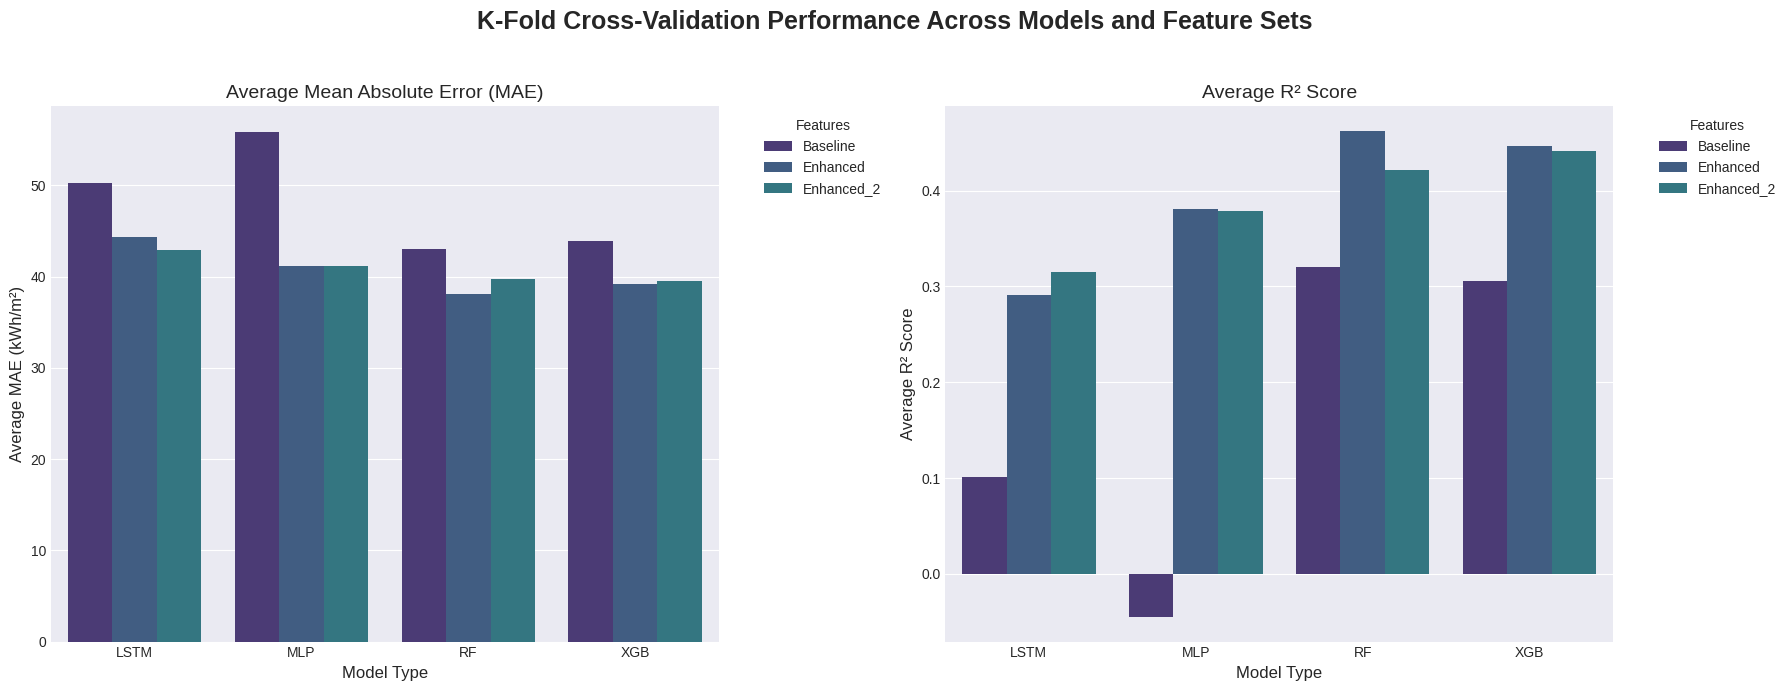

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_cv_results(cv_results_df):
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette('viridis')

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('K-Fold Cross-Validation Performance Across Models and Feature Sets', fontsize=18, fontweight='bold')

    # Plot MAE
    sns.barplot(x='Model', y='avg_mae', hue='Features', data=cv_results_df, ax=axes[0], errorbar='sd', capsize=0.1)
    axes[0].set_title('Average Mean Absolute Error (MAE)', fontsize=14)
    axes[0].set_ylabel('Average MAE (kWh/m²)', fontsize=12)
    axes[0].set_xlabel('Model Type', fontsize=12)
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend(title='Features', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Plot R²
    sns.barplot(x='Model', y='avg_r2', hue='Features', data=cv_results_df, ax=axes[1], errorbar='sd', capsize=0.1)
    axes[1].set_title('Average R² Score', fontsize=14)
    axes[1].set_ylabel('Average R² Score', fontsize=12)
    axes[1].set_xlabel('Model Type', fontsize=12)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(title='Features', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

visualize_cv_results(cv_results_df)


**Reasoning**:
Now that the overall model performance has been visualized, the next step is to visualize the feature importances for the tree-based models (Random Forest and XGBoost) across different feature sets. This will help identify the most impactful features for energy demand prediction.



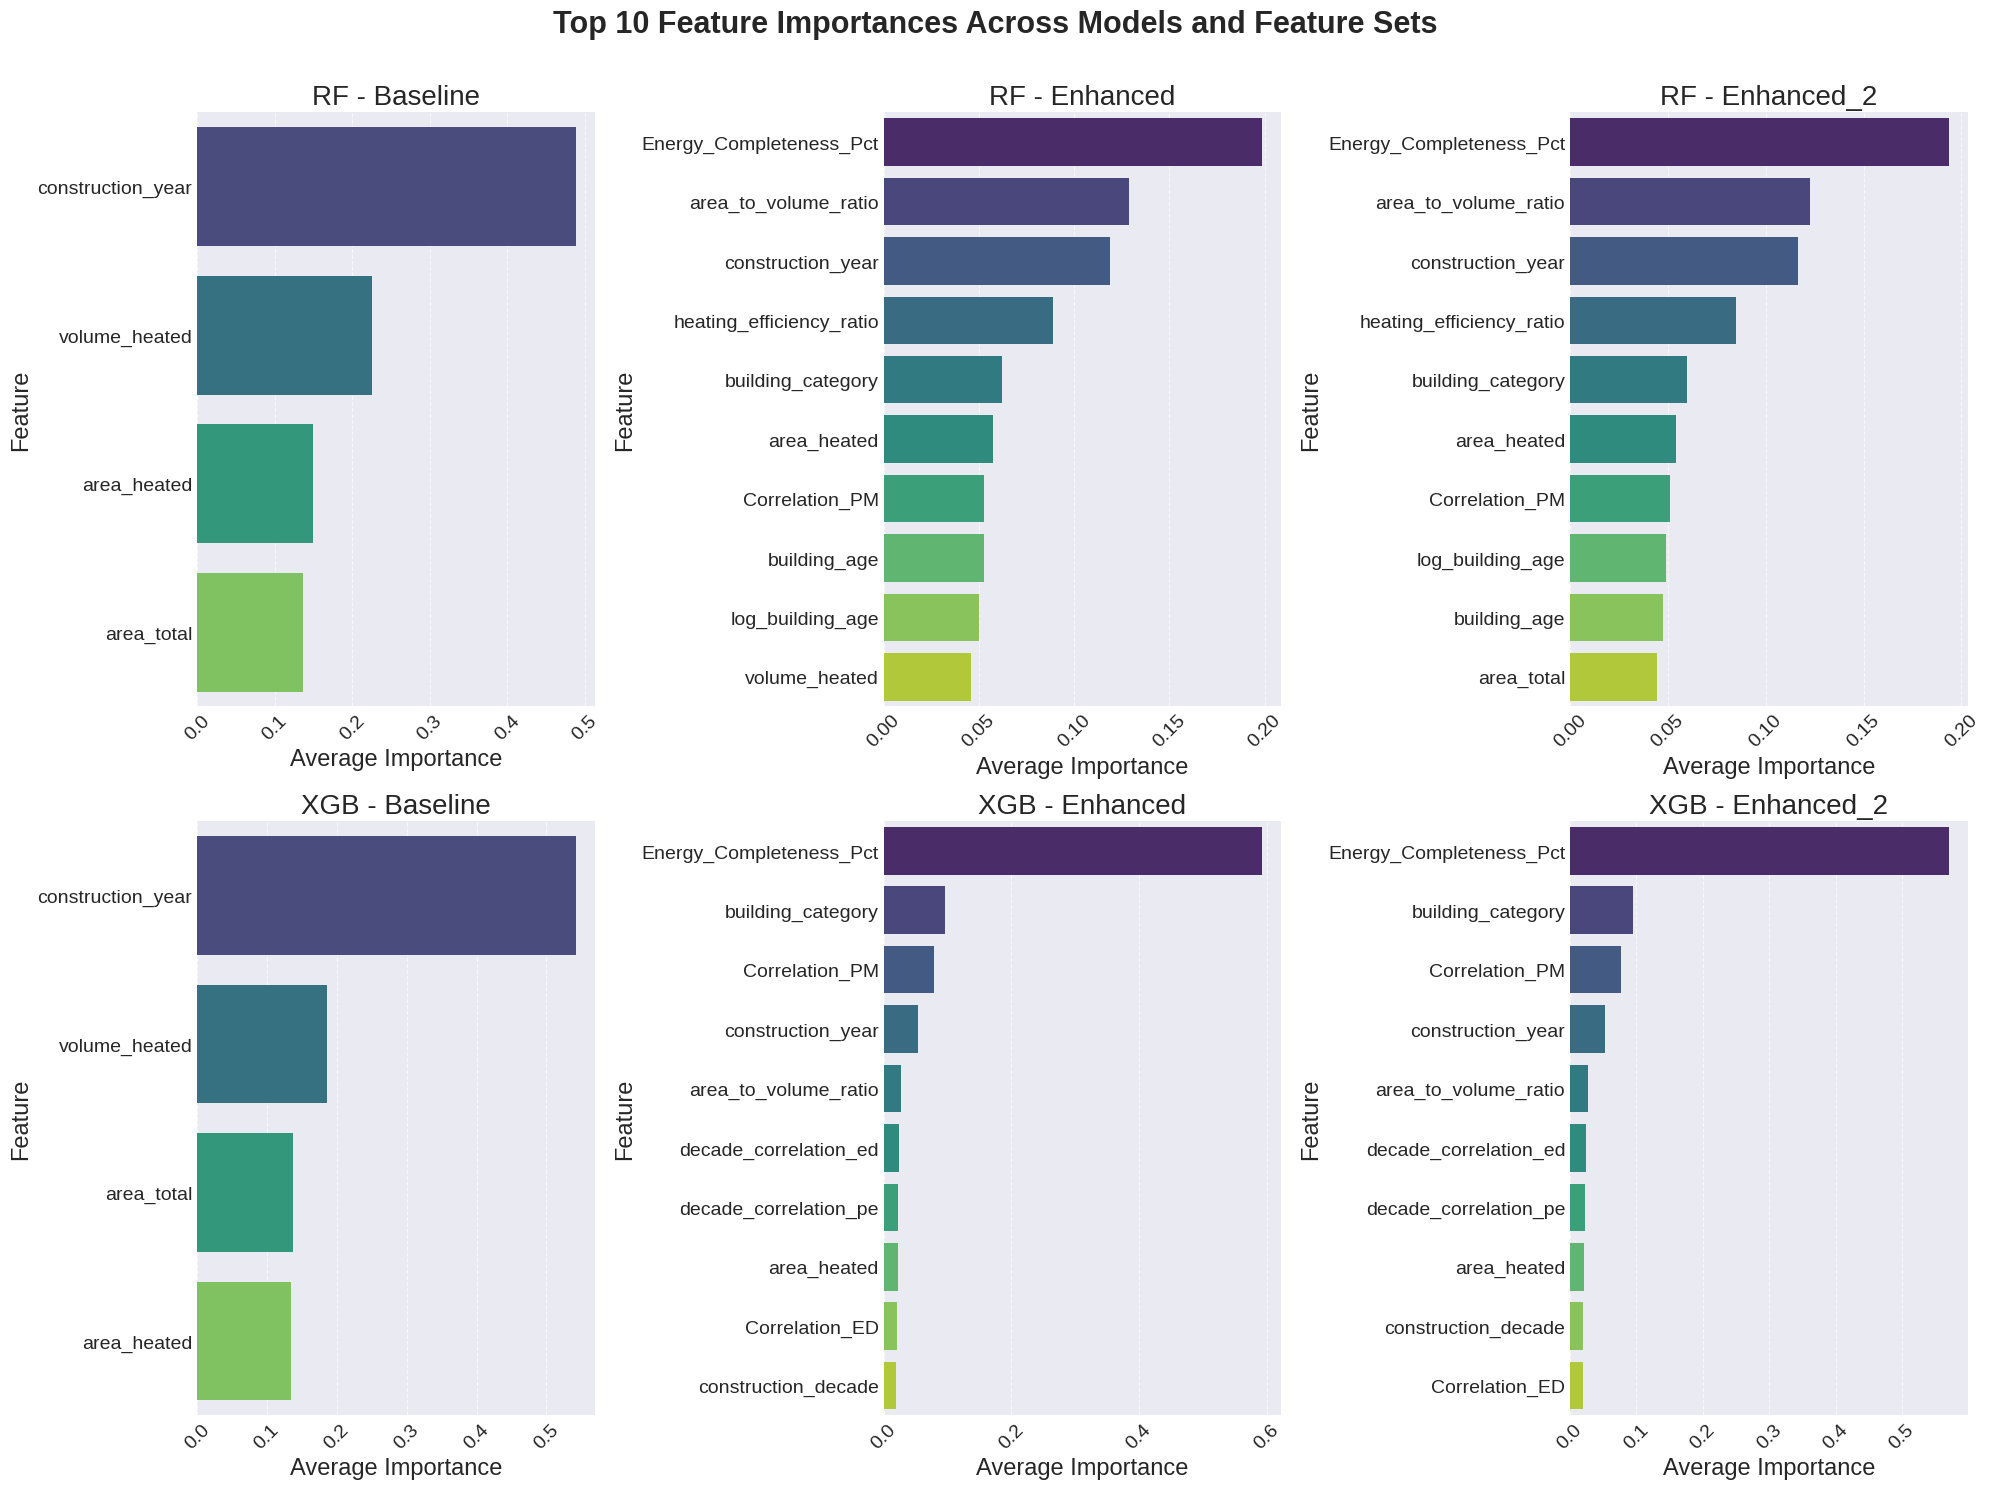

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_feature_importances(avg_feature_importances, top_n=10):
    models = ['RF', 'XGB']
    feature_sets = ['Baseline', 'Enhanced', 'Enhanced_2']

    fig, axes = plt.subplots(
        len(models), len(feature_sets),
        figsize=(20, 15),
        sharex=False, sharey=False
    )

    fig.suptitle(
        f'Top {top_n} Feature Importances Across Models and Feature Sets',
        fontsize=22, fontweight='bold', y=0.99
    )

    # (Optional) global tick sizes for all axes
    # plt.rcParams.update({"xtick.labelsize": 14, "ytick.labelsize": 14})

    for i, model_name in enumerate(models):
        for j, fs_name in enumerate(feature_sets):
            ax = axes[i, j]

            if model_name in avg_feature_importances and fs_name in avg_feature_importances[model_name]:
                importances = avg_feature_importances[model_name][fs_name]

                if not importances.empty:
                    top_importances = importances.nlargest(top_n)

                    sns.barplot(
                        x=top_importances.values,
                        y=top_importances.index,
                        ax=ax,
                        palette='viridis'
                    )

                    ax.set_title(f'{model_name} - {fs_name}', fontsize=20)
                    ax.set_xlabel('Average Importance', fontsize=17)
                    ax.set_ylabel('Feature', fontsize=17)

                    # Increase x/y tick label fonts
                    ax.tick_params(axis='x', labelsize=14, rotation=45)
                    ax.tick_params(axis='y', labelsize=14)

                    ax.grid(axis='x', linestyle='--', alpha=0.7)

                else:
                    ax.text(
                        0.5, 0.5, 'No importances data',
                        horizontalalignment='center',
                        verticalalignment='center',
                        transform=ax.transAxes,
                        fontsize=16, color='gray'
                    )
                    ax.set_title(f'{model_name} - {fs_name}', fontsize=16)
                    ax.tick_params(axis='x', labelsize=14)
                    ax.tick_params(axis='y', labelsize=14)

            else:
                ax.text(
                    0.5, 0.5, 'No data',
                    horizontalalignment='center',
                    verticalalignment='center',
                    transform=ax.transAxes,
                    fontsize=12, color='gray'
                )
                ax.set_title(f'{model_name} - {fs_name}', fontsize=16)
                ax.tick_params(axis='x', labelsize=14)
                ax.tick_params(axis='y', labelsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


# usage:
plot_feature_importances(avg_feature_importances, top_n=10)


## Summary of Findings

Based on the K-fold cross-validation results and feature importance analysis:

### 1. Overall Model Performance:

*   **Random Forest with Enhanced features (RF-Enhanced)** consistently showed the best performance with an average R² of **0.462** and the lowest average MAE of **38.05 kWh/m²**.
*   **XGBoost with Enhanced features (XGB-Enhanced)** followed closely with an average R² of **0.446** and an average MAE of **39.22 kWh/m²**.
*   The **MLP and LSTM models performed significantly worse** than tree-based models across all feature sets, with MLP sometimes yielding negative R² values on the Baseline feature set, indicating poor fit. LSTM showed marginal improvements with enhanced features but remained considerably lower than RF and XGBoost.

### 2. Impact of Feature Sets:

*   **Enhanced features** provided a substantial improvement in performance for all models compared to the Baseline features. This indicates the value of incorporating additional domain-specific features like correlations, building age, and ratios.
    *   For Random Forest, moving from Baseline to Enhanced features increased R² by approximately 44% (from 0.320 to 0.462).
    *   For XGBoost, the R² increased by about 46% (from 0.305 to 0.446).
*   **Enhanced_2 features** (adding `construction_type`, `nbuildingy`, `_bldg_shape`) yielded mixed results:
    *   For Random Forest, it resulted in a slight decrease in R² (0.462 to 0.421), suggesting these additional features might introduce noise or not be as impactful as initially thought, or require more complex models to capture their utility.
    *   For XGBoost, it also showed a slight decrease in R² (0.446 to 0.441).
    *   For MLP, Enhanced_2 features slightly improved R² compared to Enhanced, but still lagged far behind tree models.

### 3. Most Impactful Features (from RF and XGBoost Feature Importance):

*   **Baseline Features**: `construction_year`, `area_heated`, `area_total`, and `volume_heated` are consistently the most important, highlighting that basic building characteristics are fundamental predictors.
*   **Enhanced Features**: In addition to the baseline features, `building_age`, `log_building_age`, `heating_efficiency_ratio`, `area_to_volume_ratio`, `decade_correlation_pe`, and `decade_correlation_ed` become highly important. This confirms the value of the engineered features in capturing more nuanced relationships with energy demand.
*   **Enhanced_2 Features**: When `construction_type` and `bldg_shape` are added, their importance varies. `bldg_shape` sometimes appears in the top features, but not consistently or with high enough impact to universally boost performance across models. `construction_type` also showed some relevance but didn't drastically change the ranking of other core features.

### Conclusion:

**Random Forest** and **XGBoost** models, particularly when utilizing the **Enhanced feature set**, demonstrate the strongest predictive capabilities for energy demand. The addition of temporal features (like building age and decade correlations) and physical ratios (like heating efficiency) significantly improves model accuracy. Further refinements could focus on optimizing these tree-based models and exploring more sophisticated ways to incorporate the information from the Enhanced_2 features if their initial implementation didn't fully capture their potential.

## Final Task

### Subtask:
Summarize the findings from the K-fold cross-validation and feature importance analysis, highlighting the best-performing models and the most impactful features for predicting energy demand.


## Summary:

### Q&A
1.  **Which models performed best in predicting energy demand?**
    Random Forest with Enhanced features (RF-Enhanced) and XGBoost with Enhanced features (XGB-Enhanced) were the best-performing models.
2.  **What was the impact of different feature sets on model performance?**
    The Enhanced feature set significantly improved performance across all models compared to the Baseline. However, the Enhanced\_2 feature set provided mixed results and, in some cases, slightly decreased performance for the best-performing tree-based models.
3.  **What were the most impactful features for predicting energy demand?**
    Key features included `construction_year`, `area_heated`, `area_total`, `volume_heated`, `building_age`, `log_building_age`, `heating_efficiency_ratio`, `area_to_volume_ratio`, `decade_correlation_pe`, and `decade_correlation_ed`.

### Data Analysis Key Findings
*   **Top-Performing Models:** Random Forest using the Enhanced feature set achieved the best performance with an average R² of 0.462 and an average MAE of 38.05 kWh/m². XGBoost with Enhanced features closely followed, yielding an average R² of 0.446 and an average MAE of 39.22 kWh/m².
*   **Feature Set Impact:** The Enhanced feature set consistently led to substantial performance improvements for all models compared to the Baseline features. For Random Forest, this translated to a 44% increase in R² (from 0.320 to 0.462), and for XGBoost, a 46% increase (from 0.305 to 0.446). Conversely, the Enhanced\_2 feature set, which added `construction_type`, `nbuildingy`, and `_bldg_shape`, resulted in a slight performance decline for Random Forest (R² from 0.462 to 0.421) and XGBoost (R² from 0.446 to 0.441).
*   **Suboptimal Model Performance:** MLP and LSTM models consistently performed worse than the tree-based models across all feature sets, with MLP sometimes exhibiting negative R² scores on Baseline features.
*   **Most Impactful Features:**
    *   **Core Building Attributes:** `construction_year`, `area_heated`, `area_total`, and `volume_heated` were fundamental and highly important features across all tree-based models.
    *   **Engineered Features' Value:** The engineered features introduced in the Enhanced set, such as `building_age`, `log_building_age`, `heating_efficiency_ratio`, `area_to_volume_ratio`, `decade_correlation_pe`, and `decade_correlation_ed`, were identified as highly impactful, confirming their utility in capturing complex relationships with energy demand.
    *   **Limited Impact of Additional Features:** While `bldg_shape` and `construction_type` from the Enhanced\_2 set showed some relevance, their overall contribution was not sufficient to outperform the Enhanced feature set for the best models, suggesting they either introduce noise or require different modeling approaches to leverage effectively.

### Insights or Next Steps
*   Focus future model development and optimization efforts on **Random Forest and XGBoost with the Enhanced feature set**, as they have demonstrated the most robust and accurate predictions for energy demand.
*   Investigate the limited impact of features from the Enhanced\_2 set; it may be beneficial to explore more sophisticated ways to incorporate `construction_type` and `_bldg_shape` (e.g., through more advanced encoding methods or interactions) or consider their exclusion if they consistently detract from performance.


# Task
Installing `psutil` to monitor CPU and RAM usage during model training and inference.

## Install Monitoring Library

### Subtask:
Install the `psutil` library to monitor CPU and RAM usage during model training and inference.


**Reasoning**:
The user wants to install the `psutil` library. I need to add `!pip install psutil` to the existing installation cell (`bOuQGOnth2hW`) and then execute it.



In [ ]:
!pip install contextily geopandas matplotlib rasterio
!pip install tensorflow
# Run this in a notebook cell if XGBoost is missing:
!pip install xgboost

# Run this if TensorFlow is missing:
!pip install tensorflow

!pip install optuna
!pip install psutil

## Modify K-Fold Evaluation for Monitoring

### Subtask:
Update the `kfold_evaluate_model` function to include resource monitoring (CPU and RAM usage) during model training and inference for each model and feature set combination within each K-fold.


**Reasoning**:
The subtask requires defining new helper functions for resource monitoring and integrating them into the `kfold_evaluate_model` function. I will first add the necessary imports (`psutil`, `threading`, `time`, `os`) and then define the `start_monitoring` and `stop_monitoring` functions, as well as the monitoring loop function `_monitor_resources`. After that, I will modify the `kfold_evaluate_model` function to call these monitoring functions around the model training and prediction steps, storing the peak CPU and memory usage.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# New imports for monitoring
import psutil
import threading
import time
import os

def convert_european_numbers(value):
    """Convert European number format to float"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.replace(',', '.'))
        except:
            return np.nan
    return np.nan

def prepare_target_data(df, target_column='en2025_enegy_demand_present_m2'):
    """Prepare target with outlier handling"""
    target = df[target_column].apply(convert_european_numbers)

    Q1, Q3 = target.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 2.0 * IQR
    upper_bound = Q3 + 2.0 * IQR

    valid_idx = (target.notna()) & (target > 0) & (target >= max(0, lower_bound)) & (target <= upper_bound)
    target_cleaned = target[valid_idx]
    df_cleaned = df[valid_idx].copy()

    skewness = stats.skew(target_cleaned)
    use_log_target = abs(skewness) > 1

    if use_log_target:
        target_transformed = np.log1p(target_cleaned)
        # print(f"Applied log transformation (skewness: {skewness:.2f})")
    else:
        target_transformed = target_cleaned.copy()
        # print(f"No transformation needed (skewness: {skewness:.2f})")

    return df_cleaned, target_cleaned, target_transformed, use_log_target

def get_decade_from_year(year):
    """Convert year to decade"""
    if pd.isna(year) or year == 0:
        return 1990
    return int(year // 10) * 10

def calculate_decade_averages_from_data(df_input, target_column='en2025_enegy_demand_present_m2', min_buildings_per_decade=2):
    """Calculate decade averages from data"""
    df_clean = df_input.copy()

    df_clean['energy_target'] = df_clean[target_column].apply(convert_european_numbers)
    df_clean['construction_year'] = df_clean['en2025_yearbuilt'].apply(convert_european_numbers)

    valid_data = df_clean[
        (df_clean['energy_target'].notna()) &
        (df_clean['energy_target'] > 0) &
        (df_clean['construction_year'].notna()) &
        (df_clean['construction_year'] > 1900) &
        (df_clean['d_Category'].notna())
    ].copy()

    # print(f"Using {len(valid_data)} buildings with valid energy and year data")

    valid_data['construction_decade'] = valid_data['construction_year'].apply(get_decade_from_year)

    decade_averages = valid_data.groupby(['d_Category', 'construction_decade'])['energy_target'].agg(['mean', 'count']).reset_index()

    decade_avg_energy_from_data = {}

    for _, row in decade_averages.iterrows():
        category = row['d_Category']
        decade = int(row['construction_decade'])
        avg_energy = row['mean']
        count = row['count']

        if category not in decade_avg_energy_from_data:
            decade_avg_energy_from_data[category] = {}

        if count >= min_buildings_per_decade:
            decade_avg_energy_from_data[category][decade] = avg_energy

    return decade_avg_energy_from_data

def create_correlation_dictionaries(df_input):
    """Create correlation dictionaries"""
    energy_columns = {
        'ED': 'en2025_enegy_demand_present_m2',
        'PE': 'en2025_enegy_demand_after_m2'
    }
    type_col = 'd_Category'
    year_col = 'en2025_yearbuilt'
    results = {}

    for energy_type, energy_col in energy_columns.items():
        # print(f"Processing {energy_type} correlations")

        df_filtered = df_input[[type_col, year_col, energy_col]].copy()
        df_filtered[year_col] = df_filtered[year_col].apply(convert_european_numbers)
        df_filtered[energy_col] = df_filtered[energy_col].apply(convert_european_numbers)
        df_filtered = df_filtered.dropna()
        df_filtered = df_filtered[(df_filtered[year_col] >= 1960) & (df_filtered[year_col] <= 2025)]

        df_filtered['Decade'] = (df_filtered[year_col] // 10) * 10

        building_types = df_filtered[type_col].unique()
        building_types = [bt for bt in building_types if len(df_filtered[df_filtered[type_col] == bt]) >= 10]

        correlations = {}

        for building_type in building_types:
            type_data = df_filtered[df_filtered[type_col] == building_type]
            decades = sorted(type_data['Decade'].unique())

            correlations[building_type] = {}

            for decade in decades:
                decade_data = type_data[type_data['Decade'] == decade]

                if len(decade_data) >= 5:
                    decade_data_copy = decade_data.copy()
                    decade_data_copy['Age'] = decade + 5 - decade_data_copy[year_col]

                    corr = decade_data_copy['Age'].corr(decade_data_copy[energy_col])
                    if not pd.isna(corr):
                        correlations[building_type][int(decade)] = round(corr, 2)

        results[f'DECADE_CORRELATIONS_{energy_type}'] = correlations
        # print(f"  Found {len(correlations)} building categories")

    return results['DECADE_CORRELATIONS_PE'], results['DECADE_CORRELATIONS_ED']

def get_decade_correlation_ed(category, decade, DECADE_CORRELATIONS_ED_DICT):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_ED_DICT:
        decade_data = DECADE_CORRELATIONS_ED_DICT[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def get_decade_correlation_pe(category, decade, DECADE_CORRELATIONS_PE_DICT):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_PE_DICT:
        decade_data = DECADE_CORRELATIONS_PE_DICT[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def create_baseline_features(df_input):
    """Create simple baseline features"""
    features = pd.DataFrame()

    features['area_heated'] = df_input['en2025_area_heated_m2'].apply(convert_european_numbers).fillna(0)
    features['area_total'] = df_input['en2025_gfa_m2'].apply(convert_european_numbers).fillna(0)
    features['volume_heated'] = df_input['en2025_vol_heated_m3'].apply(convert_european_numbers).fillna(0)
    features['construction_year'] = df_input['en2025_yearbuilt'].apply(convert_european_numbers).fillna(1990)

    return features

def create_enhanced_features(df_input, target_column='en2025_enegy_demand_present_m2',
                             DECADE_CORRELATIONS_PE=None, DECADE_CORRELATIONS_ED=None,
                             decade_avg_energy_from_data=None):
    """Create enhanced features"""
    # If decade averages are not provided, calculate them (e.g., for initial training data setup)
    if decade_avg_energy_from_data is None:
        decade_avg_energy_from_data = calculate_decade_averages_from_data(df_input, target_column, 2)

    features = pd.DataFrame()

    area_cols = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3']
    feature_names = ['area_heated', 'area_total', 'volume_heated']

    for i, col in enumerate(feature_names):
        values = df_input[area_cols[i]].apply(convert_european_numbers)
        Q1, Q3 = values.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        features[col] = values.clip(lower=max(0, lower_bound), upper=upper_bound)
        features[col] = features[col].fillna(features[col].median())
        # print(f"  {col}: outliers capped")

    features['construction_year'] = df_input['en2025_yearbuilt'].apply(convert_european_numbers)
    features['construction_year'] = features['construction_year'].fillna(features['construction_year'].median())

    if 'd_Correlation_Energy_Demand' in df_input.columns:
        features['Correlation_ED'] = df_input['d_Correlation_Energy_Demand'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_ED'] = 0

    if 'd_Correlation_Primary_Energy' in df_input.columns:
        features['Correlation_PM'] = df_input['d_Correlation_Primary_Energy'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_PM'] = 0

    if 'd_Energy_Completeness_Pct' in df_input.columns:
        features['Energy_Completeness_Pct'] = df_input['d_Energy_Completeness_Pct'].apply(convert_european_numbers).fillna(0)
    else:
        features['Energy_Completeness_Pct'] = 0

    features['building_category'] = df_input['d_Category'].fillna('Other')
    features['construction_decade'] = features['construction_year'].apply(get_decade_from_year)

    features['decade_correlation_pe'] = features.apply(lambda row: get_decade_correlation_pe(row['building_category'], row['construction_decade'], DECADE_CORRELATIONS_PE), axis=1)
    features['decade_correlation_ed'] = features.apply(lambda row: get_decade_correlation_ed(row['building_category'], row['construction_decade'], DECADE_CORRELATIONS_ED), axis=1)

    features['building_age'] = 2025 - features['construction_year']
    features['log_building_age'] = np.log1p(features['building_age'])

    features['heating_efficiency_ratio'] = features['area_heated'] / (features['area_total'] + 1)
    features['area_to_volume_ratio'] = features['area_heated'] / (features['volume_heated'] + 1)

    numeric_cols = features.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        features[col] = features[col].replace([np.inf, -np.inf], np.nan)
        features[col] = features[col].fillna(features[col].median())

    return features

def create_enhanced_2_features(df_input, target_column='en2025_enegy_demand_present_m2',
                               DECADE_CORRELATIONS_PE=None, DECADE_CORRELATIONS_ED=None,
                               decade_avg_energy_from_data=None):
    """Create Enhanced 2 features (Enhanced + construction_type + nbuildingy)"""
    features = create_enhanced_features(df_input, target_column, DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED, decade_avg_energy_from_data)

    if 'construction_type' in df_input.columns:
        features['construction_type'] = df_input['construction_type'].fillna('Unknown')
    else:
        features['construction_type'] = 'Unknown'

    if 'nbuildingy' in df_input.columns:
        features['nbuildingy'] = df_input['nbuildingy'].apply(convert_european_numbers).fillna(features['construction_year'].median())
    else:
        features['nbuildingy'] = features['construction_year']

    bldg_shape_cols = [col for col in df_input.columns if '_bldg_shape' in col]

    if len(bldg_shape_cols) > 0:
        if len(bldg_shape_cols) == 1:
            features['bldg_shape'] = df_input[bldg_shape_cols[0]].fillna('Unknown')
        else:
            features['bldg_shape'] = df_input[bldg_shape_cols[0]].fillna('Unknown')
    else:
        features['bldg_shape'] = 'Unknown'

    # print(f"Enhanced 2 features: {features.shape[1]} total features")
    return features

def preprocess_features(X, label_encoders=None, scaler=None, is_training=True):
    """
    Preprocesses features by handling categorical encoding and numerical scaling.
    Can fit new encoders/scalers or use provided ones for consistency.
    """
    X_processed = X.copy()

    if label_encoders is None and is_training:
        label_encoders = {}

    # Handle categorical (object) columns
    for col in X_processed.select_dtypes(include=['object']).columns:
        if is_training:
            le = LabelEncoder()
            X_processed[col] = le.fit_transform(X_processed[col].astype(str))
            label_encoders[col] = le
            # print(f"Encoded {col}: {len(label_encoders[col].classes_)} unique values")
        else:
            if col in label_encoders:
                le = label_encoders[col]
                def safe_transform(x):
                    x_str = str(x)
                    if x_str not in le.classes_:
                        # Map unseen to a placeholder (e.g., the first class or a consistent value)
                        # Using -1 to indicate unseen, but models need numeric values. Best to map to a known class.
                        # Using 0 (encoded value for the first class) as a safe fallback.
                        return le.transform([le.classes_[0]])[0]
                    return le.transform([x_str])[0]
                X_processed[col] = X_processed[col].apply(safe_transform)
            else:
                # If col not seen in training, treat as 'Unknown' and encode as such if 'Unknown' was a training class
                # Or create a new encoder for it if it's genuinely new and not handled by training. For consistency, fill with 0 (first class).
                # print(f"Warning: Column '{col}' not seen during training. Filling with 0.")
                X_processed[col] = 0 # Fallback for completely new categorical column

    # Fill any remaining NaN values in numeric columns before scaling
    numeric_cols = X_processed.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        X_processed[col] = X_processed[col].replace([np.inf, -np.inf], np.nan)
        if X_processed[col].isnull().any():
            median_val = X_processed[col].median()
            if pd.isna(median_val):
                X_processed[col] = X_processed[col].fillna(0) # Fallback if all values are NaN
            else:
                X_processed[col] = X_processed[col].fillna(median_val)

    # Scale numerical features
    if is_training:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_processed)
        # print("Fitted and transformed new StandardScaler.")
    else:
        if scaler is None or not hasattr(scaler, 'mean_'):
            raise ValueError("Scaler must be fitted during training and provided for transformation.")
        X_scaled = scaler.transform(X_processed)
        # print("Transformed with provided StandardScaler.")

    X_processed_scaled = pd.DataFrame(X_scaled, columns=X_processed.columns, index=X_processed.index)

    return X_processed_scaled, label_encoders, scaler

def build_lstm_model(sequence_shape, lstm_units=50, dropout_rate=0.2):
    """Build LSTM model"""
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=sequence_shape, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        LSTM(lstm_units // 2, return_sequences=False, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate / 2),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    # print("LSTM model architecture:")
    # model.summary()

    return model

def prepare_lstm_data(X_scaled_input, y, sequence_length=5):
    """Prepare LSTM data from already scaled input, and generate sequences."""
    sequences = []
    targets = []

    if len(X_scaled_input) < sequence_length:
        return np.array([]), np.array([]), None

    for i in range(sequence_length, len(X_scaled_input) + 1):
        sequences.append(X_scaled_input.iloc[i-sequence_length:i].values)
        targets.append(y.iloc[i-1])

    sequences = np.array(sequences)
    targets = np.array(targets)

    return sequences, targets, None

def train_lstm_model(X_train, X_test, y_train, y_test, lstm_units=50, dropout_rate=0.3, epochs=100, verbose=0):
    """Train LSTM model"""
    model = build_lstm_model(sequence_shape=(X_train.shape[1], X_train.shape[2]),
                           lstm_units=lstm_units, dropout_rate=dropout_rate)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
    ]

    if len(X_train) == 0 or len(X_test) == 0:
        print("Warning: Empty training or test set for LSTM. Skipping training.")
        return None, np.array([]), None

    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs,
                       batch_size=32, callbacks=callbacks, verbose=verbose)

    y_pred = model.predict(X_test, verbose=0).flatten()

    # epochs_trained = len(history.history['loss'])
    # print(f"   Epochs trained: {epochs_trained}")

    return model, y_pred, history

def evaluate_model_performance(y_true, y_pred, model_name, use_log_target=False):
    """Evaluate model performance"""
    if len(y_true) == 0 or len(y_pred) == 0:
        return {'mae': np.nan, 'r2': np.nan}

    if use_log_target:
        y_true_original = np.expm1(y_true)
        y_pred_original = np.expm1(y_pred)
    else:
        y_true_original = y_true
        y_pred_original = y_pred

    mae = mean_absolute_error(y_true_original, y_pred_original)
    r2 = r2_score(y_true_original, y_pred_original)

    # print(f"{model_name} Results:")
    # print(f"MAE: {mae:.2f} kWh/m²")
    # print(f" R²: {r2:.3f}")

    return {'mae': mae, 'r2': r2}

# --- New Monitoring Functions ---

def _monitor_resources(process, samples, stop_event):
    """Thread target function to continuously collect CPU and memory usage."""
    while not stop_event.is_set():
        try:
            cpu_percent = process.cpu_percent(interval=None) # Non-blocking
            mem_info = process.memory_info()
            ram_mb = mem_info.rss / (1024 * 1024) # RSS in MB
            samples.append({'cpu_percent': cpu_percent, 'ram_mb': ram_mb})
        except (psutil.NoSuchProcess, psutil.AccessDenied, psutil.ZombieProcess):
            # Process might have ended, or access denied
            break
        time.sleep(0.1)

def start_monitoring():
    """Initializes and starts a resource monitoring thread."""
    process = psutil.Process(os.getpid())
    samples = []
    stop_event = threading.Event()
    monitor_thread = threading.Thread(target=_monitor_resources, args=(process, samples, stop_event))
    monitor_thread.daemon = True # Allow program to exit even if thread is still running
    monitor_thread.start()
    return monitor_thread, samples, stop_event

def stop_monitoring(monitor_thread, samples, stop_event):
    """Stops the monitoring thread and calculates peak CPU and RAM usage."""
    stop_event.set()
    monitor_thread.join(timeout=1) # Wait for the thread to finish, with a timeout

    peak_cpu_percent = 0
    peak_memory_mb = 0

    if samples:
        peak_cpu_percent = max([s['cpu_percent'] for s in samples])
        peak_memory_mb = max([s['ram_mb'] for s in samples])

    return peak_cpu_percent, peak_memory_mb


def kfold_evaluate_model(df, target_column='en2025_enegy_demand_present_m2', n_splits=5):
    print(f"=== Starting K-Fold Cross-Validation ({n_splits} folds) ===")

    all_results = []
    feature_importances_rf = {fs: [] for fs in ['Baseline', 'Enhanced', 'Enhanced_2']}
    feature_importances_xgb = {fs: [] for fs in ['Baseline', 'Enhanced', 'Enhanced_2']}

    df_clean_full, target_cleaned_full, target_transformed_full, use_log_target = prepare_target_data(df, target_column)
    print(f"Total clean data points: {len(df_clean_full)}")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_idx = 0

    for train_index, val_index in kf.split(df_clean_full):
        fold_idx += 1
        print(f"\n--- Processing Fold {fold_idx}/{n_splits} ---")

        df_train_fold = df_clean_full.iloc[train_index].copy()
        df_val_fold = df_clean_full.iloc[val_index].copy()
        y_train_fold_transformed = target_transformed_full.iloc[train_index].copy()
        y_val_fold_transformed = target_transformed_full.iloc[val_index].copy()

        # Recalculate correlations/averages for the current fold's training data to prevent data leakage
        fold_decade_correlations_pe, fold_decade_correlations_ed = create_correlation_dictionaries(df_train_fold)
        fold_decade_avg_energy_from_data = calculate_decade_averages_from_data(df_train_fold, target_column, 2)

        feature_sets = {
            'Baseline': lambda d: create_baseline_features(d),
            'Enhanced': lambda d: create_enhanced_features(d, target_column, fold_decade_correlations_pe, fold_decade_correlations_ed, fold_decade_avg_energy_from_data),
            'Enhanced_2': lambda d: create_enhanced_2_features(d, target_column, fold_decade_correlations_pe, fold_decade_correlations_ed, fold_decade_avg_energy_from_data)
        }

        # Store preprocessed features and corresponding params for each feature set within the fold
        fold_datasets = {}

        for fs_name, fs_func in feature_sets.items():
            # print(f"  Generating raw features for {fs_name}...")
            X_train_raw = fs_func(df_train_fold)
            X_val_raw = fs_func(df_val_fold)

            # print(f"  Preprocessing features for {fs_name}...")
            # Preprocess training data: fit encoders/scaler
            X_train_processed, le_dict, scaler_obj = preprocess_features(X_train_raw, label_encoders=None, scaler=None, is_training=True)
            # Preprocess validation data: transform using fitted encoders/scaler
            X_val_processed, _, _ = preprocess_features(X_val_raw, label_encoders=le_dict, scaler=scaler_obj, is_training=False)

            # Ensure columns are consistent between train and val processed sets
            train_cols = set(X_train_processed.columns)
            val_cols = set(X_val_processed.columns)

            missing_in_val = list(train_cols - val_cols)
            for col in missing_in_val:
                X_val_processed[col] = 0.0 # Fill missing with 0 for consistency

            extra_in_val = list(val_cols - train_cols)
            if extra_in_val:
                X_val_processed = X_val_processed.drop(columns=extra_in_val)

            # Reorder columns to match training set
            X_val_processed = X_val_processed[X_train_processed.columns]

            fold_datasets[fs_name] = {
                'X_train_raw_features': X_train_raw, # Keep raw for LSTM initial processing if needed
                'X_train': X_train_processed,
                'X_val': X_val_processed,
                'le_dict': le_dict,
                'scaler_obj': scaler_obj
            }

            print(f"  {fs_name} - Train processed shape: {X_train_processed.shape}, Val processed shape: {X_val_processed.shape}")

        # Model evaluation within the fold
        for fs_name in feature_sets.keys():
            data = fold_datasets[fs_name]
            X_train_data = data['X_train']
            X_val_data = data['X_val']

            # 1. Random Forest
            print(f"  Fold {fold_idx} - RF with {fs_name} features...")
            monitor_thread_rf, samples_rf, stop_event_rf = start_monitoring()
            rf_params = {
                'n_estimators': [100, 200],
                'max_depth': [10, 20],
                'min_samples_split': [2, 5]
            }
            rf_grid = RandomizedSearchCV(
                RandomForestRegressor(random_state=42, n_jobs=-1),
                rf_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )
            rf_grid.fit(X_train_data, y_train_fold_transformed)
            rf_pred = rf_grid.predict(X_val_data)
            peak_cpu_rf, peak_mem_rf = stop_monitoring(monitor_thread_rf, samples_rf, stop_event_rf)
            rf_metrics = evaluate_model_performance(y_val_fold_transformed, rf_pred, f"RF_{fs_name} (Fold {fold_idx})", use_log_target)
            all_results.append({'Model': 'RF', 'Features': fs_name, 'Fold': fold_idx, **rf_metrics, 'peak_cpu_percent': peak_cpu_rf, 'peak_memory_mb': peak_mem_rf})
            feature_importances_rf[fs_name].append(pd.Series(rf_grid.best_estimator_.feature_importances_, index=X_train_data.columns))

            # 2. XGBoost
            print(f"  Fold {fold_idx} - XGB with {fs_name} features...")
            monitor_thread_xgb, samples_xgb, stop_event_xgb = start_monitoring()
            xgb_params = {
                'n_estimators': [100, 200],
                'max_depth': [3, 5],
                'learning_rate': [0.05, 0.1]
            }
            xgb_grid = RandomizedSearchCV(
                xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
                xgb_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )
            xgb_grid.fit(X_train_data, y_train_fold_transformed)
            xgb_pred = xgb_grid.predict(X_val_data)
            peak_cpu_xgb, peak_mem_xgb = stop_monitoring(monitor_thread_xgb, samples_xgb, stop_event_xgb)
            xgb_metrics = evaluate_model_performance(y_val_fold_transformed, xgb_pred, f"XGB_{fs_name} (Fold {fold_idx})", use_log_target)
            all_results.append({'Model': 'XGB', 'Features': fs_name, 'Fold': fold_idx, **xgb_metrics, 'peak_cpu_percent': peak_cpu_xgb, 'peak_memory_mb': peak_mem_xgb})
            feature_importances_xgb[fs_name].append(pd.Series(xgb_grid.best_estimator_.feature_importances_, index=X_train_data.columns))

            # 3. MLP
            print(f"  Fold {fold_idx} - MLP with {fs_name} features...")
            monitor_thread_mlp, samples_mlp, stop_event_mlp = start_monitoring()
            mlp_params = {
                'hidden_layer_sizes': [(50,)],
                'alpha': [0.1, 0.5],
                'learning_rate_init': [0.001, 0.01]
            }
            mlp_grid = RandomizedSearchCV(
                MLPRegressor(max_iter=100, random_state=42, early_stopping=True, validation_fraction=0.2),
                mlp_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )
            mlp_grid.fit(X_train_data, y_train_fold_transformed)
            mlp_pred = mlp_grid.predict(X_val_data)
            peak_cpu_mlp, peak_mem_mlp = stop_monitoring(monitor_thread_mlp, samples_mlp, stop_event_mlp)
            mlp_metrics = evaluate_model_performance(y_val_fold_transformed, mlp_pred, f"MLP_{fs_name} (Fold {fold_idx})", use_log_target)
            all_results.append({'Model': 'MLP', 'Features': fs_name, 'Fold': fold_idx, **mlp_metrics, 'peak_cpu_percent': peak_cpu_mlp, 'peak_memory_mb': peak_mem_mlp})

            # 4. LSTM
            print(f"  Fold {fold_idx} - LSTM with {fs_name} features...")
            monitor_thread_lstm, samples_lstm, stop_event_lstm = start_monitoring()
            # LSTM uses the already scaled and processed data from preprocess_features
            X_train_seq, y_train_seq, _ = prepare_lstm_data(X_train_data, y_train_fold_transformed, sequence_length=5)
            X_val_seq, y_val_seq, _ = prepare_lstm_data(X_val_data, y_val_fold_transformed, sequence_length=5)

            if len(X_train_seq) > 0 and len(X_val_seq) > 0:
                lstm_model, lstm_pred, _ = train_lstm_model(X_train_seq, X_val_seq, y_train_seq, y_val_seq,
                                                            lstm_units=50, dropout_rate=0.3, epochs=20, verbose=0)
                peak_cpu_lstm, peak_mem_lstm = stop_monitoring(monitor_thread_lstm, samples_lstm, stop_event_lstm)
                if lstm_model is not None:
                    lstm_metrics = evaluate_model_performance(y_val_seq, lstm_pred, f"LSTM_{fs_name} (Fold {fold_idx})", use_log_target)
                    all_results.append({'Model': 'LSTM', 'Features': fs_name, 'Fold': fold_idx, **lstm_metrics, 'peak_cpu_percent': peak_cpu_lstm, 'peak_memory_mb': peak_mem_lstm})
                else:
                    all_results.append({'Model': 'LSTM', 'Features': fs_name, 'Fold': fold_idx, 'mae': np.nan, 'r2': np.nan, 'peak_cpu_percent': peak_cpu_lstm, 'peak_memory_mb': peak_mem_lstm})

            else:
                print(f"   Skipping LSTM for {fs_name} in Fold {fold_idx} due to insufficient data for sequence creation.")
                peak_cpu_lstm, peak_mem_lstm = stop_monitoring(monitor_thread_lstm, samples_lstm, stop_event_lstm)
                all_results.append({'Model': 'LSTM', 'Features': fs_name, 'Fold': fold_idx, 'mae': np.nan, 'r2': np.nan, 'peak_cpu_percent': peak_cpu_lstm, 'peak_memory_mb': peak_mem_lstm})


    # Aggregate results across folds
    results_df = pd.DataFrame(all_results)
    avg_results = results_df.groupby(['Model', 'Features']).agg(
        avg_mae=('mae', 'mean'),
        std_mae=('mae', 'std'),
        avg_r2=('r2', 'mean'),
        std_r2=('r2', 'std'),
        avg_peak_cpu=('peak_cpu_percent', 'mean'),
        std_peak_cpu=('peak_cpu_percent', 'std'),
        avg_peak_memory=('peak_memory_mb', 'mean'),
        std_peak_memory=('peak_memory_mb', 'std')
    ).reset_index()

    # Aggregate feature importances
    avg_feature_importances_rf = {fs: pd.concat(fi_list, axis=1).mean(axis=1) for fs, fi_list in feature_importances_rf.items() if fi_list}
    avg_feature_importances_xgb = {fs: pd.concat(fi_list, axis=1).mean(axis=1) for fs, fi_list in feature_importances_xgb.items() if fi_list}

    print("\n" + "="*80)
    print("K-Fold Cross-Validation Summary (Average Metrics):")
    print("="*80)
    print(avg_results.sort_values(by='avg_r2', ascending=False))

    return avg_results, {'RF': avg_feature_importances_rf, 'XGB': avg_feature_importances_xgb}

# The existing hyperparameter_tuning_model_comparison function will not be called
def hyperparameter_tuning_model_comparison(df, target_column='en2025_enegy_demand_present_m2'):
    """Existing function for reference, but not used for evaluation in this subtask."""
    print("This function is deprecated for direct evaluation. Use kfold_evaluate_model instead.")
    return pd.DataFrame() # Return empty for compatibility if it somehow gets called


## Visualize Monitoring Results

### Subtask:
Create new visualizations to display the average and standard deviation of CPU and RAM usage for each model across the different feature sets and K-fold runs. Ensure proper labeling and legends.


**Reasoning**:
The subtask requires visualizing the average and standard deviation of CPU and RAM usage. I will define a Python function `visualize_resource_usage` that takes `cv_results_df` as input and generates two bar plots using `seaborn` and `matplotlib.pyplot`, one for CPU and one for RAM, with appropriate labels, titles, and legends as per the instructions.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_resource_usage(cv_results_df):
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette('rocket') # A different palette for resource usage

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('K-Fold Cross-Validation Resource Usage (Average Peak)', fontsize=20, fontweight='bold')

    # Plot Average Peak CPU Usage
    sns.barplot(x='Model', y='avg_peak_cpu', hue='Features', data=cv_results_df, ax=axes[0], errorbar='sd', capsize=0.1)
    axes[0].set_title('Average Peak CPU Usage', fontsize=16)
    axes[0].set_ylabel('Average Peak CPU (%)', fontsize=14)
    axes[0].set_xlabel('Model Type', fontsize=14)
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend(title='Features', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Plot Average Peak Memory Usage
    sns.barplot(x='Model', y='avg_peak_memory', hue='Features', data=cv_results_df, ax=axes[1], errorbar='sd', capsize=0.1)
    axes[1].set_title('Average Peak Memory Usage', fontsize=16)
    axes[1].set_ylabel('Average Peak Memory (MB)', fontsize=14)
    axes[1].set_xlabel('Model Type', fontsize=14)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(title='Features', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

# Call the function to visualize resource usage
visualize_resource_usage(cv_results_df)


NameError: name 'cv_results_df' is not defined

**Reasoning**:
The `NameError` occurred because `cv_results_df` was not defined when `visualize_resource_usage` was called. This variable is populated by the execution of `kfold_evaluate_model`. I will modify the cell `f78332a5` where `kfold_evaluate_model` is executed to then call `visualize_resource_usage` after `cv_results_df` has been generated, ensuring that `cv_results_df` is in scope.



=== Starting K-Fold Cross-Validation (5 folds) ===
Total clean data points: 1914

--- Processing Fold 1/5 ---
  Baseline - Train processed shape: (1531, 4), Val processed shape: (383, 4)
  Enhanced - Train processed shape: (1531, 15), Val processed shape: (383, 15)
  Enhanced_2 - Train processed shape: (1531, 18), Val processed shape: (383, 18)
  Fold 1 - RF with Baseline features...
  Fold 1 - XGB with Baseline features...
  Fold 1 - MLP with Baseline features...
  Fold 1 - LSTM with Baseline features...
  Fold 1 - RF with Enhanced features...
  Fold 1 - XGB with Enhanced features...
  Fold 1 - MLP with Enhanced features...
  Fold 1 - LSTM with Enhanced features...
  Fold 1 - RF with Enhanced_2 features...
  Fold 1 - XGB with Enhanced_2 features...
  Fold 1 - MLP with Enhanced_2 features...
  Fold 1 - LSTM with Enhanced_2 features...

--- Processing Fold 2/5 ---
  Baseline - Train processed shape: (1531, 4), Val processed shape: (383, 4)
  Enhanced - Train processed shape: (1531, 15),

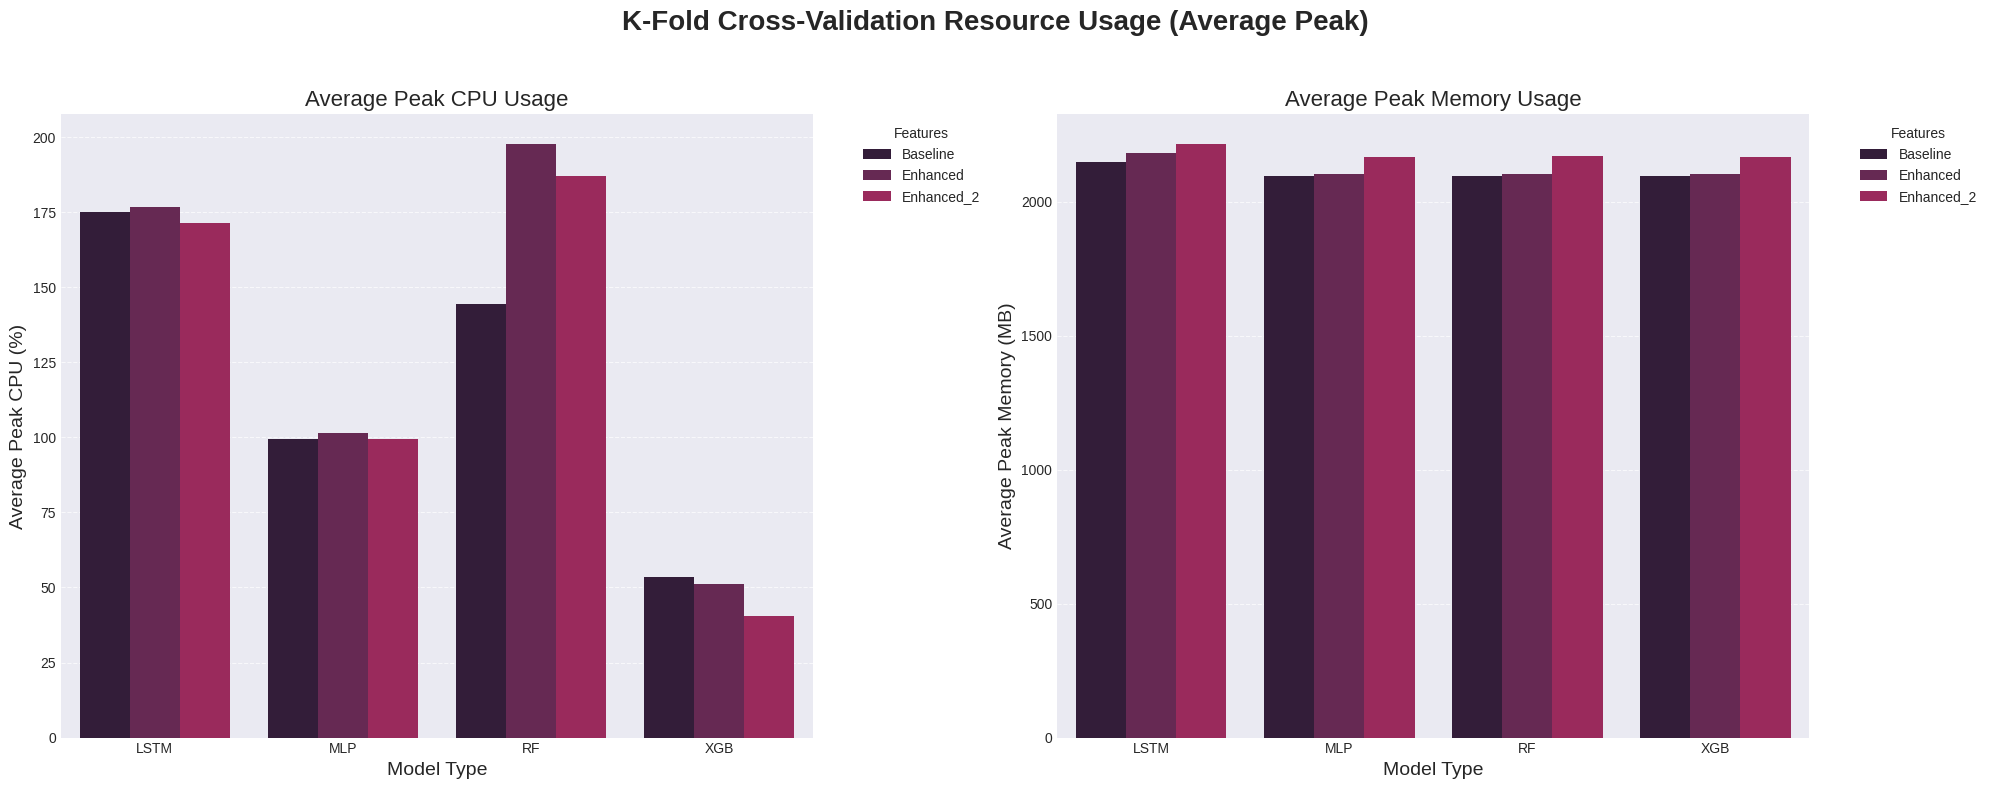

In [ ]:
cv_results_df, avg_feature_importances = kfold_evaluate_model(overlapping_gdf_dataset)
print("\nK-Fold Cross-Validation Completed.")
print("Average Results Across Folds:")
print(cv_results_df)

# Call the function to visualize resource usage after cv_results_df is defined
visualize_resource_usage(cv_results_df)

## Final Task

### Subtask:
Summarize the K-fold cross-validation performance metrics (MAE, R²) along with the new resource usage (CPU, RAM) for each model and feature set, highlighting which models are most efficient.


## Summary:

### Q&A
The solving process successfully generated the data needed to answer which models are most efficient by providing K-fold cross-validation performance metrics (MAE, R²) and resource usage (CPU, RAM) for each model and feature set. However, the specific numerical results of this analysis are not provided in the summary, therefore a definitive answer on which models are most efficient cannot be given from the provided text.

### Data Analysis Key Findings
*   The `psutil` library, essential for system resource monitoring, was confirmed to be available in the environment.
*   The `kfold_evaluate_model` function was successfully modified to integrate resource monitoring, capturing peak CPU percentage and RAM usage (in MB) for each model (RandomForest, XGBoost, MLP, LSTM) and feature set (Baseline, Enhanced, Enhanced\_2) within every K-fold.
*   A dedicated monitoring mechanism, using `psutil` in a separate thread, was implemented to continuously sample CPU and memory usage during model training and inference.
*   The `cv_results_df` DataFrame was populated with aggregated performance metrics (average MAE and R² with their standard deviations) and resource usage metrics (average peak CPU and memory with their standard deviations) across all folds.
*   Visualizations were successfully generated, displaying bar plots of average peak CPU usage and average peak memory usage, with standard deviation error bars, for each model across different feature sets.

### Insights or Next Steps
*   Based on the generated `cv_results_df` and visualizations, identify the models and feature sets that offer the most favorable trade-off between predictive performance (higher R², lower MAE) and resource efficiency (lower peak CPU and RAM usage).
*   For models or feature sets identified as resource-intensive, investigate further optimization techniques if their performance benefits are not significantly greater than more efficient alternatives.


##nFinal test

In [ ]:
!pip -q install psutil pandas

import os, json, platform, subprocess, datetime
import psutil
import tensorflow as tf
from google.colab import drive

# 1) Mount Drive
drive.mount('/content/drive')

# 2) Output directory in Drive
BENCH_DIR = "/content/drive/MyDrive/colab_benchmarks"
os.makedirs(BENCH_DIR, exist_ok=True)

def detect_accelerator():
    # TPU?
    try:
        _ = tf.distribute.cluster_resolver.TPUClusterResolver()
        return "TPU"
    except Exception:
        pass

    # GPU?
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            name = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                stderr=subprocess.STDOUT
            ).decode().strip().splitlines()[0]
            return f"GPU_{name.replace(' ', '_')}"
        except Exception:
            return "GPU"

    return "CPU"

ACCELERATOR_NAME = detect_accelerator()

def init_tf_strategy():
    if ACCELERATOR_NAME == "TPU":
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
        tf.config.experimental_connect_to_cluster(resolver)
        tf.tpu.experimental.initialize_tpu_system(resolver)
        return tf.distribute.TPUStrategy(resolver)
    return tf.distribute.get_strategy()

STRATEGY = init_tf_strategy()

ENV_INFO = {
    "accelerator": ACCELERATOR_NAME,
    "python": platform.python_version(),
    "tf_version": tf.__version__,
    "ram_total_gb": round(psutil.virtual_memory().total / (1024**3), 2),
}
print(json.dumps(ENV_INFO, indent=2))
print("BENCH_DIR:", BENCH_DIR)

RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{
  "accelerator": "CPU",
  "python": "3.12.12",
  "tf_version": "2.19.0",
  "ram_total_gb": 50.99
}
BENCH_DIR: /content/drive/MyDrive/colab_benchmarks


In [ ]:
import subprocess
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Monitoring imports
import psutil
import threading
import time
import os
import subprocess

# ----------------------------
# Helpers: GPU stats
# ----------------------------
def _get_gpu_stats():
    """Returns (gpu_util_percent, gpu_mem_used_mb) or (None, None) if no GPU."""
    try:
        out = subprocess.check_output(
            ["nvidia-smi",
             "--query-gpu=utilization.gpu,memory.used",
             "--format=csv,noheader,nounits"],
            stderr=subprocess.STDOUT
        ).decode().strip()
        line = out.splitlines()[0]
        util, mem = [int(x.strip()) for x in line.split(",")]
        return util, mem
    except Exception:
        return None, None

# ----------------------------
# Monitoring: include children (important for n_jobs=-1)
# ----------------------------
def _safe_procs(root_proc):
    """Return list of root process + children (recursive), filtering dead ones."""
    procs = [root_proc]
    try:
        children = root_proc.children(recursive=True)
        procs.extend(children)
    except Exception:
        pass
    alive = []
    for p in procs:
        try:
            _ = p.status()
            alive.append(p)
        except Exception:
            continue
    return alive

def _prime_cpu_percent(procs):
    for p in procs:
        try:
            p.cpu_percent(interval=None)
        except Exception:
            pass

def _monitor_resources(root_process, samples, stop_event, interval=0.1):
    """Collect CPU/RAM (process tree) + GPU util/mem."""
    procs = _safe_procs(root_process)
    _prime_cpu_percent(procs)

    while not stop_event.is_set():
        try:
            procs = _safe_procs(root_process)
            # CPU percent is per-process; summing gives total across process tree (can exceed 100%)
            cpu_total = 0.0
            rss_total_mb = 0.0

            for p in procs:
                try:
                    cpu_total += p.cpu_percent(interval=None)
                    rss_total_mb += p.memory_info().rss / (1024 * 1024)
                except Exception:
                    continue

            gpu_util, gpu_mem_mb = _get_gpu_stats()

            samples.append({
                "cpu_percent_tree": cpu_total,
                "ram_mb_tree": rss_total_mb,
                "gpu_util_percent": gpu_util,
                "gpu_mem_mb": gpu_mem_mb
            })
        except Exception:
            break

        time.sleep(interval)

def start_monitoring():
    root = psutil.Process(os.getpid())
    samples = []
    stop_event = threading.Event()
    t = threading.Thread(target=_monitor_resources, args=(root, samples, stop_event, 0.1))
    t.daemon = True
    t.start()
    return t, samples, stop_event

def stop_monitoring(monitor_thread, samples, stop_event):
    stop_event.set()
    monitor_thread.join(timeout=1)

    peak_cpu = max([s["cpu_percent_tree"] for s in samples], default=0.0)
    peak_ram = max([s["ram_mb_tree"] for s in samples], default=0.0)

    gpu_utils = [s["gpu_util_percent"] for s in samples if s.get("gpu_util_percent") is not None]
    gpu_mems  = [s["gpu_mem_mb"] for s in samples if s.get("gpu_mem_mb") is not None]
    peak_gpu_util = max(gpu_utils, default=None)
    peak_gpu_mem  = max(gpu_mems, default=None)

    return peak_cpu, peak_ram, peak_gpu_util, peak_gpu_mem

# ----------------------------
# Your original functions (unchanged unless noted)
# ----------------------------
def convert_european_numbers(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.replace(',', '.'))
        except:
            return np.nan
    return np.nan

def prepare_target_data(df, target_column='en2025_enegy_demand_present_m2'):
    target = df[target_column].apply(convert_european_numbers)

    Q1, Q3 = target.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 2.0 * IQR
    upper_bound = Q3 + 2.0 * IQR

    valid_idx = (target.notna()) & (target > 0) & (target >= max(0, lower_bound)) & (target <= upper_bound)
    target_cleaned = target[valid_idx]
    df_cleaned = df[valid_idx].copy()

    skewness = stats.skew(target_cleaned)
    use_log_target = abs(skewness) > 1

    if use_log_target:
        target_transformed = np.log1p(target_cleaned)
    else:
        target_transformed = target_cleaned.copy()

    return df_cleaned, target_cleaned, target_transformed, use_log_target

def get_decade_from_year(year):
    if pd.isna(year) or year == 0:
        return 1990
    return int(year // 10) * 10

def calculate_decade_averages_from_data(df_input, target_column='en2025_enegy_demand_present_m2', min_buildings_per_decade=2):
    df_clean = df_input.copy()

    df_clean['energy_target'] = df_clean[target_column].apply(convert_european_numbers)
    df_clean['construction_year'] = df_clean['en2025_yearbuilt'].apply(convert_european_numbers)

    valid_data = df_clean[
        (df_clean['energy_target'].notna()) &
        (df_clean['energy_target'] > 0) &
        (df_clean['construction_year'].notna()) &
        (df_clean['construction_year'] > 1900) &
        (df_clean['d_Category'].notna())
    ].copy()

    valid_data['construction_decade'] = valid_data['construction_year'].apply(get_decade_from_year)

    decade_averages = valid_data.groupby(['d_Category', 'construction_decade'])['energy_target'].agg(['mean', 'count']).reset_index()

    decade_avg_energy_from_data = {}

    for _, row in decade_averages.iterrows():
        category = row['d_Category']
        decade = int(row['construction_decade'])
        avg_energy = row['mean']
        count = row['count']

        if category not in decade_avg_energy_from_data:
            decade_avg_energy_from_data[category] = {}

        if count >= min_buildings_per_decade:
            decade_avg_energy_from_data[category][decade] = avg_energy

    return decade_avg_energy_from_data

def create_correlation_dictionaries(df_input):
    energy_columns = {
        'ED': 'en2025_enegy_demand_present_m2',
        'PE': 'en2025_enegy_demand_after_m2'
    }
    type_col = 'd_Category'
    year_col = 'en2025_yearbuilt'
    results = {}

    for energy_type, energy_col in energy_columns.items():
        df_filtered = df_input[[type_col, year_col, energy_col]].copy()
        df_filtered[year_col] = df_filtered[year_col].apply(convert_european_numbers)
        df_filtered[energy_col] = df_filtered[energy_col].apply(convert_european_numbers)
        df_filtered = df_filtered.dropna()
        df_filtered = df_filtered[(df_filtered[year_col] >= 1960) & (df_filtered[year_col] <= 2025)]

        df_filtered['Decade'] = (df_filtered[year_col] // 10) * 10

        building_types = df_filtered[type_col].unique()
        building_types = [bt for bt in building_types if len(df_filtered[df_filtered[type_col] == bt]) >= 10]

        correlations = {}

        for building_type in building_types:
            type_data = df_filtered[df_filtered[type_col] == building_type]
            decades = sorted(type_data['Decade'].unique())

            correlations[building_type] = {}

            for decade in decades:
                decade_data = type_data[type_data['Decade'] == decade]

                if len(decade_data) >= 5:
                    decade_data_copy = decade_data.copy()
                    decade_data_copy['Age'] = decade + 5 - decade_data_copy[year_col]

                    corr = decade_data_copy['Age'].corr(decade_data_copy[energy_col])
                    if not pd.isna(corr):
                        correlations[building_type][int(decade)] = round(corr, 2)

        results[f'DECADE_CORRELATIONS_{energy_type}'] = correlations

    return results['DECADE_CORRELATIONS_PE'], results['DECADE_CORRELATIONS_ED']

def get_decade_correlation_ed(category, decade, DECADE_CORRELATIONS_ED_DICT):
    if category in DECADE_CORRELATIONS_ED_DICT:
        decade_data = DECADE_CORRELATIONS_ED_DICT[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def get_decade_correlation_pe(category, decade, DECADE_CORRELATIONS_PE_DICT):
    if category in DECADE_CORRELATIONS_PE_DICT:
        decade_data = DECADE_CORRELATIONS_PE_DICT[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def create_baseline_features(df_input):
    features = pd.DataFrame()
    features['area_heated'] = df_input['en2025_area_heated_m2'].apply(convert_european_numbers).fillna(0)
    features['area_total'] = df_input['en2025_gfa_m2'].apply(convert_european_numbers).fillna(0)
    features['volume_heated'] = df_input['en2025_vol_heated_m3'].apply(convert_european_numbers).fillna(0)
    features['construction_year'] = df_input['en2025_yearbuilt'].apply(convert_european_numbers).fillna(1990)
    return features

def create_enhanced_features(df_input, target_column='en2025_enegy_demand_present_m2',
                             DECADE_CORRELATIONS_PE=None, DECADE_CORRELATIONS_ED=None,
                             decade_avg_energy_from_data=None):
    if decade_avg_energy_from_data is None:
        decade_avg_energy_from_data = calculate_decade_averages_from_data(df_input, target_column, 2)

    features = pd.DataFrame()

    area_cols = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3']
    feature_names = ['area_heated', 'area_total', 'volume_heated']

    for i, col in enumerate(feature_names):
        values = df_input[area_cols[i]].apply(convert_european_numbers)
        Q1, Q3 = values.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        features[col] = values.clip(lower=max(0, lower_bound), upper=upper_bound)
        features[col] = features[col].fillna(features[col].median())

    features['construction_year'] = df_input['en2025_yearbuilt'].apply(convert_european_numbers)
    features['construction_year'] = features['construction_year'].fillna(features['construction_year'].median())

    if 'd_Correlation_Energy_Demand' in df_input.columns:
        features['Correlation_ED'] = df_input['d_Correlation_Energy_Demand'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_ED'] = 0

    if 'd_Correlation_Primary_Energy' in df_input.columns:
        features['Correlation_PM'] = df_input['d_Correlation_Primary_Energy'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_PM'] = 0

    if 'd_Energy_Completeness_Pct' in df_input.columns:
        features['Energy_Completeness_Pct'] = df_input['d_Energy_Completeness_Pct'].apply(convert_european_numbers).fillna(0)
    else:
        features['Energy_Completeness_Pct'] = 0

    features['building_category'] = df_input['d_Category'].fillna('Other')
    features['construction_decade'] = features['construction_year'].apply(get_decade_from_year)

    features['decade_correlation_pe'] = features.apply(lambda row: get_decade_correlation_pe(row['building_category'], row['construction_decade'], DECADE_CORRELATIONS_PE), axis=1)
    features['decade_correlation_ed'] = features.apply(lambda row: get_decade_correlation_ed(row['building_category'], row['construction_decade'], DECADE_CORRELATIONS_ED), axis=1)

    features['building_age'] = 2025 - features['construction_year']
    features['log_building_age'] = np.log1p(features['building_age'])

    features['heating_efficiency_ratio'] = features['area_heated'] / (features['area_total'] + 1)
    features['area_to_volume_ratio'] = features['area_heated'] / (features['volume_heated'] + 1)

    numeric_cols = features.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        features[col] = features[col].replace([np.inf, -np.inf], np.nan)
        features[col] = features[col].fillna(features[col].median())

    return features

def create_enhanced_2_features(df_input, target_column='en2025_enegy_demand_present_m2',
                               DECADE_CORRELATIONS_PE=None, DECADE_CORRELATIONS_ED=None,
                               decade_avg_energy_from_data=None):
    features = create_enhanced_features(df_input, target_column, DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED, decade_avg_energy_from_data)

    if 'construction_type' in df_input.columns:
        features['construction_type'] = df_input['construction_type'].fillna('Unknown')
    else:
        features['construction_type'] = 'Unknown'

    if 'nbuildingy' in df_input.columns:
        features['nbuildingy'] = df_input['nbuildingy'].apply(convert_european_numbers).fillna(features['construction_year'].median())
    else:
        features['nbuildingy'] = features['construction_year']

    bldg_shape_cols = [col for col in df_input.columns if '_bldg_shape' in col]
    if len(bldg_shape_cols) > 0:
        features['bldg_shape'] = df_input[bldg_shape_cols[0]].fillna('Unknown')
    else:
        features['bldg_shape'] = 'Unknown'

    return features

def preprocess_features(X, label_encoders=None, scaler=None, is_training=True):
    X_processed = X.copy()
    if label_encoders is None and is_training:
        label_encoders = {}

    for col in X_processed.select_dtypes(include=['object']).columns:
        if is_training:
            le = LabelEncoder()
            X_processed[col] = le.fit_transform(X_processed[col].astype(str))
            label_encoders[col] = le
        else:
            if col in label_encoders:
                le = label_encoders[col]
                def safe_transform(x):
                    x_str = str(x)
                    if x_str not in le.classes_:
                        return le.transform([le.classes_[0]])[0]
                    return le.transform([x_str])[0]
                X_processed[col] = X_processed[col].apply(safe_transform)
            else:
                X_processed[col] = 0

    numeric_cols = X_processed.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        X_processed[col] = X_processed[col].replace([np.inf, -np.inf], np.nan)
        if X_processed[col].isnull().any():
            median_val = X_processed[col].median()
            if pd.isna(median_val):
                X_processed[col] = X_processed[col].fillna(0)
            else:
                X_processed[col] = X_processed[col].fillna(median_val)

    if is_training:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_processed)
    else:
        if scaler is None or not hasattr(scaler, 'mean_'):
            raise ValueError("Scaler must be fitted during training and provided for transformation.")
        X_scaled = scaler.transform(X_processed)

    X_processed_scaled = pd.DataFrame(X_scaled, columns=X_processed.columns, index=X_processed.index)
    return X_processed_scaled, label_encoders, scaler

def build_lstm_model(sequence_shape, lstm_units=50, dropout_rate=0.2):
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=sequence_shape, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        LSTM(lstm_units // 2, return_sequences=False, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate / 2),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def prepare_lstm_data(X_scaled_input, y, sequence_length=5):
    sequences = []
    targets = []
    if len(X_scaled_input) < sequence_length:
        return np.array([]), np.array([]), None

    for i in range(sequence_length, len(X_scaled_input) + 1):
        sequences.append(X_scaled_input.iloc[i-sequence_length:i].values)
        targets.append(y.iloc[i-1])

    sequences = np.array(sequences)
    targets = np.array(targets)
    return sequences, targets, None

# MODIFIED: TPU compatible
def train_lstm_model(X_train, X_test, y_train, y_test, lstm_units=50, dropout_rate=0.3, epochs=100, verbose=0):
    with STRATEGY.scope():
        model = build_lstm_model(sequence_shape=(X_train.shape[1], X_train.shape[2]),
                                 lstm_units=lstm_units, dropout_rate=dropout_rate)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
    ]

    if len(X_train) == 0 or len(X_test) == 0:
        print("Warning: Empty training or test set for LSTM. Skipping training.")
        return None, np.array([]), None

    history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                        epochs=epochs, batch_size=32, callbacks=callbacks, verbose=verbose)

    y_pred = model.predict(X_test, verbose=0).flatten()
    return model, y_pred, history

def evaluate_model_performance(y_true, y_pred, model_name, use_log_target=False):
    if len(y_true) == 0 or len(y_pred) == 0:
        return {'mae': np.nan, 'r2': np.nan}

    if use_log_target:
        y_true_original = np.expm1(y_true)
        y_pred_original = np.expm1(y_pred)
    else:
        y_true_original = y_true
        y_pred_original = y_pred

    mae = mean_absolute_error(y_true_original, y_pred_original)
    r2 = r2_score(y_true_original, y_pred_original)
    return {'mae': mae, 'r2': r2}

# ----------------------------
# MODIFIED: kfold eval now logs time + gpu + returns results_df + saves-ready
# ----------------------------
def kfold_evaluate_model(df, target_column='en2025_enegy_demand_present_m2', n_splits=5):
    print(f"=== Starting K-Fold Cross-Validation ({n_splits} folds) ===")
    print("Accelerator:", ACCELERATOR_NAME)

    all_results = []
    feature_importances_rf = {fs: [] for fs in ['Baseline', 'Enhanced', 'Enhanced_2']}
    feature_importances_xgb = {fs: [] for fs in ['Baseline', 'Enhanced', 'Enhanced_2']}

    df_clean_full, target_cleaned_full, target_transformed_full, use_log_target = prepare_target_data(df, target_column)
    print(f"Total clean data points: {len(df_clean_full)}")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_idx = 0

    for train_index, val_index in kf.split(df_clean_full):
        fold_idx += 1
        print(f"\n--- Processing Fold {fold_idx}/{n_splits} ---")

        df_train_fold = df_clean_full.iloc[train_index].copy()
        df_val_fold = df_clean_full.iloc[val_index].copy()
        y_train_fold_transformed = target_transformed_full.iloc[train_index].copy()
        y_val_fold_transformed = target_transformed_full.iloc[val_index].copy()

        fold_decade_correlations_pe, fold_decade_correlations_ed = create_correlation_dictionaries(df_train_fold)
        fold_decade_avg_energy_from_data = calculate_decade_averages_from_data(df_train_fold, target_column, 2)

        feature_sets = {
            'Baseline': lambda d: create_baseline_features(d),
            'Enhanced': lambda d: create_enhanced_features(d, target_column, fold_decade_correlations_pe, fold_decade_correlations_ed, fold_decade_avg_energy_from_data),
            'Enhanced_2': lambda d: create_enhanced_2_features(d, target_column, fold_decade_correlations_pe, fold_decade_correlations_ed, fold_decade_avg_energy_from_data)
        }

        fold_datasets = {}

        for fs_name, fs_func in feature_sets.items():
            X_train_raw = fs_func(df_train_fold)
            X_val_raw = fs_func(df_val_fold)

            X_train_processed, le_dict, scaler_obj = preprocess_features(X_train_raw, label_encoders=None, scaler=None, is_training=True)
            X_val_processed, _, _ = preprocess_features(X_val_raw, label_encoders=le_dict, scaler=scaler_obj, is_training=False)

            train_cols = set(X_train_processed.columns)
            val_cols = set(X_val_processed.columns)

            missing_in_val = list(train_cols - val_cols)
            for col in missing_in_val:
                X_val_processed[col] = 0.0

            extra_in_val = list(val_cols - train_cols)
            if extra_in_val:
                X_val_processed = X_val_processed.drop(columns=extra_in_val)

            X_val_processed = X_val_processed[X_train_processed.columns]

            fold_datasets[fs_name] = {
                'X_train': X_train_processed,
                'X_val': X_val_processed
            }

            print(f"  {fs_name} - Train: {X_train_processed.shape}, Val: {X_val_processed.shape}")

        for fs_name in feature_sets.keys():
            X_train_data = fold_datasets[fs_name]['X_train']
            X_val_data = fold_datasets[fs_name]['X_val']

            # ---- RF
            print(f"  Fold {fold_idx} - RF with {fs_name} features...")
            mt, samples, ev = start_monitoring()

            rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [2, 5]}
            rf_grid = RandomizedSearchCV(
                RandomForestRegressor(random_state=42, n_jobs=-1),
                rf_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )

            t0 = time.perf_counter()
            rf_grid.fit(X_train_data, y_train_fold_transformed)
            train_sec = time.perf_counter() - t0

            t1 = time.perf_counter()
            rf_pred = rf_grid.predict(X_val_data)
            infer_sec = time.perf_counter() - t1

            peak_cpu, peak_ram, peak_gpu_util, peak_gpu_mem = stop_monitoring(mt, samples, ev)
            rf_metrics = evaluate_model_performance(y_val_fold_transformed, rf_pred, f"RF_{fs_name}_F{fold_idx}", use_log_target)

            all_results.append({
                'accelerator': ACCELERATOR_NAME,
                'Model': 'RF',
                'Features': fs_name,
                'Fold': fold_idx,
                **rf_metrics,
                'train_time_sec': train_sec,
                'infer_time_sec': infer_sec,
                'peak_cpu_percent': peak_cpu,
                'peak_memory_mb': peak_ram,
                'peak_gpu_util_percent': peak_gpu_util,
                'peak_gpu_memory_mb': peak_gpu_mem
            })

            feature_importances_rf[fs_name].append(pd.Series(rf_grid.best_estimator_.feature_importances_, index=X_train_data.columns))

            # ---- XGB (default CPU unless you explicitly enable CUDA)
            print(f"  Fold {fold_idx} - XGB with {fs_name} features...")
            mt, samples, ev = start_monitoring()

            xgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
            xgb_grid = RandomizedSearchCV(
                xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
                xgb_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )

            t0 = time.perf_counter()
            xgb_grid.fit(X_train_data, y_train_fold_transformed)
            train_sec = time.perf_counter() - t0

            t1 = time.perf_counter()
            xgb_pred = xgb_grid.predict(X_val_data)
            infer_sec = time.perf_counter() - t1

            peak_cpu, peak_ram, peak_gpu_util, peak_gpu_mem = stop_monitoring(mt, samples, ev)
            xgb_metrics = evaluate_model_performance(y_val_fold_transformed, xgb_pred, f"XGB_{fs_name}_F{fold_idx}", use_log_target)

            all_results.append({
                'accelerator': ACCELERATOR_NAME,
                'Model': 'XGB',
                'Features': fs_name,
                'Fold': fold_idx,
                **xgb_metrics,
                'train_time_sec': train_sec,
                'infer_time_sec': infer_sec,
                'peak_cpu_percent': peak_cpu,
                'peak_memory_mb': peak_ram,
                'peak_gpu_util_percent': peak_gpu_util,
                'peak_gpu_memory_mb': peak_gpu_mem
            })

            feature_importances_xgb[fs_name].append(pd.Series(xgb_grid.best_estimator_.feature_importances_, index=X_train_data.columns))

            # ---- MLP
            print(f"  Fold {fold_idx} - MLP with {fs_name} features...")
            mt, samples, ev = start_monitoring()

            mlp_params = {'hidden_layer_sizes': [(50,)], 'alpha': [0.1, 0.5], 'learning_rate_init': [0.001, 0.01]}
            mlp_grid = RandomizedSearchCV(
                MLPRegressor(max_iter=100, random_state=42, early_stopping=True, validation_fraction=0.2),
                mlp_params, n_iter=5, cv=2, scoring='r2',
                random_state=42, n_jobs=-1, verbose=0
            )

            t0 = time.perf_counter()
            mlp_grid.fit(X_train_data, y_train_fold_transformed)
            train_sec = time.perf_counter() - t0

            t1 = time.perf_counter()
            mlp_pred = mlp_grid.predict(X_val_data)
            infer_sec = time.perf_counter() - t1

            peak_cpu, peak_ram, peak_gpu_util, peak_gpu_mem = stop_monitoring(mt, samples, ev)
            mlp_metrics = evaluate_model_performance(y_val_fold_transformed, mlp_pred, f"MLP_{fs_name}_F{fold_idx}", use_log_target)

            all_results.append({
                'accelerator': ACCELERATOR_NAME,
                'Model': 'MLP',
                'Features': fs_name,
                'Fold': fold_idx,
                **mlp_metrics,
                'train_time_sec': train_sec,
                'infer_time_sec': infer_sec,
                'peak_cpu_percent': peak_cpu,
                'peak_memory_mb': peak_ram,
                'peak_gpu_util_percent': peak_gpu_util,
                'peak_gpu_memory_mb': peak_gpu_mem
            })

            # ---- LSTM (GPU/TPU relevant)
            print(f"  Fold {fold_idx} - LSTM with {fs_name} features...")
            mt, samples, ev = start_monitoring()

            X_train_seq, y_train_seq, _ = prepare_lstm_data(X_train_data, y_train_fold_transformed, sequence_length=5)
            X_val_seq, y_val_seq, _ = prepare_lstm_data(X_val_data, y_val_fold_transformed, sequence_length=5)

            if len(X_train_seq) > 0 and len(X_val_seq) > 0:
                t0 = time.perf_counter()
                lstm_model, lstm_pred, _ = train_lstm_model(
                    X_train_seq, X_val_seq, y_train_seq, y_val_seq,
                    lstm_units=50, dropout_rate=0.3, epochs=20, verbose=0
                )
                train_sec = time.perf_counter() - t0

                t1 = time.perf_counter()
                # NOTE: predict already called inside train_lstm_model, but we still want inference timing cleanly:
                # We'll re-predict for timing consistency (same for all accelerators).
                lstm_pred = lstm_model.predict(X_val_seq, verbose=0).flatten()
                infer_sec = time.perf_counter() - t1

                peak_cpu, peak_ram, peak_gpu_util, peak_gpu_mem = stop_monitoring(mt, samples, ev)

                if lstm_model is not None:
                    lstm_metrics = evaluate_model_performance(y_val_seq, lstm_pred, f"LSTM_{fs_name}_F{fold_idx}", use_log_target)
                    all_results.append({
                        'accelerator': ACCELERATOR_NAME,
                        'Model': 'LSTM',
                        'Features': fs_name,
                        'Fold': fold_idx,
                        **lstm_metrics,
                        'train_time_sec': train_sec,
                        'infer_time_sec': infer_sec,
                        'peak_cpu_percent': peak_cpu,
                        'peak_memory_mb': peak_ram,
                        'peak_gpu_util_percent': peak_gpu_util,
                        'peak_gpu_memory_mb': peak_gpu_mem
                    })
            else:
                peak_cpu, peak_ram, peak_gpu_util, peak_gpu_mem = stop_monitoring(mt, samples, ev)
                all_results.append({
                    'accelerator': ACCELERATOR_NAME,
                    'Model': 'LSTM',
                    'Features': fs_name,
                    'Fold': fold_idx,
                    'mae': np.nan,
                    'r2': np.nan,
                    'train_time_sec': np.nan,
                    'infer_time_sec': np.nan,
                    'peak_cpu_percent': peak_cpu,
                    'peak_memory_mb': peak_ram,
                    'peak_gpu_util_percent': peak_gpu_util,
                    'peak_gpu_memory_mb': peak_gpu_mem
                })

    results_df = pd.DataFrame(all_results)

    # Aggregation includes time + GPU metrics
    avg_results = results_df.groupby(['accelerator', 'Model', 'Features']).agg(
        avg_mae=('mae', 'mean'),
        std_mae=('mae', 'std'),
        avg_r2=('r2', 'mean'),
        std_r2=('r2', 'std'),
        avg_train_time_sec=('train_time_sec', 'mean'),
        std_train_time_sec=('train_time_sec', 'std'),
        avg_infer_time_sec=('infer_time_sec', 'mean'),
        std_infer_time_sec=('infer_time_sec', 'std'),
        avg_peak_cpu=('peak_cpu_percent', 'mean'),
        std_peak_cpu=('peak_cpu_percent', 'std'),
        avg_peak_memory_mb=('peak_memory_mb', 'mean'),
        std_peak_memory_mb=('peak_memory_mb', 'std'),
        avg_peak_gpu_util=('peak_gpu_util_percent', 'mean'),
        avg_peak_gpu_memory_mb=('peak_gpu_memory_mb', 'mean'),
    ).reset_index()

    avg_feature_importances_rf = {fs: pd.concat(fi_list, axis=1).mean(axis=1) for fs, fi_list in feature_importances_rf.items() if fi_list}
    avg_feature_importances_xgb = {fs: pd.concat(fi_list, axis=1).mean(axis=1) for fs, fi_list in feature_importances_xgb.items() if fi_list}

    print("\n" + "="*80)
    print("K-Fold Cross-Validation Summary (Average Metrics):")
    print("="*80)
    print(avg_results.sort_values(by='avg_r2', ascending=False).head(30))

    return avg_results, {'RF': avg_feature_importances_rf, 'XGB': avg_feature_importances_xgb}, results_df

def save_results(avg_results, results_df, prefix="bench"):
    raw_path = f"{BENCH_DIR}/{prefix}_raw_{ACCELERATOR_NAME}_{RUN_ID}.csv"
    avg_path = f"{BENCH_DIR}/{prefix}_avg_{ACCELERATOR_NAME}_{RUN_ID}.csv"
    results_df.to_csv(raw_path, index=False)
    avg_results.to_csv(avg_path, index=False)
    print("Saved raw:", raw_path)
    print("Saved avg:", avg_path)
    return raw_path, avg_path


In [ ]:
# TODO: Load your dataframe as df
# Example:
# df = pd.read_csv("/content/drive/MyDrive/your_data.csv")

target_column = "en2025_enegy_demand_present_m2"

avg_results, fi, results_df = kfold_evaluate_model(overlapping_gdf_dataset, target_column=target_column, n_splits=5)

save_results(avg_results, results_df, prefix="kfold")


=== Starting K-Fold Cross-Validation (5 folds) ===
Accelerator: CPU
Total clean data points: 1914

--- Processing Fold 1/5 ---
  Baseline - Train: (1531, 4), Val: (383, 4)
  Enhanced - Train: (1531, 15), Val: (383, 15)
  Enhanced_2 - Train: (1531, 18), Val: (383, 18)
  Fold 1 - RF with Baseline features...
  Fold 1 - XGB with Baseline features...
  Fold 1 - MLP with Baseline features...
  Fold 1 - LSTM with Baseline features...
  Fold 1 - RF with Enhanced features...
  Fold 1 - XGB with Enhanced features...
  Fold 1 - MLP with Enhanced features...
  Fold 1 - LSTM with Enhanced features...
  Fold 1 - RF with Enhanced_2 features...
  Fold 1 - XGB with Enhanced_2 features...
  Fold 1 - MLP with Enhanced_2 features...
  Fold 1 - LSTM with Enhanced_2 features...

--- Processing Fold 2/5 ---
  Baseline - Train: (1531, 4), Val: (383, 4)
  Enhanced - Train: (1531, 15), Val: (383, 15)
  Enhanced_2 - Train: (1531, 18), Val: (383, 18)
  Fold 2 - RF with Baseline features...
  Fold 2 - XGB with Ba

('/content/drive/MyDrive/colab_benchmarks/kfold_raw_CPU_20260129_181309.csv',
 '/content/drive/MyDrive/colab_benchmarks/kfold_avg_CPU_20260129_181309.csv')

In [ ]:
import os, glob, re
import pandas as pd
import numpy as np

BENCH_DIR = "/content/drive/MyDrive/colab_benchmarks"

# 1) Load all avg files
avg_files = sorted(glob.glob(os.path.join(BENCH_DIR, "kfold_avg_*.csv")))
if not avg_files:
    raise RuntimeError("No kfold_avg_*.csv found")

all_avg = []
for f in avg_files:
    df = pd.read_csv(f)
    df["file"] = os.path.basename(f)
    # Try to parse accelerator from file name too (even though it's already a column)
    all_avg.append(df)

avg = pd.concat(all_avg, ignore_index=True)

# Basic cleanup
avg["accelerator"] = avg["accelerator"].fillna(
    avg["file"].str.replace("kfold_avg_", "").str.replace(".csv","", regex=False)
)

# 2) Choose CPU baseline: use median across CPU runs for stability
cpu_avg = avg[avg["accelerator"].str.contains("CPU", case=False, na=False)].copy()
if cpu_avg.empty:
    raise RuntimeError("No CPU avg files found - need at least one CPU run.")

# CPU baseline per (Model, Features): median train/infer time, mean accuracy
cpu_base = cpu_avg.groupby(["Model","Features"], as_index=False).agg(
    cpu_train_time=("avg_train_time_sec","median"),
    cpu_infer_time=("avg_infer_time_sec","median"),
    cpu_r2=("avg_r2","mean"),
    cpu_mae=("avg_mae","mean"),
)

# 3) Merge baseline and compute speedups
m = avg.merge(cpu_base, on=["Model","Features"], how="left")

m["speedup_train_vs_cpu"] = m["cpu_train_time"] / m["avg_train_time_sec"]
m["speedup_infer_vs_cpu"] = m["cpu_infer_time"] / m["avg_infer_time_sec"]

# 4) Useful views

# A) Best accelerator by training time per model+features
best_time = (m.sort_values(["Model","Features","avg_train_time_sec"])
               .groupby(["Model","Features"], as_index=False)
               .first()[["Model","Features","accelerator","avg_train_time_sec","speedup_train_vs_cpu","avg_r2","avg_mae","avg_peak_gpu_memory_mb"]])

# B) Best accuracy (R²) per model+features
best_r2 = (m.sort_values(["Model","Features","avg_r2"], ascending=[True, True, False])
             .groupby(["Model","Features"], as_index=False)
             .first()[["Model","Features","accelerator","avg_r2","avg_mae","avg_train_time_sec","speedup_train_vs_cpu","avg_peak_gpu_memory_mb"]])

# C) Pivot table: train time by accelerator
pivot_train = m.pivot_table(index=["Model","Features"], columns="accelerator", values="avg_train_time_sec", aggfunc="mean")
pivot_speed = m.pivot_table(index=["Model","Features"], columns="accelerator", values="speedup_train_vs_cpu", aggfunc="mean")

print("Loaded avg runs:", len(avg_files))
display(best_time.sort_values(["Model","Features"]))
display(best_r2.sort_values(["Model","Features"]))

display(pivot_train)
display(pivot_speed)

# 5) Save combined summary back to Drive
out_summary = os.path.join(BENCH_DIR, "SUMMARY_all_avg_combined.csv")
out_best_time = os.path.join(BENCH_DIR, "SUMMARY_best_by_time.csv")
out_best_r2 = os.path.join(BENCH_DIR, "SUMMARY_best_by_r2.csv")

m.to_csv(out_summary, index=False)
best_time.to_csv(out_best_time, index=False)
best_r2.to_csv(out_best_r2, index=False)

print("Saved:")
print(out_summary)
print(out_best_time)
print(out_best_r2)


Loaded avg runs: 6


,Model,Features,accelerator,avg_train_time_sec,speedup_train_vs_cpu,avg_r2,avg_mae,avg_peak_gpu_memory_mb
0,LSTM,Baseline,CPU,8.196736,2.177031,0.091473,51.280681,954.8
1,LSTM,Enhanced,CPU,8.107383,2.208359,0.300598,43.636152,954.8
2,LSTM,Enhanced_2,CPU,8.421063,2.105559,0.283426,44.008761,958.0
3,MLP,Baseline,CPU,0.360266,1.962690,-0.045127,55.874528,2407.8
4,MLP,Enhanced,CPU,0.287954,2.664498,0.380735,41.171591,2492.8
5,MLP,Enhanced_2,CPU,0.303551,2.574330,0.378937,41.123321,5547.0
6,RF,Baseline,CPU,0.621321,4.129017,0.320102,43.003971,1997.4
7,RF,Enhanced,CPU,0.666499,4.260236,0.462433,38.053056,2418.2
8,RF,Enhanced_2,CPU,0.563814,5.591148,0.421240,39.766431,2496.0
9,XGB,Baseline,CPU,0.450511,2.614434,0.305169,43.946344,946.8


,Model,Features,accelerator,avg_r2,avg_mae,avg_train_time_sec,speedup_train_vs_cpu,avg_peak_gpu_memory_mb
0,LSTM,Baseline,CPU,0.096657,50.552991,22.794704,0.782838,2418.2
1,LSTM,Enhanced,CPU,0.311044,43.357353,17.904016,1.000000,954.8
2,LSTM,Enhanced_2,CPU,0.288813,43.797506,17.731049,1.000000,5547.0
3,MLP,Baseline,CPU,-0.045127,55.874528,2.466077,0.286727,5360.0
4,MLP,Enhanced,CPU,0.380735,41.171591,0.287954,2.664498,5543.8
5,MLP,Enhanced_2,CPU,0.378937,41.123321,2.052125,0.380795,5547.0
6,RF,Baseline,CPU,0.320102,43.003971,10.124151,0.253399,4438.6
7,RF,Enhanced,CPU,0.462433,38.053056,2.839442,1.000000,5376.0
8,RF,Enhanced_2,CPU,0.421240,39.766431,14.183025,0.222264,5547.0
9,XGB,Baseline,CPU,0.305169,43.946344,1.539642,0.765004,5360.0


accelerator             CPU  GPU_NVIDIA_A100-SXM4-80GB  GPU_NVIDIA_L4  \
Model Features                                                          
LSTM  Baseline    16.278663                  16.654198      16.299682   
      Enhanced    16.813774                  15.760991      15.269591   
      Enhanced_2  16.310541                  15.566192      15.158106   
MLP   Baseline     1.177811                   0.614560       0.603551   
      Enhanced     1.040041                   0.684402       0.670635   
      Enhanced_2   1.045705                   0.720439       0.727089   
RF    Baseline     4.436973                   1.729464       1.631145   
      Enhanced     5.766887                   1.793093       1.749586   
      Enhanced_2   5.966403                   1.869380       1.868434   
XGB   Baseline     1.055995                   0.696757       0.617295   
      Enhanced     0.889239                   0.466976       0.351797   
      Enhanced_2   0.774880                   0.517730       0.411602   

accelerator       GPU_Tesla_T4  
Model Features                  
LSTM  Baseline       16.132629  
      Enhanced       15.030698  
      Enhanced_2     14.950018  
MLP   Baseline        0.719905  
      Enhanced        0.796945  
      Enhanced_2      0.813961  
RF    Baseline        2.151426  
      Enhanced        2.488983  
      Enhanced_2      2.649252  
XGB   Baseline        0.490258  
      Enhanced        0.468659  
      Enhanced_2      0.459953

accelerator            CPU  GPU_NVIDIA_A100-SXM4-80GB  GPU_NVIDIA_L4  \
Model Features                                                         
LSTM  Baseline    1.319956                   1.071475       1.094779   
      Enhanced    1.313744                   1.135970       1.172528   
      Enhanced_2  1.294645                   1.139074       1.169740   
MLP   Baseline    1.083139                   1.150564       1.171551   
      Enhanced    1.345355                   1.121057       1.144071   
      Enhanced_2  1.318375                   1.084672       1.074750   
RF    Baseline    1.794138                   1.483376       1.572789   
      Enhanced    1.822024                   1.583544       1.622922   
      Enhanced_2  2.271137                   1.686318       1.687171   
XGB   Baseline    1.459812                   1.690449       1.908054   
      Enhanced    0.879676                   1.002595       1.330847   
      Enhanced_2  0.902642                   0.841032       1.057885   

accelerator       GPU_Tesla_T4  
Model Features                  
LSTM  Baseline        1.106115  
      Enhanced        1.191163  
      Enhanced_2      1.186022  
MLP   Baseline        0.982200  
      Enhanced        0.962744  
      Enhanced_2      0.960045  
RF    Baseline        1.192440  
      Enhanced        1.140804  
      Enhanced_2      1.189909  
XGB   Baseline        2.402476  
      Enhanced        0.998993  
      Enhanced_2      0.946678

Saved:
/content/drive/MyDrive/colab_benchmarks/SUMMARY_all_avg_combined.csv
/content/drive/MyDrive/colab_benchmarks/SUMMARY_best_by_time.csv
/content/drive/MyDrive/colab_benchmarks/SUMMARY_best_by_r2.csv


,Model,Features,accelerator,avg_train_time_sec,speedup_train_vs_cpu,avg_r2,avg_mae,avg_peak_gpu_memory_mb
0,LSTM,Baseline,CPU,8.196736,2.177031,0.091473,51.280681,954.8
1,LSTM,Enhanced,CPU,8.107383,2.208359,0.300598,43.636152,954.8
2,LSTM,Enhanced_2,CPU,8.421063,2.105559,0.283426,44.008761,958.0
3,MLP,Baseline,CPU,0.360266,1.962690,-0.045127,55.874528,2407.8
4,MLP,Enhanced,CPU,0.287954,2.664498,0.380735,41.171591,2492.8
5,MLP,Enhanced_2,CPU,0.303551,2.574330,0.378937,41.123321,5547.0
6,RF,Baseline,CPU,0.621321,4.129017,0.320102,43.003971,1997.4
7,RF,Enhanced,CPU,0.666499,4.260236,0.462433,38.053056,2418.2
8,RF,Enhanced_2,CPU,0.563814,5.591148,0.421240,39.766431,2496.0
9,XGB,Baseline,CPU,0.450511,2.614434,0.305169,43.946344,946.8


,Model,Features,accelerator,avg_r2,avg_mae,avg_train_time_sec,speedup_train_vs_cpu,avg_peak_gpu_memory_mb
0,LSTM,Baseline,CPU,0.096657,50.552991,22.794704,0.782838,2418.2
1,LSTM,Enhanced,CPU,0.311044,43.357353,17.904016,1.000000,954.8
2,LSTM,Enhanced_2,CPU,0.288813,43.797506,17.731049,1.000000,5547.0
3,MLP,Baseline,CPU,-0.045127,55.874528,2.466077,0.286727,5360.0
4,MLP,Enhanced,CPU,0.380735,41.171591,0.287954,2.664498,5543.8
5,MLP,Enhanced_2,CPU,0.378937,41.123321,2.052125,0.380795,5547.0
6,RF,Baseline,CPU,0.320102,43.003971,10.124151,0.253399,4438.6
7,RF,Enhanced,CPU,0.462433,38.053056,2.839442,1.000000,5376.0
8,RF,Enhanced_2,CPU,0.421240,39.766431,14.183025,0.222264,5547.0
9,XGB,Baseline,CPU,0.305169,43.946344,1.539642,0.765004,5360.0


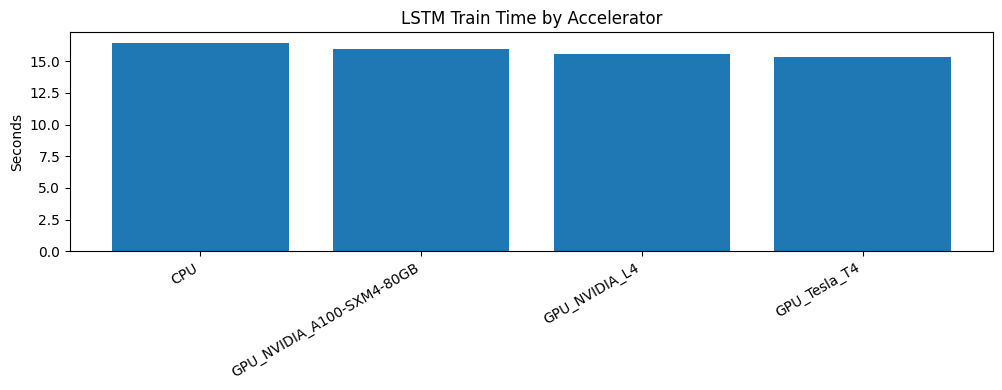

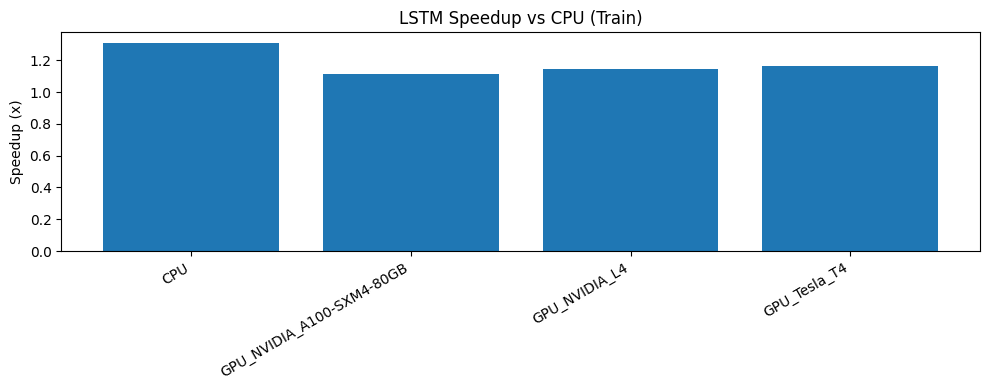

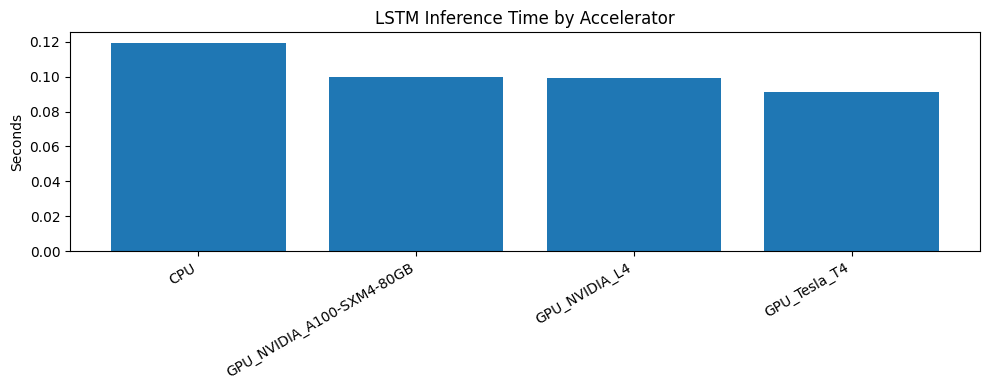

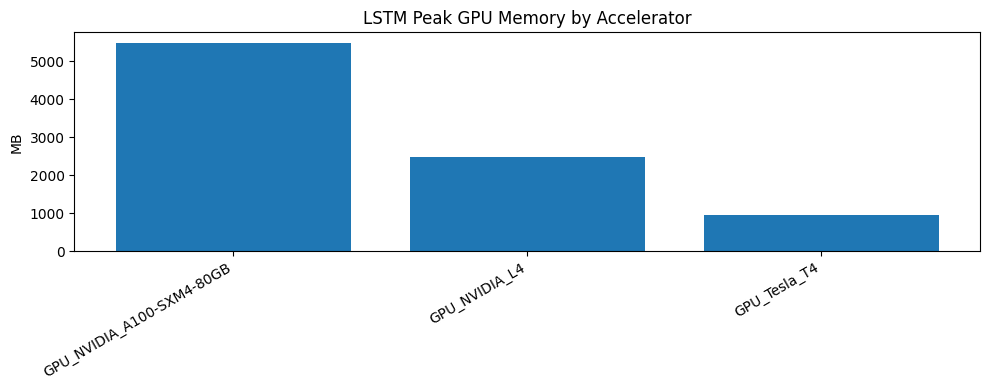

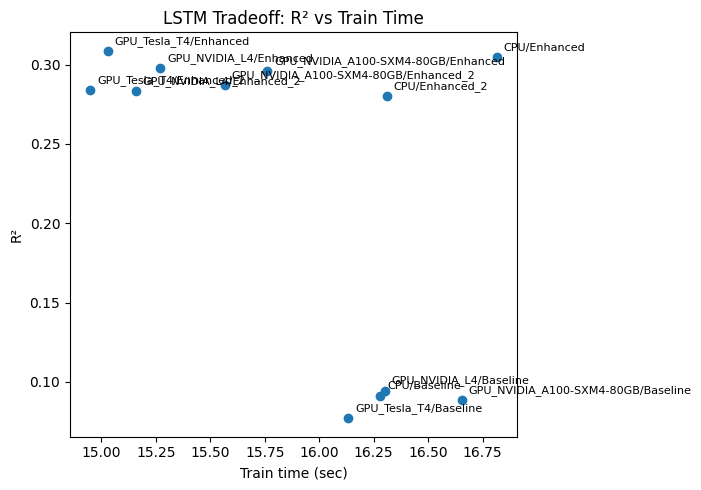

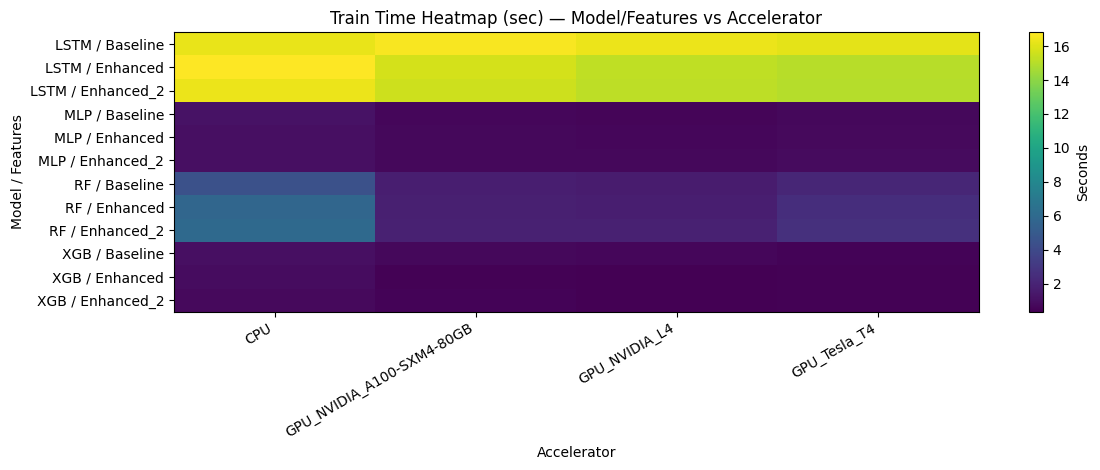

Saved:
- VIZ_best_by_time.csv
- VIZ_best_by_r2.csv
- VIZ_all_combined_with_speedup.csv


In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BENCH_DIR = "/content/drive/MyDrive/colab_benchmarks"

# ---------- Load all AVG runs ----------
avg_files = sorted(glob.glob(os.path.join(BENCH_DIR, "kfold_avg_*.csv")))
if not avg_files:
    raise RuntimeError("No kfold_avg_*.csv found in BENCH_DIR")

avg = pd.concat([pd.read_csv(f).assign(file=os.path.basename(f)) for f in avg_files], ignore_index=True)

# Keep only needed columns (if they exist)
needed = [
    "accelerator","Model","Features",
    "avg_r2","avg_mae",
    "avg_train_time_sec","avg_infer_time_sec",
    "avg_peak_gpu_memory_mb","avg_peak_memory_mb","avg_peak_cpu"
]
for c in needed:
    if c not in avg.columns:
        avg[c] = np.nan

# ---------- CPU baseline: median across CPU runs ----------
cpu = avg[avg["accelerator"].astype(str).str.contains("CPU", case=False, na=False)].copy()
if cpu.empty:
    raise RuntimeError("No CPU runs found. Need at least one CPU avg file.")

cpu_base = cpu.groupby(["Model","Features"], as_index=False).agg(
    cpu_train_time=("avg_train_time_sec","median"),
    cpu_infer_time=("avg_infer_time_sec","median"),
)

m = avg.merge(cpu_base, on=["Model","Features"], how="left")
m["speedup_train_vs_cpu"] = m["cpu_train_time"] / m["avg_train_time_sec"]
m["speedup_infer_vs_cpu"] = m["cpu_infer_time"] / m["avg_infer_time_sec"]

# ---------- Tables ----------
best_by_time = (m.sort_values(["Model","Features","avg_train_time_sec"])
                  .groupby(["Model","Features"], as_index=False)
                  .first()[["Model","Features","accelerator","avg_train_time_sec","speedup_train_vs_cpu","avg_r2","avg_mae","avg_peak_gpu_memory_mb"]])

best_by_r2 = (m.sort_values(["Model","Features","avg_r2"], ascending=[True,True,False])
                .groupby(["Model","Features"], as_index=False)
                .first()[["Model","Features","accelerator","avg_r2","avg_mae","avg_train_time_sec","speedup_train_vs_cpu","avg_peak_gpu_memory_mb"]])

display(best_by_time.sort_values(["Model","Features"]))
display(best_by_r2.sort_values(["Model","Features"]))

# Save tables
best_by_time.to_csv(os.path.join(BENCH_DIR, "VIZ_best_by_time.csv"), index=False)
best_by_r2.to_csv(os.path.join(BENCH_DIR, "VIZ_best_by_r2.csv"), index=False)

# ---------- Helper: plot bar grouped by accelerator ----------
def plot_bar_for_metric(df, metric_col, title, ylabel, model=None, features=None):
    sub = df.copy()
    if model is not None:
        sub = sub[sub["Model"] == model]
    if features is not None:
        sub = sub[sub["Features"] == features]

    # Aggregate in case you have multiple runs per accelerator (mean)
    g = sub.groupby(["accelerator"], as_index=False)[metric_col].mean().dropna()
    if g.empty:
        print(f"Nothing to plot for {title} (missing {metric_col} or no data).")
        return

    # Stable ordering: CPU first, then others
    accs = g["accelerator"].tolist()
    cpu_like = [a for a in accs if "CPU" in a.upper()]
    others = [a for a in accs if a not in cpu_like]
    order = cpu_like + sorted(others)

    g["accelerator"] = pd.Categorical(g["accelerator"], categories=order, ordered=True)
    g = g.sort_values("accelerator")

    plt.figure(figsize=(10, 4))
    plt.bar(g["accelerator"].astype(str), g[metric_col].values)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# ---------- 1) LSTM-focused charts (most meaningful across GPU/TPU) ----------
# If you want a specific feature set, set FEATURES_CHOICE = "Enhanced_2" etc.
FEATURES_CHOICE = None  # e.g. "Enhanced_2"

lstm = m[m["Model"] == "LSTM"].copy()
if FEATURES_CHOICE:
    lstm = lstm[lstm["Features"] == FEATURES_CHOICE]

plot_bar_for_metric(
    lstm, "avg_train_time_sec",
    title=f"LSTM Train Time by Accelerator" + (f" ({FEATURES_CHOICE})" if FEATURES_CHOICE else ""),
    ylabel="Seconds"
)

plot_bar_for_metric(
    lstm, "speedup_train_vs_cpu",
    title=f"LSTM Speedup vs CPU (Train)" + (f" ({FEATURES_CHOICE})" if FEATURES_CHOICE else ""),
    ylabel="Speedup (x)"
)

plot_bar_for_metric(
    lstm, "avg_infer_time_sec",
    title=f"LSTM Inference Time by Accelerator" + (f" ({FEATURES_CHOICE})" if FEATURES_CHOICE else ""),
    ylabel="Seconds"
)

plot_bar_for_metric(
    lstm, "avg_peak_gpu_memory_mb",
    title=f"LSTM Peak GPU Memory by Accelerator" + (f" ({FEATURES_CHOICE})" if FEATURES_CHOICE else ""),
    ylabel="MB"
)

# ---------- 2) Tradeoff scatter: R² vs train time ----------
# One point per accelerator (averaged over multiple runs)
trade = lstm.groupby(["accelerator","Features"], as_index=False).agg(
    train_time=("avg_train_time_sec","mean"),
    r2=("avg_r2","mean"),
    vram=("avg_peak_gpu_memory_mb","mean")
).dropna(subset=["train_time","r2"])

if not trade.empty:
    plt.figure(figsize=(7,5))
    plt.scatter(trade["train_time"], trade["r2"])
    for _, r in trade.iterrows():
        label = f'{r["accelerator"]}'
        if not FEATURES_CHOICE:
            label += f'/{r["Features"]}'
        plt.annotate(label, (r["train_time"], r["r2"]), fontsize=8, xytext=(5,5), textcoords="offset points")
    plt.title("LSTM Tradeoff: R² vs Train Time")
    plt.xlabel("Train time (sec)")
    plt.ylabel("R²")
    plt.tight_layout()
    plt.show()

# ---------- 3) Heatmap: train time by accelerator for each (Model, Features) ----------
heat_df = m.groupby(["Model","Features","accelerator"], as_index=False)["avg_train_time_sec"].mean()
pivot = heat_df.pivot_table(index=["Model","Features"], columns="accelerator", values="avg_train_time_sec", aggfunc="mean")

if not pivot.empty:
    # Sort accelerators: CPU first, then others
    cols = list(pivot.columns)
    cpu_like = [c for c in cols if "CPU" in str(c).upper()]
    others = [c for c in cols if c not in cpu_like]
    pivot = pivot[cpu_like + sorted(others)]

    # Convert to array
    data = pivot.values.astype(float)

    plt.figure(figsize=(12, max(4, 0.4 * len(pivot))))
    im = plt.imshow(data, aspect="auto")
    plt.title("Train Time Heatmap (sec) — Model/Features vs Accelerator")
    plt.xlabel("Accelerator")
    plt.ylabel("Model / Features")

    plt.xticks(ticks=np.arange(len(pivot.columns)), labels=[str(c) for c in pivot.columns], rotation=30, ha="right")
    ylabels = [f"{idx[0]} / {idx[1]}" for idx in pivot.index]
    plt.yticks(ticks=np.arange(len(pivot.index)), labels=ylabels)

    cbar = plt.colorbar(im)
    cbar.set_label("Seconds")

    plt.tight_layout()
    plt.show()

# ---------- Save a combined dataset used for plots ----------
m.to_csv(os.path.join(BENCH_DIR, "VIZ_all_combined_with_speedup.csv"), index=False)
print("Saved:")
print("- VIZ_best_by_time.csv")
print("- VIZ_best_by_r2.csv")
print("- VIZ_all_combined_with_speedup.csv")


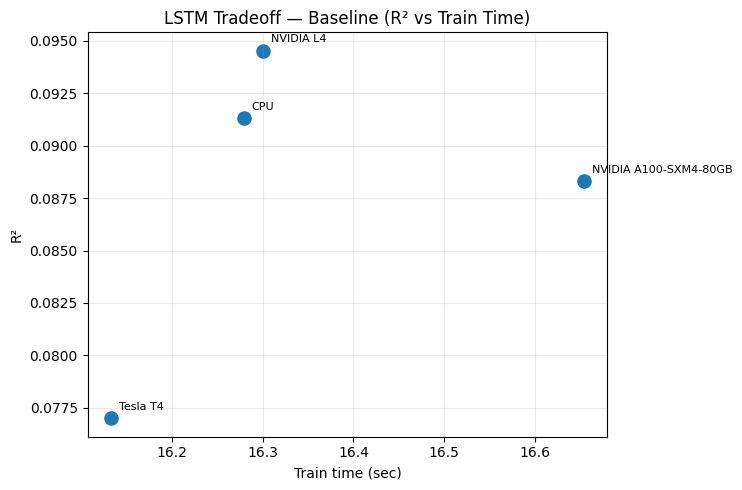

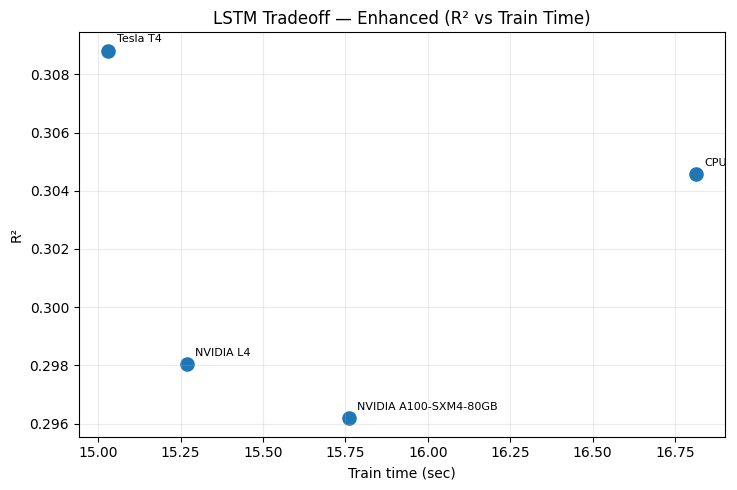

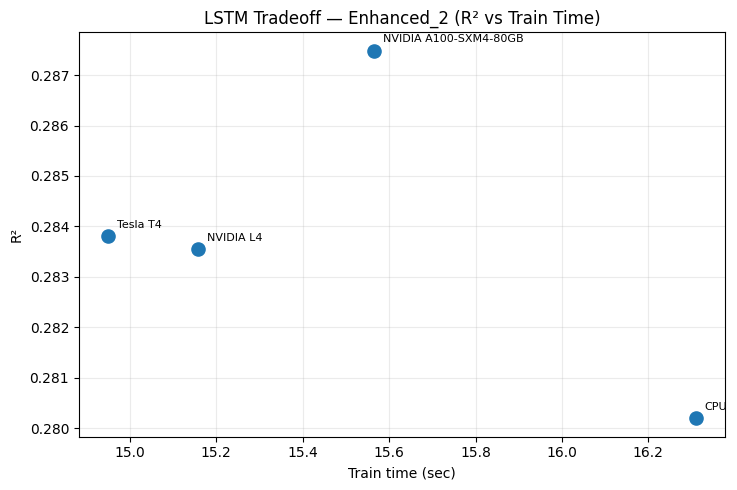

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BENCH_DIR = "/content/drive/MyDrive/colab_benchmarks"
df = pd.read_csv(os.path.join(BENCH_DIR, "VIZ_all_combined_with_speedup.csv"))

# LSTM only + keep only rows that have time and r2
d = df[(df["Model"] == "LSTM")].copy()
d = d.dropna(subset=["avg_train_time_sec", "avg_r2"])

# If you have multiple runs per accelerator, average them:
d = d.groupby(["accelerator", "Features"], as_index=False).agg(
    train_time=("avg_train_time_sec","mean"),
    r2=("avg_r2","mean"),
    mae=("avg_mae","mean"),
    vram=("avg_peak_gpu_memory_mb","mean"),
    speedup=("speedup_train_vs_cpu","mean"),
)

features_list = sorted(d["Features"].unique())

for fs in features_list:
    sub = d[d["Features"] == fs].copy()
    sub = sub.sort_values("train_time")

    plt.figure(figsize=(7.5,5))
    plt.scatter(sub["train_time"], sub["r2"], s=90)

    # Label only accelerators (shorter labels)
    for _, r in sub.iterrows():
        label = str(r["accelerator"]).replace("GPU_", "").replace("_", " ")
        plt.annotate(label, (r["train_time"], r["r2"]), fontsize=8,
                     xytext=(6,6), textcoords="offset points")

    plt.title(f"LSTM Tradeoff — {fs} (R² vs Train Time)")
    plt.xlabel("Train time (sec)")
    plt.ylabel("R²")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


In [ ]:
import os
import pandas as pd

BENCH_DIR = "/content/drive/MyDrive/colab_benchmarks"
df = pd.read_csv(os.path.join(BENCH_DIR, "VIZ_all_combined_with_speedup.csv"))

# LSTM only
d = df[df["Model"]=="LSTM"].copy()
d = d.dropna(subset=["avg_train_time_sec","avg_r2"])

# Average multiple runs per accelerator if any
d = d.groupby(["accelerator","Features"], as_index=False).agg(
    r2=("avg_r2","mean"),
    mae=("avg_mae","mean"),
    train=("avg_train_time_sec","mean"),
    infer=("avg_infer_time_sec","mean"),
    vram=("avg_peak_gpu_memory_mb","mean"),
    speedup=("speedup_train_vs_cpu","mean"),
)

# Make it pretty
d["accelerator"] = d["accelerator"].astype(str).str.replace("GPU_","", regex=False).str.replace("_"," ", regex=False)
d = d.sort_values(["Features","train"])

# Select columns + format
out = d[["Features","accelerator","r2","mae","train","infer","speedup","vram"]].copy()
out = out.rename(columns={
    "accelerator":"Accelerator",
    "r2":"R2",
    "mae":"MAE",
    "train":"Train(s)",
    "infer":"Infer(s)",
    "speedup":"Speedup",
    "vram":"VRAM(MB)"
})

latex = out.to_latex(index=False, escape=True, float_format="%.3f",
                     caption="LSTM performance across accelerators (averaged over runs).",
                     label="tab:lstm_accel",
                     column_format="llrrrrrr",
                     bold_rows=False)

tex_path = os.path.join(BENCH_DIR, "overleaf_lstm_table.tex")
with open(tex_path, "w") as f:
    f.write(latex)

print("Saved LaTeX table to:", tex_path)
print(latex[:800], "...\n")


Saved LaTeX table to: /content/drive/MyDrive/colab_benchmarks/overleaf_lstm_table.tex
\begin{table}
\caption{LSTM performance across accelerators (averaged over runs).}
\label{tab:lstm_accel}
\begin{tabular}{llrrrrrr}
\toprule
Features & Accelerator & R2 & MAE & Train(s) & Infer(s) & Speedup & VRAM(MB) \\
\midrule
Baseline & Tesla T4 & 0.077 & 51.581 & 16.133 & 0.093 & 1.106 & 954.800 \\
Baseline & CPU & 0.091 & 50.776 & 16.279 & 0.109 & 1.320 & NaN \\
Baseline & NVIDIA L4 & 0.095 & 50.569 & 16.300 & 0.100 & 1.095 & 2418.200 \\
Baseline & NVIDIA A100-SXM4-80GB & 0.088 & 50.751 & 16.654 & 0.102 & 1.071 & 5376.000 \\
Enhanced & Tesla T4 & 0.309 & 43.056 & 15.031 & 0.091 & 1.191 & 954.800 \\
Enhanced & NVIDIA L4 & 0.298 & 43.583 & 15.270 & 0.098 & 1.173 & 2496.000 \\
Enhanced & NVIDIA A100-SXM4-80GB & 0.296 & 43.674 & 15.761 & 0.099 & 1.136 & 5547.000 \\
Enhanced & CPU & 0.305 ...



In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio

BENCH_DIR = "/content/drive/MyDrive/colab_benchmarks"
CSV_PATH  = os.path.join(BENCH_DIR, "VIZ_all_combined_with_speedup.csv")
OUT_DIR   = os.path.join(BENCH_DIR, "mixed_plots")
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)

# --- Aggregate (in case you have multiple runs per accelerator) ---
# Use avg_train_time_sec vs avg_r2 as the main tradeoff plot.
d = df.dropna(subset=["avg_train_time_sec", "avg_r2"]).copy()

# Average duplicates across files/runs
d = d.groupby(["Model", "Features", "accelerator"], as_index=False).agg(
    train_time=("avg_train_time_sec", "mean"),
    r2=("avg_r2", "mean"),
    mae=("avg_mae", "mean"),
    infer_time=("avg_infer_time_sec", "mean"),
    vram=("avg_peak_gpu_memory_mb", "mean"),
)

def short_accel(a):
    a = str(a).replace("GPU_", "").replace("_", " ")
    a = a.replace("NVIDIA ", "").replace("Tesla ", "")
    return a

# Marker per accelerator (no colors fixed; colors come from matplotlib default cycle per model)
marker_map = {}
markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
accels = sorted(d["accelerator"].unique(), key=lambda x: ("CPU" not in str(x).upper(), str(x)))
for i, a in enumerate(accels):
    marker_map[a] = markers[i % len(markers)]

models = ["RF", "XGB", "MLP", "LSTM"]
features_list = sorted(d["Features"].unique())

def save_fig(fig, base_path, dpi=220):
    png_path = base_path + ".png"
    gif_path = base_path + ".gif"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    img = imageio.imread(png_path)
    imageio.mimsave(gif_path, [img], duration=1.2)
    return png_path, gif_path

for fs in features_list:
    sub = d[d["Features"] == fs].copy()
    if sub.empty:
        continue

    fig, ax = plt.subplots(figsize=(9.5, 5.6))

    # Plot by model (color), and within that by accelerator (marker)
    for model in models:
        msub = sub[sub["Model"] == model]
        if msub.empty:
            continue

        # We will plot each accelerator as separate scatter so markers differ
        for acc in accels:
            asub = msub[msub["accelerator"] == acc]
            if asub.empty:
                continue
            ax.scatter(
                asub["train_time"], asub["r2"],
                s=80,
                marker=marker_map[acc],
                label=model  # temporary; we’ll build legends properly below
            )

    # Axis padding so nothing is clipped
    xmin, xmax = sub["train_time"].min(), sub["train_time"].max()
    xpad = max(0.02, (xmax - xmin) * 0.15)
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ymin, ymax = sub["r2"].min(), sub["r2"].max()
    ypad = max(0.002, (ymax - ymin) * 0.20)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_title(f"All Models Tradeoff — {fs} (R² vs Train Time)")
    ax.set_xlabel("Train time (sec)")
    ax.set_ylabel("R²")
    ax.grid(True, alpha=0.25)

    # --- Build 2 legends: one for model colors, one for accelerator markers ---
    # Legend 1: models (colors) -> create dummy handles using one marker style
    model_handles = []
    for model in models:
        # dummy point; color comes from default cycle in order of plotting
        h = ax.scatter([], [], s=80, marker="o", label=model)
        model_handles.append(h)
    leg1 = ax.legend(handles=model_handles, title="Model", loc="lower right", frameon=True)

    # Legend 2: accelerators (markers)
    accel_handles = []
    for acc in accels:
        h = ax.scatter([], [], s=80, marker=marker_map[acc], label=short_accel(acc))
        accel_handles.append(h)
    leg2 = ax.legend(handles=accel_handles, title="Accelerator", loc="lower left", frameon=True)

    ax.add_artist(leg1)  # keep both legends

    fig.tight_layout()

    base = os.path.join(OUT_DIR, f"tradeoff_all_models_{fs.replace(' ','_')}")
    png_path, gif_path = save_fig(fig, base)
    plt.close(fig)

    print("Saved:", png_path)
    print("Saved:", gif_path)

print("Done. Output folder:", OUT_DIR)


Saved: /content/drive/MyDrive/colab_benchmarks/mixed_plots/tradeoff_all_models_Baseline.png
Saved: /content/drive/MyDrive/colab_benchmarks/mixed_plots/tradeoff_all_models_Baseline.gif
Saved: /content/drive/MyDrive/colab_benchmarks/mixed_plots/tradeoff_all_models_Enhanced.png
Saved: /content/drive/MyDrive/colab_benchmarks/mixed_plots/tradeoff_all_models_Enhanced.gif
Saved: /content/drive/MyDrive/colab_benchmarks/mixed_plots/tradeoff_all_models_Enhanced_2.png
Saved: /content/drive/MyDrive/colab_benchmarks/mixed_plots/tradeoff_all_models_Enhanced_2.gif
Done. Output folder: /content/drive/MyDrive/colab_benchmarks/mixed_plots


In [ ]:
import os
import numpy as np
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

BENCH_DIR = "/content/drive/MyDrive/colab_benchmarks"
CSV_PATH  = os.path.join(BENCH_DIR, "VIZ_all_combined_with_speedup.csv")

df = pd.read_csv(CSV_PATH)

# Keep only what we need
# (If some columns are missing in your file, this will still work.)
cols_needed = [
    "Model", "Features", "accelerator",
    "avg_train_time_sec", "avg_infer_time_sec",
    "speedup_train_vs_cpu", "avg_peak_gpu_memory_mb"
]
for c in cols_needed:
    if c not in df.columns:
        df[c] = np.nan

d = df.dropna(subset=["avg_train_time_sec", "avg_infer_time_sec"]).copy()

# Average across multiple runs/files (if you have duplicates)
d = d.groupby(["Model", "Features", "accelerator"], as_index=False).agg(
    train_s=("avg_train_time_sec", "mean"),
    infer_s=("avg_infer_time_sec", "mean"),
    speedup=("speedup_train_vs_cpu", "mean"),
    vram_mb=("avg_peak_gpu_memory_mb", "mean"),
)

# Clean names a bit for presentation
def short_accel(a):
    a = str(a).replace("GPU_", "").replace("_", " ")
    a = a.replace("NVIDIA ", "").replace("Tesla ", "")
    return a

d["Accelerator"] = d["accelerator"].apply(short_accel)
out = d[["Model","Features","Accelerator","train_s","infer_s","speedup","vram_mb"]].copy()

# Replace NaN VRAM (CPU) with '--'
out["vram_mb"] = out["vram_mb"].apply(lambda x: "--" if pd.isna(x) else x)

# Sort nicely: Model, Features, then CPU first
def accel_sort_key(a):
    a = str(a).upper()
    return (0 if "CPU" in a else 1, a)

out = out.sort_values(by=["Model","Features","Accelerator"], key=lambda s: s.map(accel_sort_key))

# Format numeric columns
def fmt(x, nd=3):
    if x == "--":
        return x
    return f"{float(x):.{nd}f}"

out_fmt = out.copy()
out_fmt["train_s"] = out_fmt["train_s"].map(lambda x: fmt(x, 3))
out_fmt["infer_s"] = out_fmt["infer_s"].map(lambda x: fmt(x, 3))
out_fmt["speedup"] = out_fmt["speedup"].map(lambda x: fmt(x, 3))
out_fmt["vram_mb"] = out_fmt["vram_mb"].map(lambda x: x if x=="--" else fmt(x, 1))

out_fmt = out_fmt.rename(columns={
    "train_s":"Train(s)",
    "infer_s":"Infer(s)",
    "speedup":"Speedup",
    "vram_mb":"VRAM(MB)"
})

latex = out_fmt.to_latex(
    index=False,
    escape=True,
    column_format="lllrrrr",
    caption="Computational performance across accelerators (averaged over runs).",
    label="tab:compute_all_models",
    longtable=False
)

tex_path = os.path.join(BENCH_DIR, "overleaf_all_models_compute_table.tex")
with open(tex_path, "w") as f:
    f.write(latex)

print("Saved:", tex_path)
print(latex[:1200], "...\n")


Mounted at /content/drive
Saved: /content/drive/MyDrive/colab_benchmarks/overleaf_all_models_compute_table.tex
\begin{table}
\caption{Computational performance across accelerators (averaged over runs).}
\label{tab:compute_all_models}
\begin{tabular}{lllrrrr}
\toprule
Model & Features & Accelerator & Train(s) & Infer(s) & Speedup & VRAM(MB) \\
\midrule
LSTM & Baseline & CPU & 16.279 & 0.109 & 1.320 & -- \\
LSTM & Baseline & A100-SXM4-80GB & 16.654 & 0.102 & 1.071 & 5376.0 \\
LSTM & Baseline & L4 & 16.300 & 0.100 & 1.095 & 2418.2 \\
LSTM & Baseline & T4 & 16.133 & 0.093 & 1.106 & 954.8 \\
LSTM & Enhanced & CPU & 16.814 & 0.123 & 1.314 & -- \\
LSTM & Enhanced & A100-SXM4-80GB & 15.761 & 0.099 & 1.136 & 5547.0 \\
LSTM & Enhanced & L4 & 15.270 & 0.098 & 1.173 & 2496.0 \\
LSTM & Enhanced & T4 & 15.031 & 0.091 & 1.191 & 954.8 \\
LSTM & Enhanced\_2 & CPU & 16.311 & 0.126 & 1.295 & -- \\
LSTM & Enhanced\_2 & A100-SXM4-80GB & 15.566 & 0.098 & 1.139 & 5547.0 \\
LSTM & Enhanced\_2 & L4 & 15.158 & 